In [1]:
import os
current_path  = os.getcwd()
if current_path == "c:\\Users\\bryan\\OneDrive - Université Libre de Bruxelles\\Master 2 Ingénieur Civile\\Master Thesis\\Master-Thesis-Bryan-ML\\MSc_Bryan_Rincon":
    os.chdir("..")
    print(os.getcwd())
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fasteda import fast_eda
from openTSNE import TSNE
import random
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import math
from itertools import groupby
import ruptures as rpt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
import pickle



c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML
c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML


# Datasets 

In [2]:
# File path to CSV file
VRBA_eruptions_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_discrete_2019-01-01_2025-01-01_AcousticVRBA.csv"
Rincon_de_la_Vieja_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_continuous_2019-01-01_2025-01-01.csv"
Rincon_path = "MSc_Bryan_Rincon/Datasets/Rincon 2014-2024.xlsx"
Lahares_path = "MSc_Bryan_Rincon/Datasets/Lahares_updated.csv"
RainChirps_path = "MSc_Bryan_Rincon/Datasets/RainChirps4km.csv"
Rain2019_2024_path = "MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv"
Rincon_filtered_path = "MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv"
# rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_0.8_4Hz_VORI.csv"
# dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI.csv"
rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv"
dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv"


# # Load the CSV file into a DataFrame
VRBA_eruptions_df = pd.read_csv(VRBA_eruptions_path)
Rincon_de_la_Vieja_df = pd.read_csv(Rincon_de_la_Vieja_path)
Rincon_original_df = pd.read_excel(Rincon_path)
Rincon_df = pd.read_csv(Rincon_filtered_path)
Lahares_df = pd.read_csv(Lahares_path, sep=';')
#RainChirps_df = pd.read_csv(RainChirps_path)
Rain2019_2024_df = pd.read_csv(Rain2019_2024_path)
rsam_VORI_df = pd.read_csv(rsam_VORI_path)
dsar_VORI_df = pd.read_csv(dsar_VORI_path)


## Delete path variables
del current_path, VRBA_eruptions_path, Rincon_de_la_Vieja_path, Rincon_path, Lahares_path, RainChirps_path, Rain2019_2024_path, Rincon_filtered_path, rsam_VORI_path, dsar_VORI_path 


# Data exploration

## Dataset Overview

We start by convert the different timestamps to a common format and exploring the dataset to understand its structure and content. Since we are focusing on one specific channel and station, we filter the dataset accordingly.

In [3]:
## Overview of the datasets

# #Convert relevant columns to datetime
VRBA_eruptions_df[['t1', 't2']] = VRBA_eruptions_df[['t1', 't2']].apply(pd.to_datetime, format='mixed')
Rincon_de_la_Vieja_df['time'] = pd.to_datetime(Rincon_de_la_Vieja_df['time'], format='mixed')
Rincon_original_df['Fecha'] = pd.to_datetime(Rincon_original_df['Fecha'], format='mixed')
Rincon_df['time'] = pd.to_datetime(Rincon_df['time'], format='mixed')
# RainChirps_df['Unnamed: 0'] = pd.to_datetime(RainChirps_df['Unnamed: 0'], format='mixed')
Rain2019_2024_df['Time'] = pd.to_datetime(Rain2019_2024_df['Time'], format='mixed')
Lahares_df[['Eruption time', 'Lahar time']] = Lahares_df[['Eruption time', 'Lahar time']].apply(pd.to_datetime, format='mixed')
rsam_VORI_df['timestamp'] = pd.to_datetime(rsam_VORI_df['timestamp'], format='mixed')
dsar_VORI_df['timestamp'] = pd.to_datetime(dsar_VORI_df['timestamp'], format='mixed')

# # Set the right index
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.set_index('time')
Rincon_df = Rincon_df.set_index('time').sort_index()
Rain2019_2024_df = Rain2019_2024_df.set_index('Time')
rsam_VORI_df = rsam_VORI_df.set_index('timestamp')
dsar_VORI_df =  dsar_VORI_df.set_index('timestamp')


# # The basic info and descriptive statistics of the DataFrames are shown below:
print("VRBA Eruptions DataFrame:")
print(VRBA_eruptions_df.info())
print(VRBA_eruptions_df.describe())


print("\nRincon de la Vieja Continuous DataFrame:")
print(Rincon_de_la_Vieja_df.info())
print(Rincon_de_la_Vieja_df.describe())

print("\nRincon DataFrame:")
print(Rincon_df.info())
print(Rincon_df.describe())

print("\nRain 2019-2024 DataFrame:")
print(Rain2019_2024_df.info())
print(Rain2019_2024_df.describe())

print("\nrsam_VORI Dataframe")
print(rsam_VORI_df.info())
print(rsam_VORI_df.describe())

print("\ndsar_VORI Dataframe")
print(dsar_VORI_df.info())
print(dsar_VORI_df.describe())



VRBA Eruptions DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_id       967 non-null    int64         
 1   label          967 non-null    object        
 2   station        967 non-null    object        
 3   sensor_type    967 non-null    object        
 4   t1             967 non-null    datetime64[ns]
 5   t2             967 non-null    datetime64[ns]
 6   amplitude_max  967 non-null    float64       
 7   amplitude_rms  967 non-null    float64       
 8   amplitude_p2p  967 non-null    float64       
 9   energy         967 non-null    float64       
 10  duration       967 non-null    float64       
 11  magnitude      967 non-null    float64       
dtypes: datetime64[ns](2), float64(6), int64(1), object(3)
memory usage: 90.8+ KB
None
            event_id                             t1  \
count     967

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       channel_id          dsar          rsam       trigger  freq_bands_mean  \
count   2501485.0  2.501484e+06  2.501485e+06  2.501482e+06     2.501463e+06   
mean          4.0  8.952695e-01  1.083555e+02  2.524579e-01     3.915977e+00   
std           0.0  7.107066e-01  4.359005e+03  6.272270e-01     7.259706e-01   
min           4.0  6.506897e-03  7.330034e-10  0.000000e+00     1.298668e+00   
25%           4.0  5.365507e-01  2.834283e+01  0.000000e+00     3.429077e+00   
50%           4.0  7.610639e-01  4.177987e+01  0.000000e+00     4.043785e+00   
75%           4.0  1.002964e+00  7.173440e+01  0.000000e+00     4.449928e+00   
max           4.0  2.484838e+02  2.822957e+06  1.200000e+01     7.871830e+00   

         freq_top_k    freq_index  spectral_kurtosis      tonality  
count  2.501472e+06  2.501483e+06       2.501483e+06  2.501479e+06  
mean   2.078415e+00           inf       1.878347e+01  2.039374e+01  
std    1.073341e+00           NaN       1.751674e+01  6.872862e+00  
min

In [4]:
## Drop irrelevant columns
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.drop(columns=['station', 'channel'])
VRBA_eruptions_df = VRBA_eruptions_df.drop(columns=['event_id', 'label', 'sensor_type', 'station'])

## Datasets already filtered 
# dsar_VORI_df = dsar_VORI_df.drop(columns=['Unnamed: 0'])
# rsam_VORI_df = rsam_VORI_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

### Precipitation Data

The precipitations data contains rainfall measurements over few years. We only keep the measurements from 2019 to 2024 for our analysis. A filter is applied on the measurements to try to remove or at least to reduce the outliers

In [5]:
## Keep only the 2019-2024 data from RainChirps and change the column name
# Rain2019_2024_df = RainChirps_df[(RainChirps_df['Unnamed: 0'] > pd.to_datetime('2018-12-31')) & (RainChirps_df['Unnamed: 0']<= pd.to_datetime('2025-01-01')) ]
# Rain2019_2024_df = Rain2019_2024_df.rename(columns={'Unnamed: 0':'Time','(mm) Precipitation (CHIRPS) at -85.3366E,10.8315N, 2013-01-01 to 2025-01-01':'Precipitations'} )
# Rain2019_2024_df.to_csv('MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv', index=False)

In [6]:
Rain2019_2024_df.columns

Index(['Precipitations'], dtype='object')

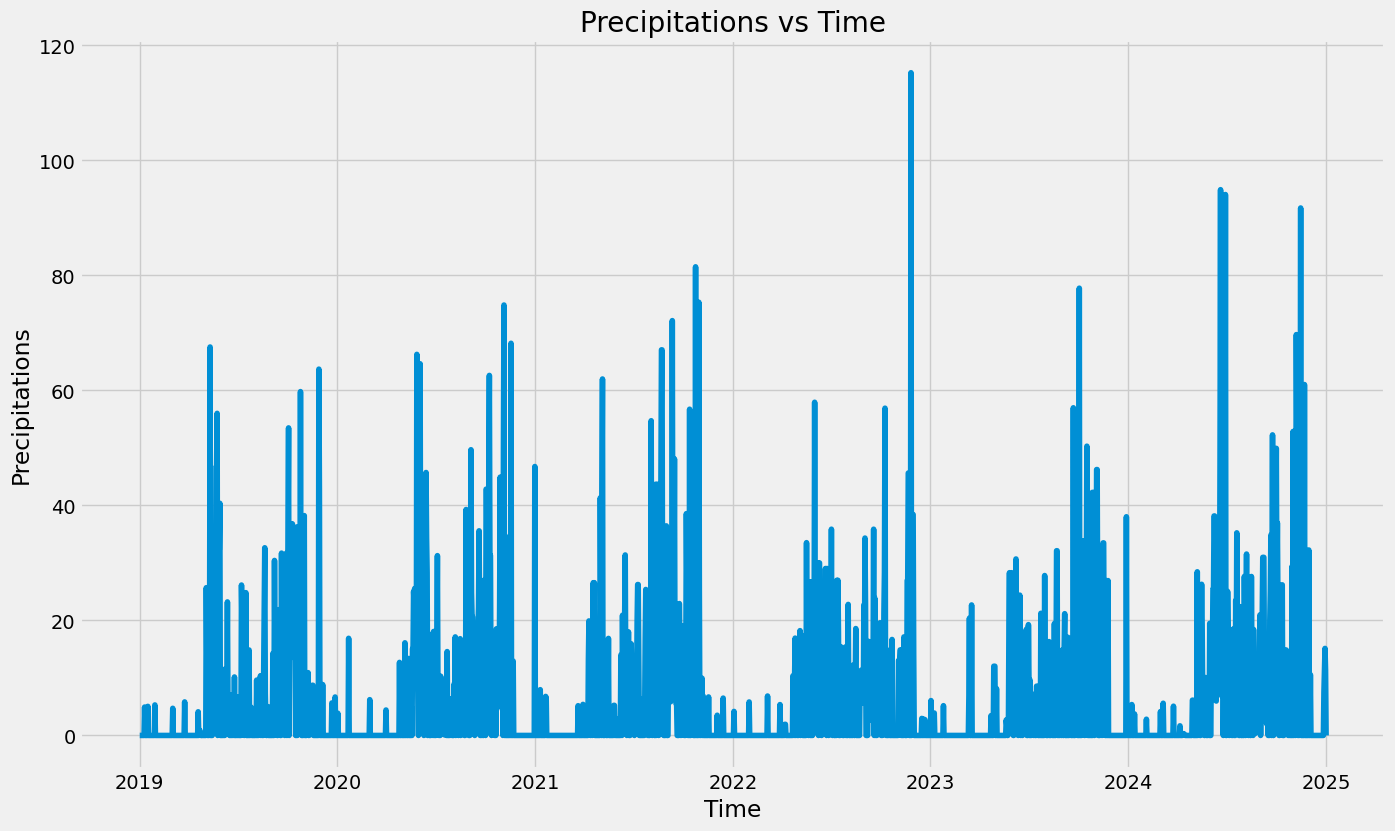

In [11]:
# Plot the precipitations around volcano
plt.figure(figsize=(15,9))
times = Rain2019_2024_df.index
precipitations = Rain2019_2024_df['Precipitations']
plt.plot(times, precipitations)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.show()

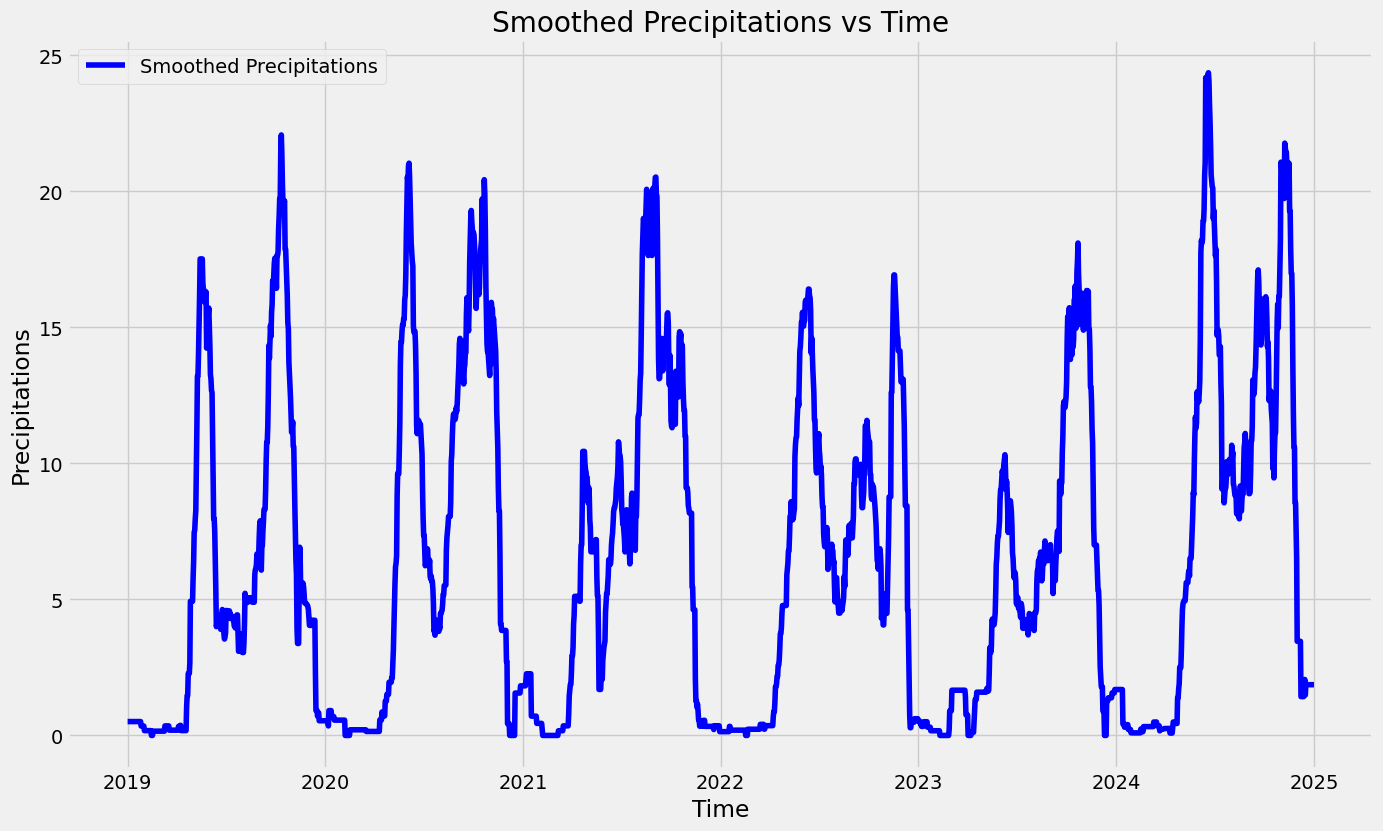

In [12]:
# Plot smoothened precipitations with a moving average

precipitations_series = pd.Series(precipitations.values, index=times)
smoothed_precipitations = precipitations_series.rolling(window=30, center=True).mean()
smoothed_precipitations = smoothed_precipitations.bfill().ffill()
plt.figure(figsize=(15,9))
plt.plot(times, smoothed_precipitations, color='blue', label='Smoothed Precipitations')
plt.title('Smoothed Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.legend()
plt.show()


Average precipitations during the dry season:  22.659412903225807
Average precipitations during the rainy season:  319.4603666666667


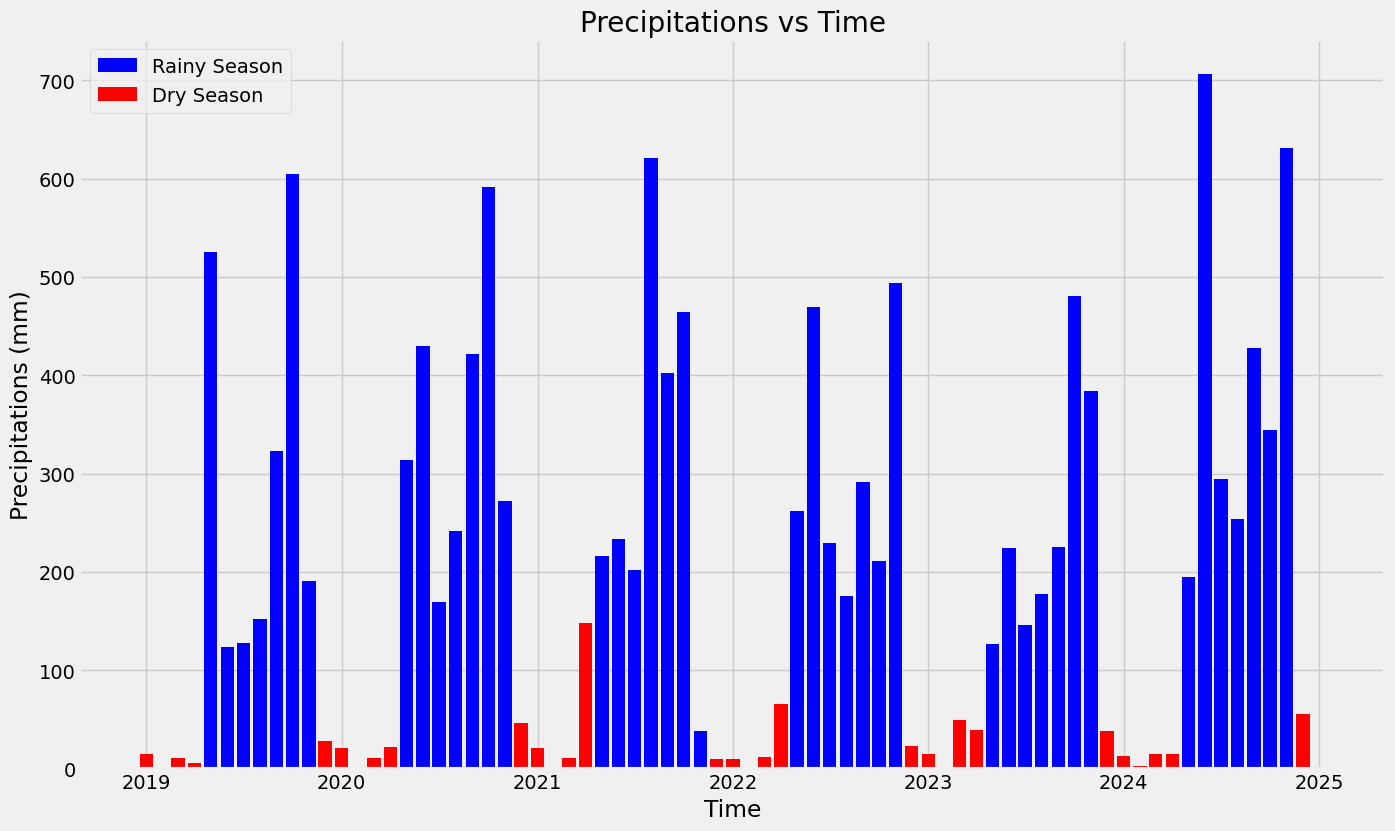

In [10]:
# Plot the precipitations distinguishing Dry and Rainy seasons
precipitations_per_month = Rain2019_2024_df.groupby(Rain2019_2024_df.index.to_period('M'))['Precipitations'].sum()
times = precipitations_per_month.index.to_timestamp()
values = precipitations_per_month.values

dry_season_months = [12, 1, 2, 3, 4]

is_dry = times.month.isin(dry_season_months)

dry_times = times[is_dry]
dry_values = values[is_dry]

rainy_times = times[~is_dry] 
rainy_values = values[~is_dry]


print("Average precipitations during the dry season: ", np.mean(dry_values))
print("Average precipitations during the rainy season: ", np.mean(rainy_values))

plt.figure(figsize=(15, 9))
plt.bar(rainy_times, rainy_values, color='blue', label='Rainy Season', width=25)
plt.bar(dry_times, dry_values, color='red', label='Dry Season', width=25)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations (mm)')
plt.legend()
plt.show()

### Lake Level Data

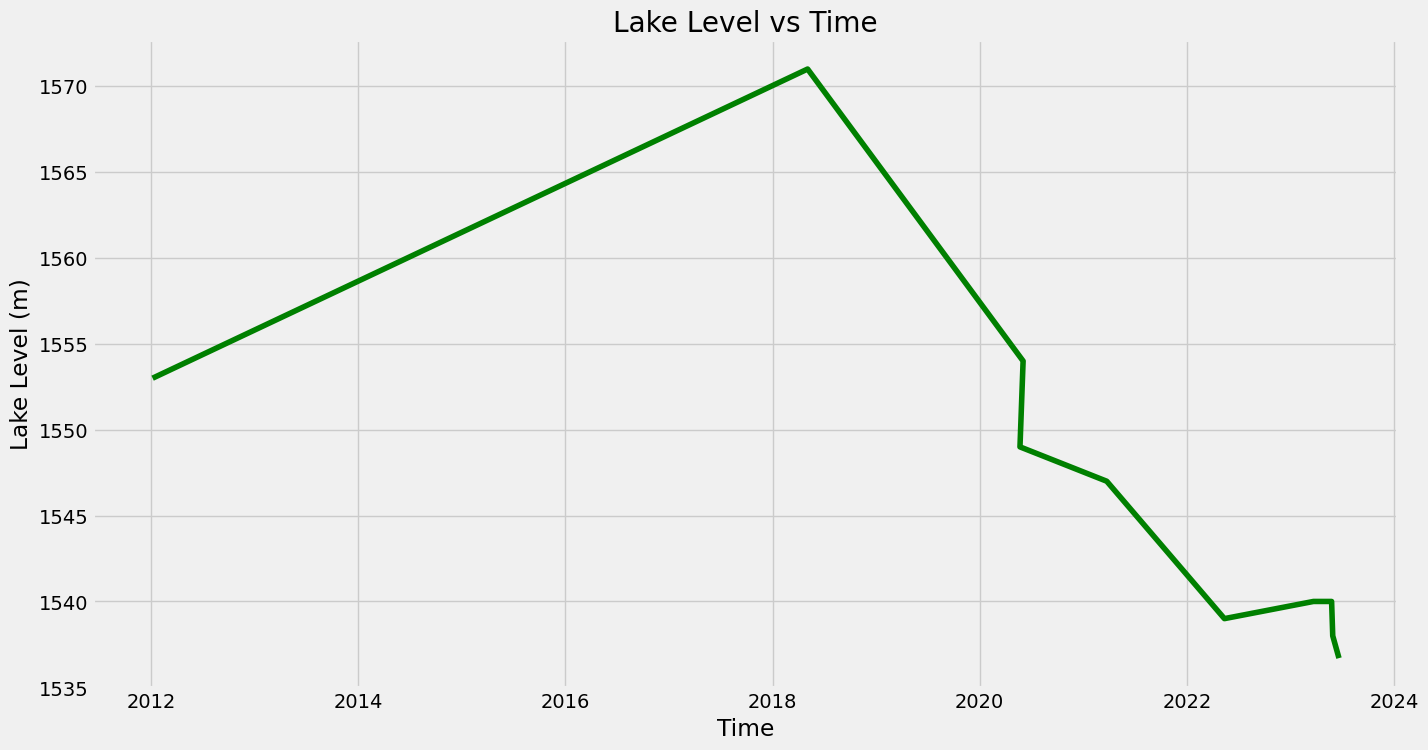

In [13]:
lake_level_df =  pd.read_csv("MSc_Bryan_Rincon/Datasets/Lake_Level.csv")
lake_level_df['Date'] = pd.to_datetime(lake_level_df['Date'], format='mixed')

plt.figure(figsize=(15, 8))
plt.plot(lake_level_df['Date'], lake_level_df['Lake_Level'], color='green')
plt.title('Lake Level vs Time')
plt.xlabel('Time')
plt.ylabel('Lake Level (m)')
plt.show()

### Lahares Data

The different informations about the Lahares are added to the global dataset.
We have the following columns:
- Eruption time: Timestamp of the eruption that triggered the lahar.
- Lahar time: Timestamp of the lahar occurrence.
- Magnitude: Magnitude of the lahar event.

In [13]:
## Add Lahares to the VRBA DataFrame
print("\nLahares DataFrame:")
Lahares_df.info()

# Drop rows + Dates in the same format
Lahares_df = Lahares_df[Lahares_df['Eruption time'].dt.year >= 2019]
vrba_minutes = VRBA_eruptions_df["t1"].dt.floor('min')
lahar_minutes = Lahares_df["Eruption time"]

# Add new column to VRBA_eruptions_df to indicate if lahar occurred
VRBA_eruptions_df["Lahares"] = vrba_minutes.isin(lahar_minutes)

# Add new eruptions where Lahares occurred but not registered
lahares_dates_not_in_VRBA = lahar_minutes[~lahar_minutes.isin(vrba_minutes)]

mag_map = Lahares_df.set_index("Eruption time")["Eruption infrasound magnitude"]

new_rows = pd.DataFrame({
    "t1": lahares_dates_not_in_VRBA,
    "Lahares": True,
    "magnitude": lahares_dates_not_in_VRBA.map(mag_map).str.replace(',', '.').astype(float)
})

VRBA_eruptions_df = pd.concat(
    [VRBA_eruptions_df, new_rows],
    ignore_index=True
)

# Add the time difference before the lahar occurred

VRBA_eruptions_df = pd.merge_asof(
    VRBA_eruptions_df.sort_values('t1'),
    Lahares_df[['Eruption time', 'Time difference (min)']].sort_values('Eruption time'),
    left_on='t1',
    right_on='Eruption time',
    direction='backward',
    tolerance=pd.Timedelta('1Min')
).rename(
    columns={'Time difference (min)': 'Time before Lahar (min)'}
).drop(columns=['Eruption time'])

print(VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True])



Lahares DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Event                          22 non-null     int64         
 1   Eruption time                  22 non-null     datetime64[ns]
 2   Lahar time                     15 non-null     datetime64[ns]
 3   Time difference (min)          15 non-null     float64       
 4   Eruption infrasound magnitude  15 non-null     object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 1012.0+ bytes
                         t1                      t2  amplitude_max  \
0   2019-01-20 07:27:05.050 2019-01-20 07:29:11.950          5.916   
37  2020-01-30 18:13:42.427 2020-01-30 18:14:33.666          5.284   
94  2020-05-25 09:25:52.157 2020-05-25 09:26:35.065          2.599   
208 2021-06-28 11:42:04.132 2021-06-28 11:

In [14]:
lahares_dates_not_in_VRBA

11   2022-06-01 00:33:00
13   2022-01-30 19:08:00
16   2023-11-05 21:17:00
21   2023-02-06 15:05:00
Name: Eruption time, dtype: datetime64[ns]

In [82]:
print(len(VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True]))

15


### Eruptions Data 

In [15]:
VRBA_eruptions_df.describe()

,t1,t2,amplitude_max,amplitude_rms,amplitude_p2p,energy,duration,magnitude,Time before Lahar (min)
count,971,967,967.000000,967.000000,967.000000,9.670000e+02,967.000000,971.000000,15.000000
mean,2022-08-22 19:12:35.052091648,2022-08-22 11:15:50.756762880,0.308552,0.087465,0.648961,6.259377e+05,88.527620,2.824498,20.413333
min,2019-01-20 07:27:05.050000,2019-01-20 07:29:11.950000,0.003000,0.000000,0.005000,1.482800e+01,1.247000,0.784625,8.200000
25%,2022-01-27 21:04:07.139000064,2022-01-26 15:30:29.192000,0.050000,0.015000,0.107500,2.547747e+03,25.259000,2.284488,15.000000
50%,2023-01-06 14:19:38.534000128,2023-01-06 14:20:13.998000128,0.103000,0.032000,0.225000,1.218176e+04,49.121000,2.743239,19.000000
75%,2023-08-25 02:28:58.904000,2023-08-25 02:30:54.944499968,0.247500,0.081500,0.512000,8.081618e+04,117.497500,3.293549,26.500000
max,2024-12-31 03:05:51.038000,2024-12-31 03:07:12.098000,17.436000,3.242000,28.126000,1.280676e+08,1402.151000,5.431984,32.000000
std,NaN,NaN,0.867807,0.195260,1.646017,5.145145e+06,113.641528,0.743776,7.656357


Let's see how the information of the different eruption events are distributed over time.

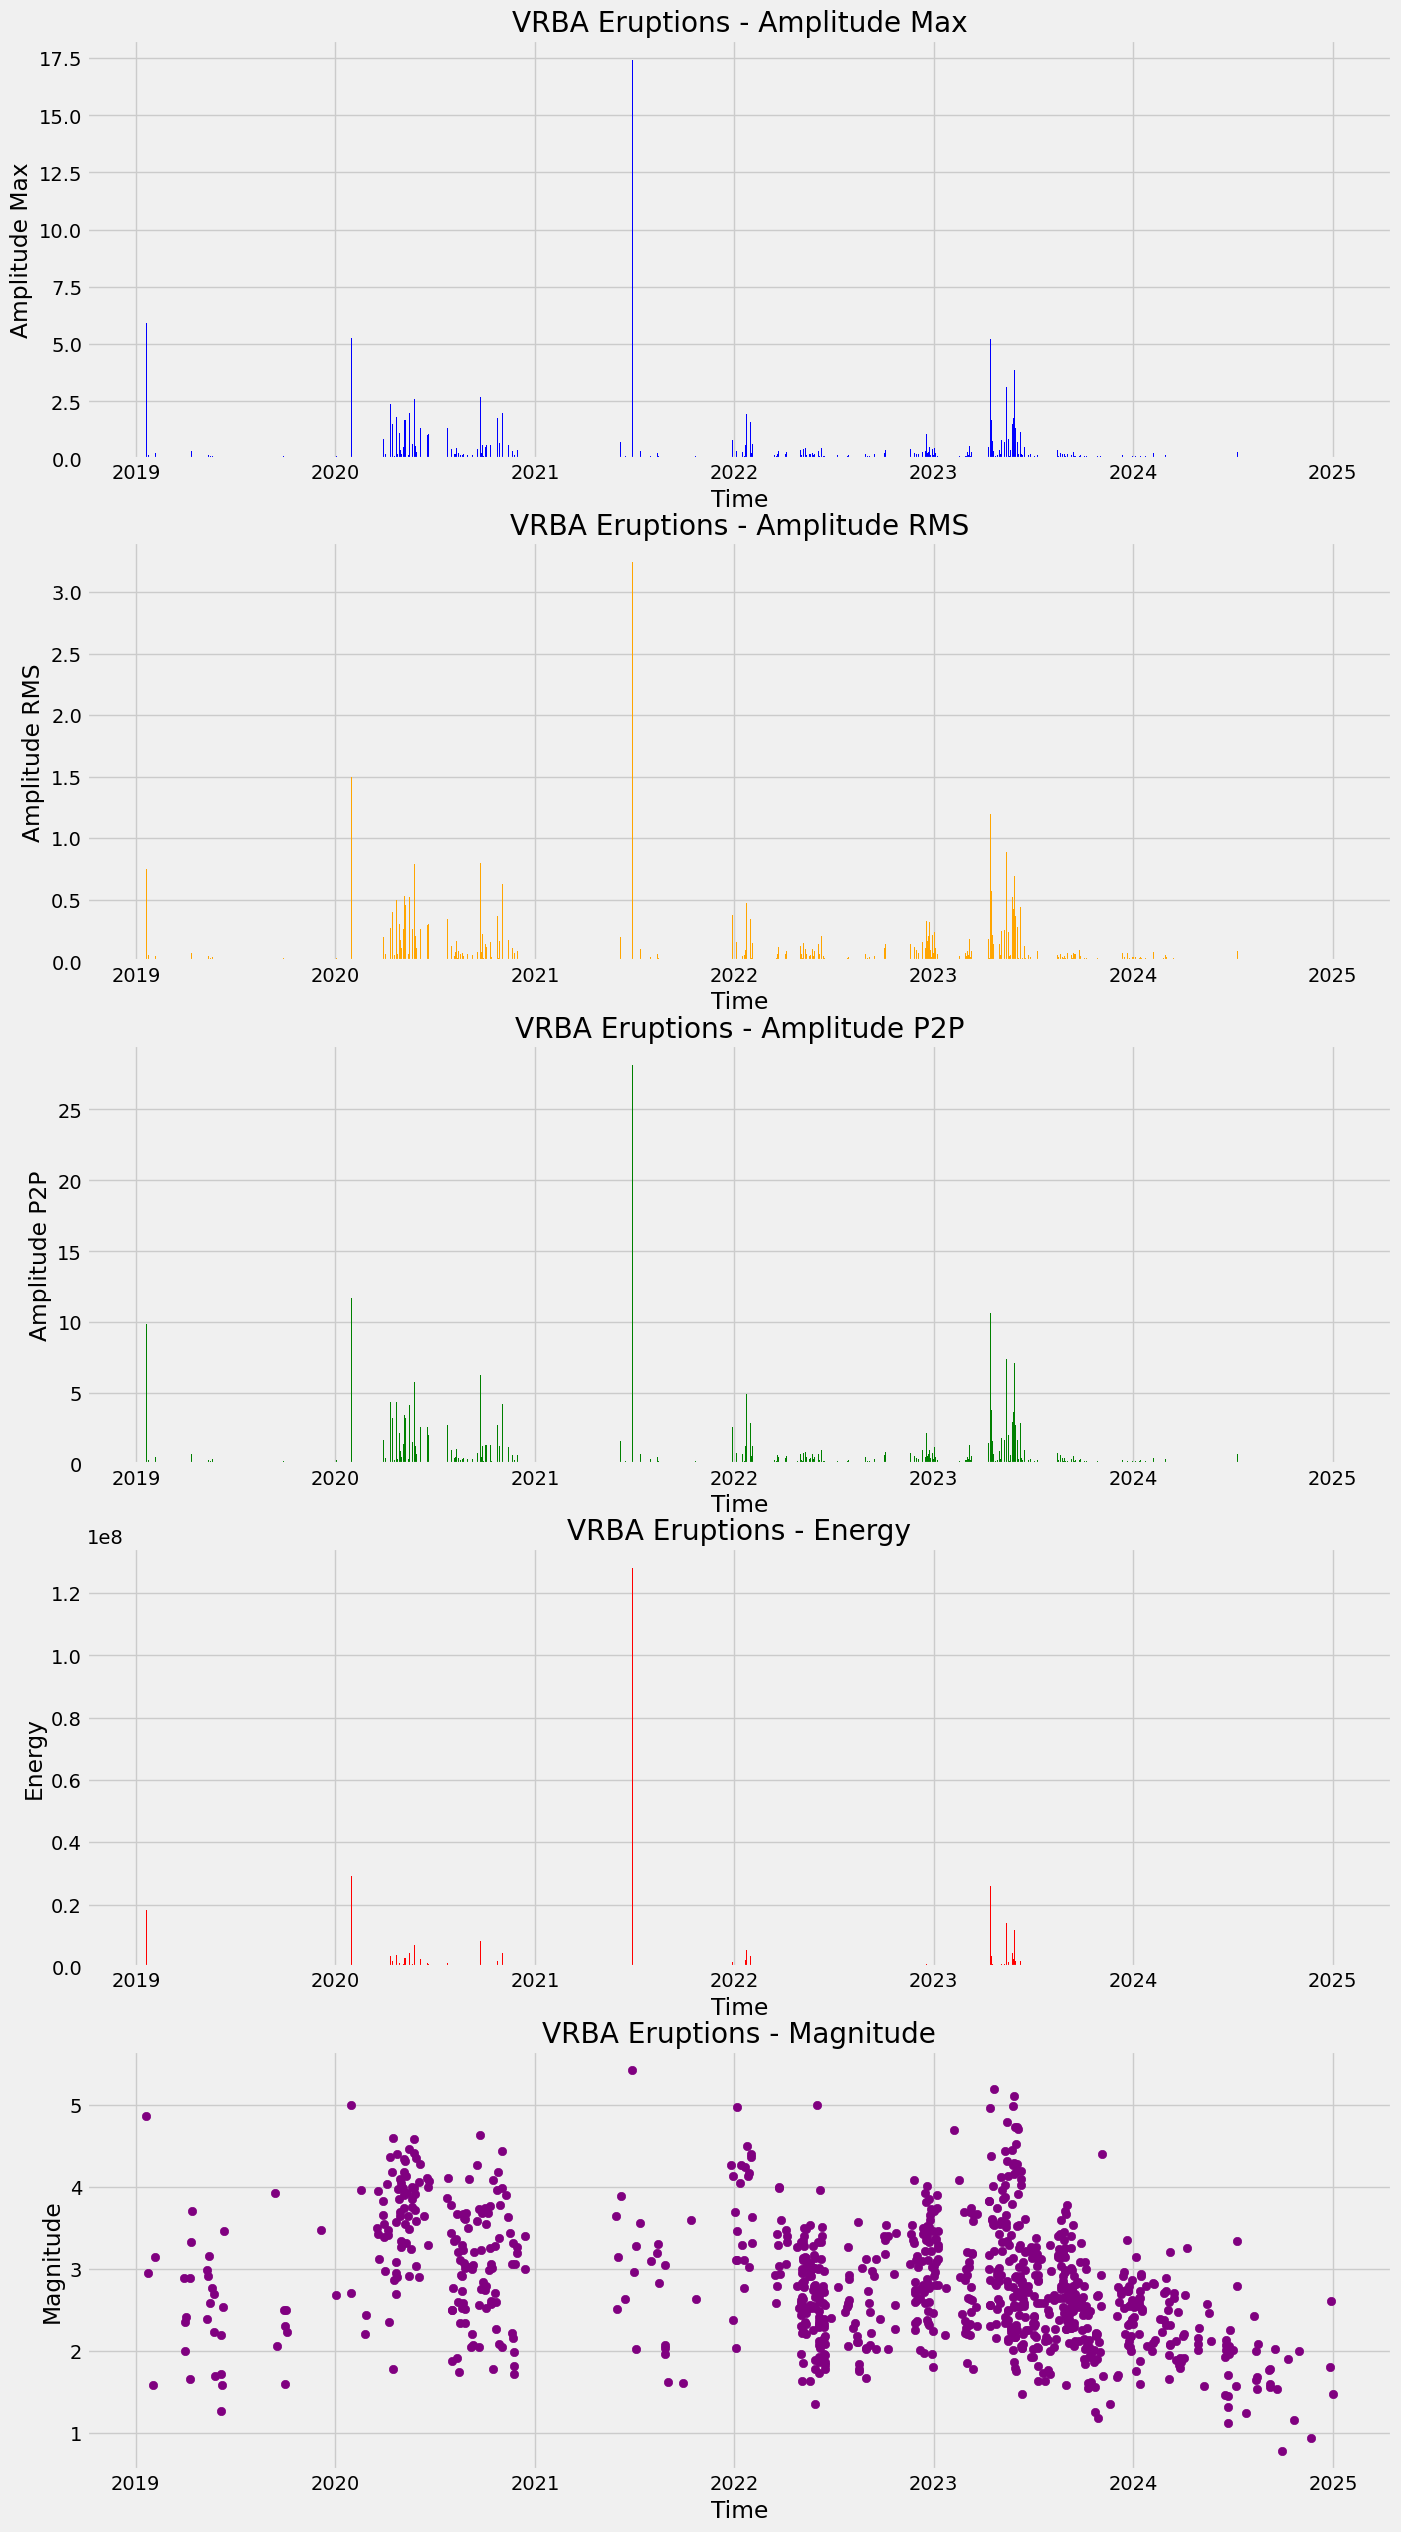

In [16]:
## Plot VRBA eruptions data

# The data is not in right order. We will sort it by t1, the start time of the eruption
VRBA_eruptions_df = VRBA_eruptions_df.sort_values(by='t1')
# # Add new columns showing the duration of the eruption
# VRBA_eruptions_df['duration'] = (VRBA_eruptions_df['t2'] - VRBA_eruptions_df['t1']).dt.total_seconds() # Duration in seconds


# Plot a bar graph of the VRBA eruptions
plt.figure(figsize=(15, 30))
plt.subplot(5, 1, 1)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_max'], color='blue')
plt.title('VRBA Eruptions - Amplitude Max')
plt.xlabel('Time')
plt.ylabel('Amplitude Max')
plt.subplot(5, 1, 2)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_rms'], color='orange')
plt.title('VRBA Eruptions - Amplitude RMS')
plt.xlabel('Time')
plt.ylabel('Amplitude RMS')
plt.subplot(5, 1, 3)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_p2p'], color='green')
plt.title('VRBA Eruptions - Amplitude P2P')
plt.xlabel('Time')
plt.ylabel('Amplitude P2P')
plt.subplot(5, 1, 4)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['energy'], color='red')
plt.title('VRBA Eruptions - Energy')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.subplot(5, 1, 5)
plt.scatter(VRBA_eruptions_df['t1'], VRBA_eruptions_df['magnitude'], color='purple')
plt.title('VRBA Eruptions - Magnitude')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.show()

In [17]:
print(f'Percentage of eruptions in 2023: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2023]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2022: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2022]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2021: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2021]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2020: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2020]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2019: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2019]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2024: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2024]) / len(VRBA_eruptions_df) * 100:.2f}%' )

Percentage of eruptions in 2023: 40.58%
Percentage of eruptions in 2022: 25.75%
Percentage of eruptions in 2021: 2.57%
Percentage of eruptions in 2020: 17.30%
Percentage of eruptions in 2019: 3.60%
Percentage of eruptions in 2024: 10.20%


Besides the magnitude, we can see that they follow a similar pattern. It could mean there is high correlation between them.

### Continuous Measurements Data

Let's see how the Rincon de la Vieja and Rincon data is distributed over time.

####  continuous Data

In [18]:
# rsam_VORI_df = rsam_VORI_df[(rsam_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(rsam_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]
# dsar_VORI_df = dsar_VORI_df[(dsar_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(dsar_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]

# rsam_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv', index=False)
# dsar_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv', index= False)


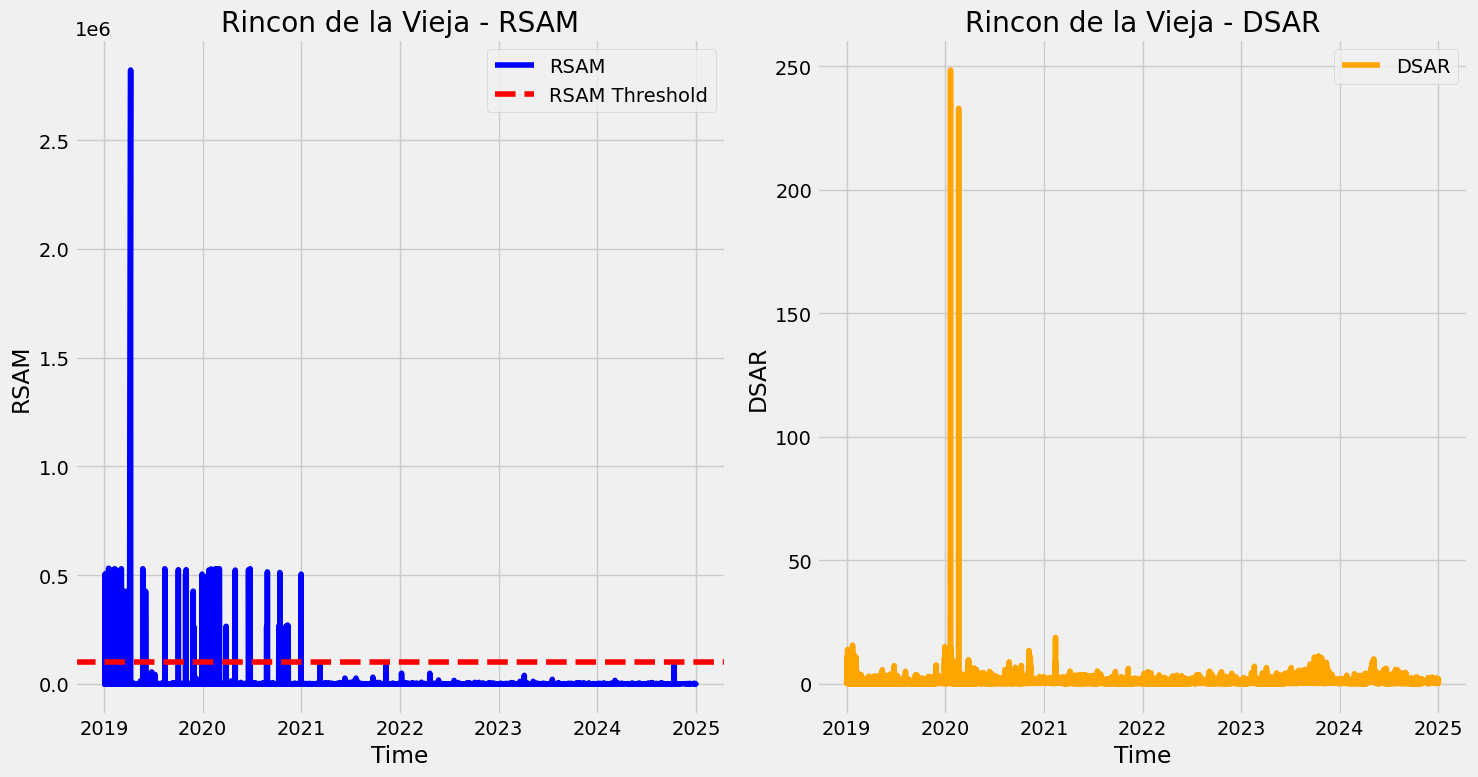

In [19]:
## Plot data from VRBA station
# [dsar , rsam, trigger  freq_bands_mean    freq_top_k    freq_index spectral_kurtosis      tonality]
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.axhline(y=1e5, color='red', linestyle='--', label='RSAM Threshold')

plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

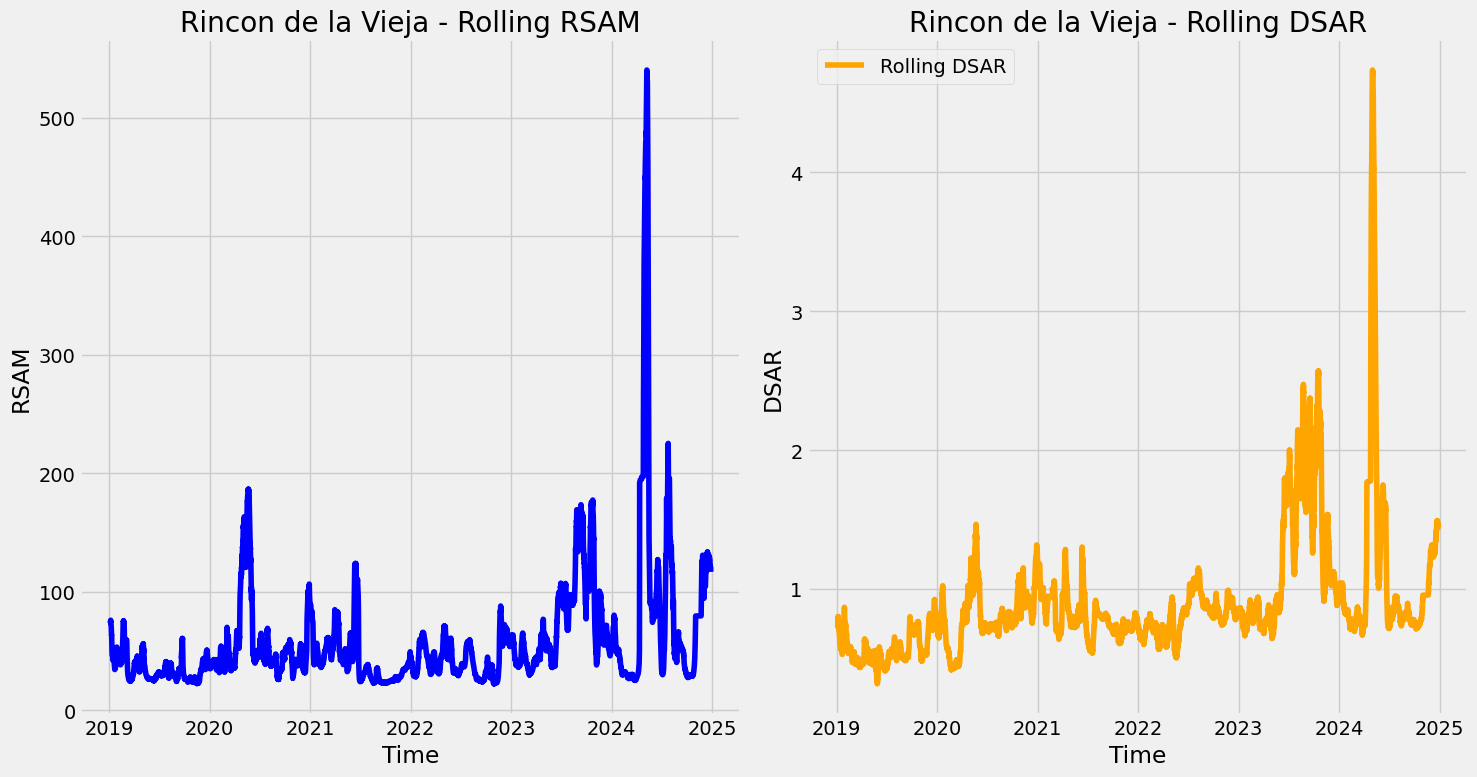

In [20]:
rolling_rsam = Rincon_de_la_Vieja_df['rsam'][(Rincon_de_la_Vieja_df['rsam']<1e5)&(Rincon_de_la_Vieja_df['rsam']>20)].rolling(window=10080, center=True).median()
rolling_dsar = Rincon_de_la_Vieja_df['dsar'].rolling(window=10080, center=True).median()

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rolling_rsam.index, rolling_rsam.values, label='Rolling RSAM', color='blue')
plt.title('Rincon de la Vieja - Rolling RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.subplot(1, 2, 2)
plt.plot(rolling_dsar.index, rolling_dsar.values, label='Rolling DSAR', color='orange')
plt.title('Rincon de la Vieja - Rolling DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


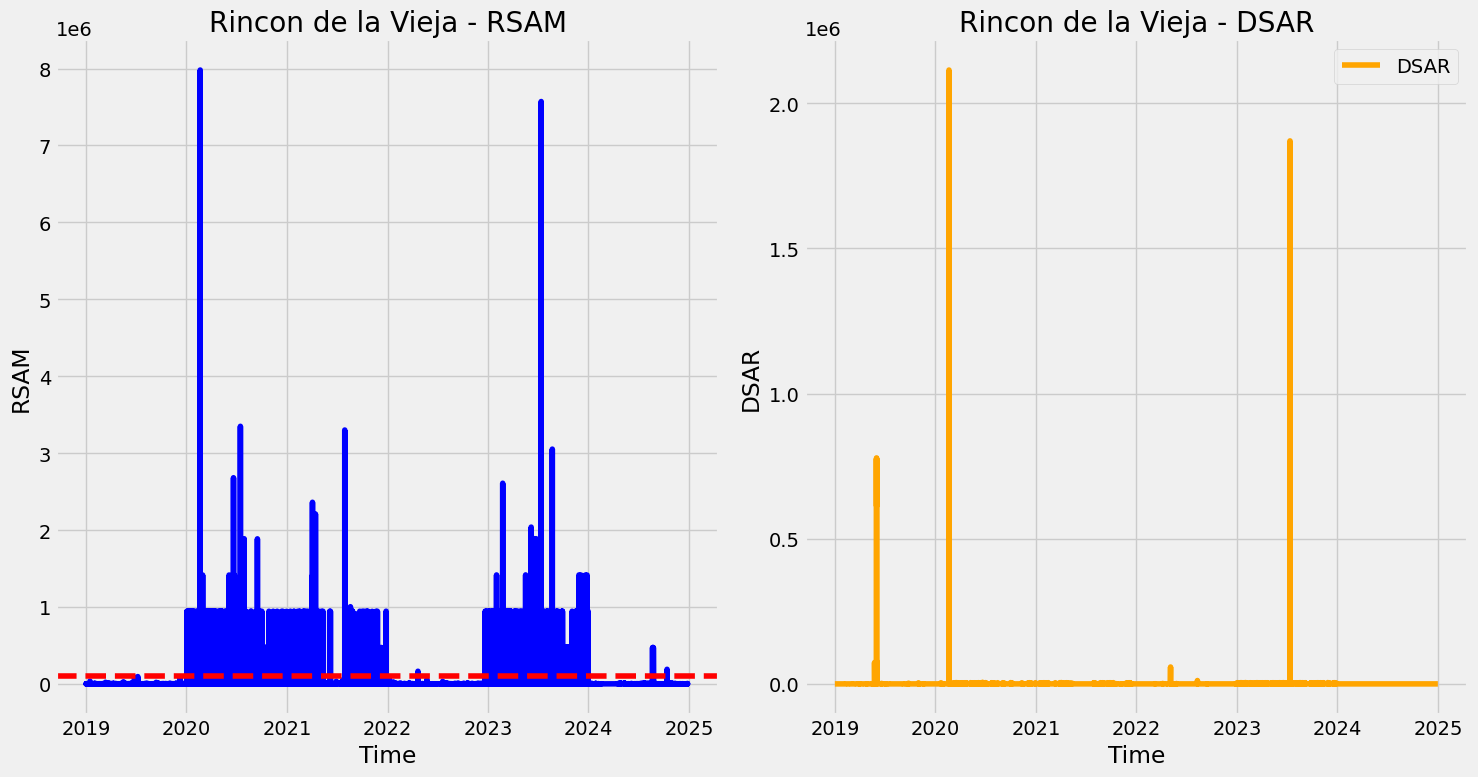

In [21]:
## Plot data from the VORI STATION
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rsam_VORI_df.index, rsam_VORI_df['value'], label='RSAM', color='blue')
plt.axhline(y=1e5, color='red', linestyle='--', label='RSAM Threshold')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.subplot(1, 2, 2)
plt.plot(dsar_VORI_df.index, dsar_VORI_df['value'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

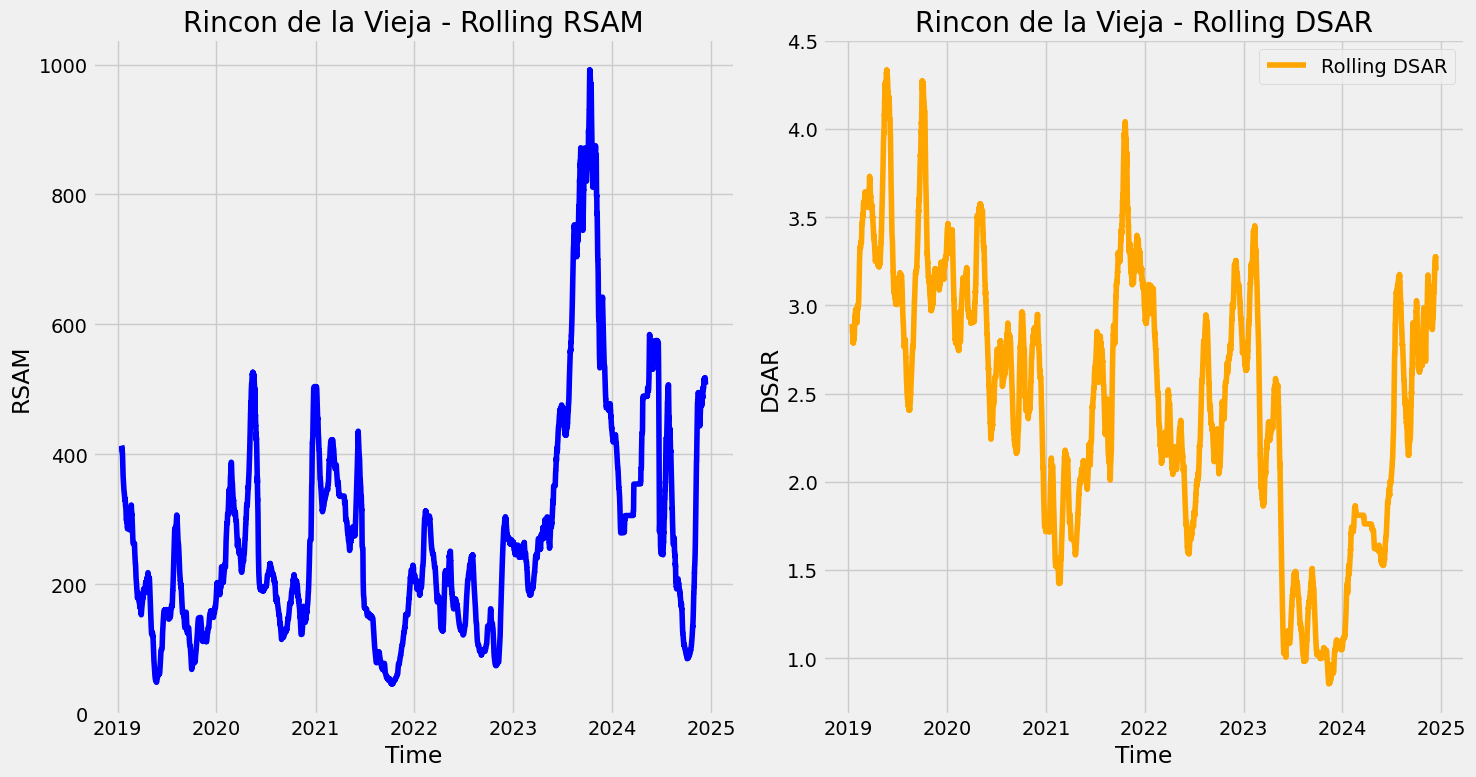

In [22]:
rolling_rsam_vori = rsam_VORI_df['value'][(rsam_VORI_df['value']<1e5)&(rsam_VORI_df['value']>20)].rolling(window=43200, center=True).median()
rolling_dsar_vori = dsar_VORI_df['value'].rolling(window=43200, center=True).median()
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)    
plt.plot(rolling_rsam_vori.index, rolling_rsam_vori.values, label='Rolling RSAM', color='blue')
plt.title('Rincon de la Vieja - Rolling RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.subplot(1, 2, 2)
plt.plot(rolling_dsar_vori.index, rolling_dsar_vori.values, label='Rolling DSAR', color='orange')
plt.title('Rincon de la Vieja - Rolling DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


We see some outliers and some missing values in the data. For the Rsam value, we will apply a trheshod to get rid of the outliers and the noise in the data. 

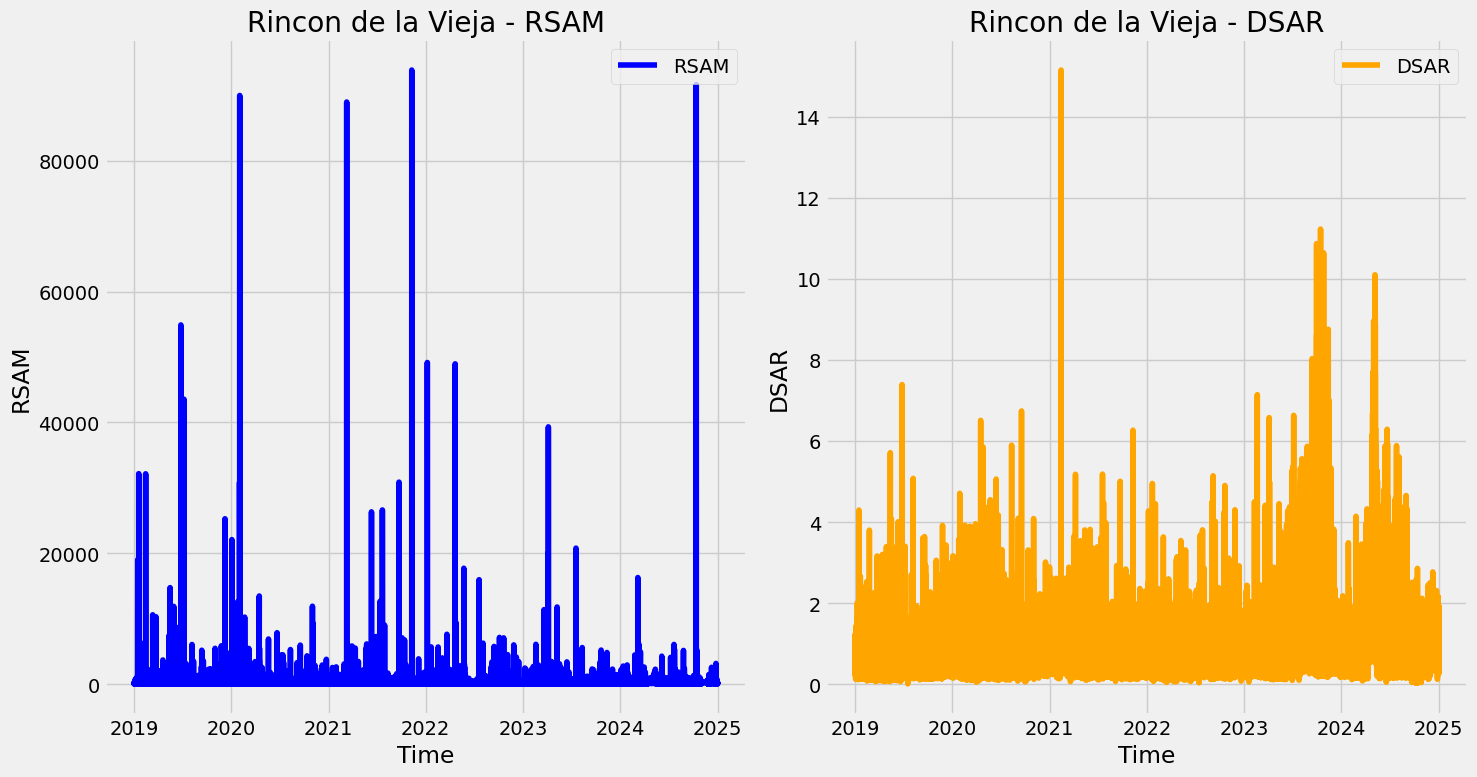

In [23]:
## Plot data with RSAM between 20 and 1e5

Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df[(20 < Rincon_de_la_Vieja_df['rsam']) & (Rincon_de_la_Vieja_df['rsam'] < 1e5)]

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


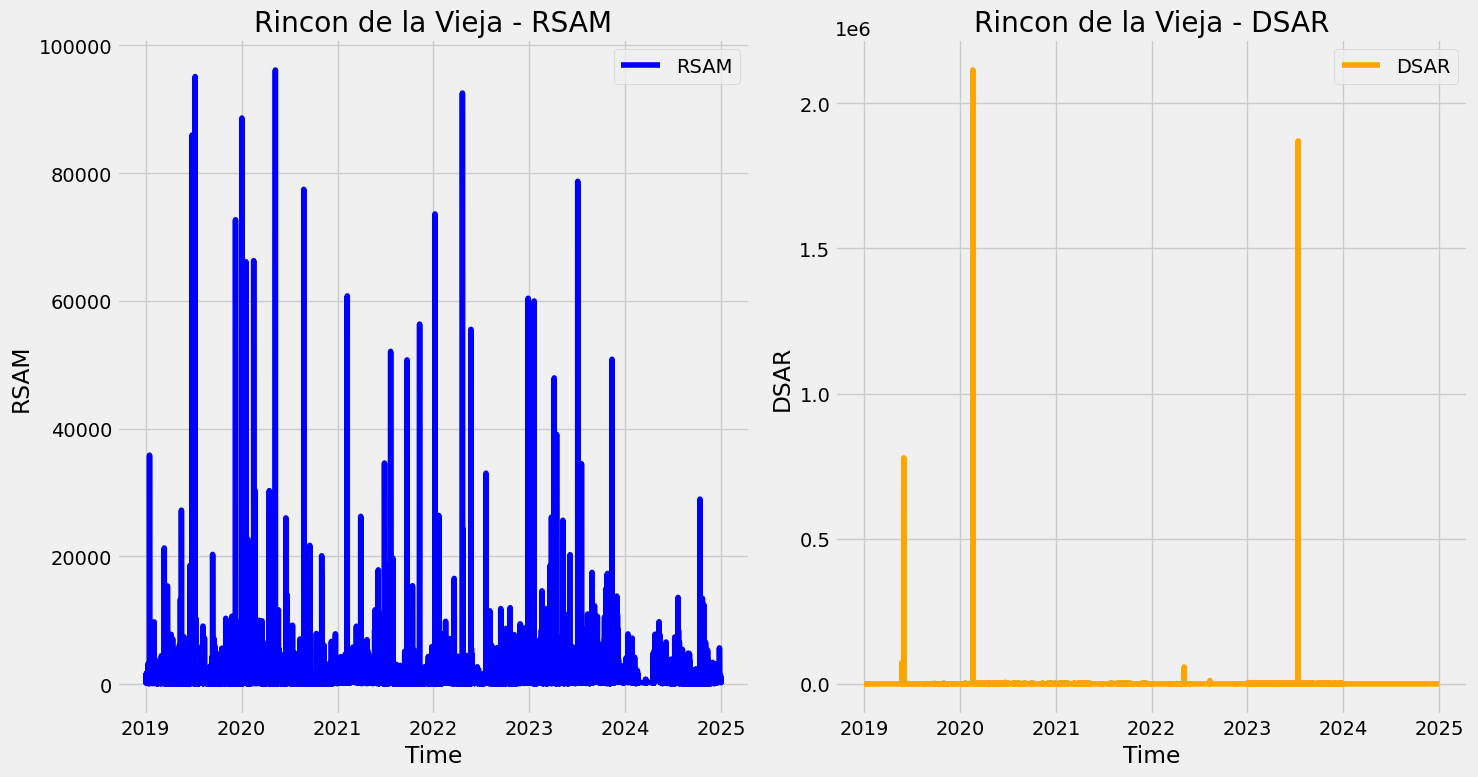

In [25]:
rsam_VORI_df = rsam_VORI_df[(20 < rsam_VORI_df['value']) & (rsam_VORI_df['value'] < 1e5)]


plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rsam_VORI_df.index, rsam_VORI_df['value'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(dsar_VORI_df.index, dsar_VORI_df['value'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

We are going to see how much data is missing in the Rincon de la Vieja continuous dataframe.

In [26]:
## Assessing missing data in Rincon de la Vieja continuous dataset


# Store the first and last time of data being recorded
# VRBA station
rsam_VRBA = Rincon_de_la_Vieja_df['rsam'][Rincon_de_la_Vieja_df['rsam'].notnull()]
dsar_VRBA = Rincon_de_la_Vieja_df['dsar'][Rincon_de_la_Vieja_df['dsar'].notnull()]
rsam_VRBA_first_time = rsam_VRBA.index.min()
dsar_VRBA_first_time = dsar_VRBA.index.min()
rsam_VRBA_last_time = rsam_VRBA.index.max() 
dsar_VRBA_last_time = dsar_VRBA.index.max()
print(f"rsam_VRBA data recorded from {rsam_VRBA_first_time} to {rsam_VRBA_last_time}")
print(f"dsar_VRBA data recorded from {dsar_VRBA_first_time} to {dsar_VRBA_last_time}")

# VORI station
rsam_VORI_first_time = rsam_VORI_df.index.min()
dsar_VORI_first_time = dsar_VORI_df.index.min()
rsam_VORI_last_time = rsam_VORI_df.index.max()
dsar_VORI_last_time = dsar_VORI_df.index.max()
print(f"rsam_VORI data recorded from {rsam_VORI_first_time} to {rsam_VORI_last_time}")
print(f"dsar_VORI data recorded from {dsar_VORI_first_time} to {dsar_VORI_last_time}")
print("\n")
# Compute the difference between the two timestamps
expected_points = (pd.to_datetime('2025-01-01') - pd.to_datetime('2019-01-01'))/pd.Timedelta('1min')

print(f" Supposed total duration of measured data: {expected_points} minutes")
print("\n")

# Calculate the actual number of data points recorded
actual_data_points0 =  rsam_VRBA.shape[0]
actual_data_points1 =  dsar_VRBA.shape[0]
actual_data_points2 = rsam_VORI_df.shape[0]
actual_data_points3 = dsar_VORI_df.shape[0]
print(f" Actual number of data points recorded for rsam_VRBA: {actual_data_points0}")# Calculate the expected number of data points for continuous recording every minute
print(f" Actual number of data points recorded for dsar_VRBA: {actual_data_points1}")
print(f" Actual number of data points recorded for rsam_VORI: {actual_data_points2}")
print(f" Actual number of data points recorded for dsar_VORI: {actual_data_points3}")
print("\n")

missing_data_points = expected_points - actual_data_points0
missing_data_points1 = expected_points - actual_data_points1
missing_data_points2 = expected_points - actual_data_points2
missing_data_points3 = expected_points - actual_data_points3
print(f" Missing data points for rsam_VRBA: {missing_data_points}")
print(f" Missing data points for dsar_VRBA: {missing_data_points1}")
print(f" Missing data points for rsam_VORI: {missing_data_points2}")
print(f" Missing data points for dsar_VORI: {missing_data_points3}")
print("\n")
# Calculate the percentage of missing data points
missing_percentage = (missing_data_points / expected_points) * 100
missing_percentage1 = (missing_data_points1 / expected_points) * 100
missing_percentage2 = (missing_data_points2 / expected_points) * 100
missing_percentage3 = (missing_data_points3 / expected_points) * 100
print(f" Percentage of missing data points for rsam_VRBA: {missing_percentage:.2f}%")
print(f" Percentage of missing data points for dsar_VRBA: {missing_percentage1:.2f}%")
print(f" Percentage of missing data points for rsam_VORI: {missing_percentage2:.2f}%")
print(f" Percentage of missing data points for dsar_VORI: {missing_percentage3:.2f}%")




rsam_VRBA data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
dsar_VRBA data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
rsam_VORI data recorded from 2019-01-01 00:01:00 to 2024-12-31 15:09:00
dsar_VORI data recorded from 2019-01-01 00:01:00 to 2024-12-31 15:09:00


 Supposed total duration of measured data: 3156480.0 minutes


 Actual number of data points recorded for rsam_VRBA: 2323244
 Actual number of data points recorded for dsar_VRBA: 2323244
 Actual number of data points recorded for rsam_VORI: 2869285
 Actual number of data points recorded for dsar_VORI: 2926267


 Missing data points for rsam_VRBA: 833236.0
 Missing data points for dsar_VRBA: 833236.0
 Missing data points for rsam_VORI: 287195.0
 Missing data points for dsar_VORI: 230213.0


 Percentage of missing data points for rsam_VRBA: 26.40%
 Percentage of missing data points for dsar_VRBA: 26.40%
 Percentage of missing data points for rsam_VORI: 9.10%
 Percentage of missing data points for dsar_V

We see that 26.40% of the data is missing in the Rincon de la Vieja continuous dataframe from the VRBA station. However, for the VORI station, only 9.10% of the data is missing for the rsam and 7.29% for the dsar.Let's see how the missing data points are spread over time.

In [27]:
# # Take 14 minutes to compile  ---> see csv file below

# # Copy of the time column to analyze missing data
# time_df = Rincon_de_la_Vieja_df[['time']].copy()
# # Creation of a dictionary to store missing time intervals (as key) and their counts (as value)
# min_missing = {}
# # Iterate through the time DataFrame to identify missing data points and calculating the time difference
# for i in range(1, time_df.shape[0]):
#     current_time = time_df.iloc[i]
#     previous_time = time_df.iloc[i - 1]
#     time_diff = (current_time - previous_time).dt.total_seconds().values[0] / 60  # Convert to minutes
#     if time_diff > 1:
#         if time_diff not in min_missing:
#             min_missing[time_diff] = 0
#         min_missing[time_diff] += 1
# print("\nMissing time intervals (in minutes) and their counts:")
# for interval, count in sorted(min_missing.items()):
#     print(f" {interval} minutes: {count} occurrences")

# # Store dictionary keys and values in a csv file
# missing_intervals_df = pd.DataFrame(list(min_missing.items()), columns=['Missing Interval (minutes)', 'Count'])
# missing_intervals_df.to_csv("MSc_Bryan_Rincon/Rincon_missing_intervals.csv", index=False)

# print(sum(min_missing.values()))

Pas necessaire(We have a lot of gaps in the data. There are a lot of huge gaps where data is missing till at max 20 days. Those gaps are too big to be filled with interpolation. Specific treatment will be needed for those gaps. But for the smaller gaps, we can use interpolation to fill in the missing data points.)

In [28]:
# # Filling the small gaps with interpolation

# Continuous_data_df = Rincon_de_la_Vieja_df.copy()
# # Identify gaps larger than 2 minutes
# Continuous_data_df['gap'] = Continuous_data_df['time'].diff() > pd.Timedelta(minutes=2)
# # Create a cumulative sum of the gaps to identify groups of continuous data
# Continuous_data_df['gap group'] = Continuous_data_df['gap'].cumsum()
# # Count the size of each gap group
# gap = Continuous_data_df['gap group'].value_counts().sort_index()
# print(f"Number of gap groups identified: {len(gap)}")
# # Identify correctable gaps
# correctable_gaps = gap[gap > 20]  # 20 minutes
# #print(correctable_gaps)
# print(f"Number of correctable gap groups (>{20} minutes): {len(correctable_gaps)}")


# # Continuous_data_df = Continuous_data_df.infer_objects()

# Continuous_group_data_df = Continuous_data_df[Continuous_data_df['gap group'].isin(correctable_gaps.index)]
# print(f"Data points in correctable gap groups: {Continuous_group_data_df.shape}")
# Continuous_group_data_df = Continuous_group_data_df.set_index('time')
# #print(Continuous_group_data_df.head())
# Continuous_group_data_df = Continuous_group_data_df.groupby('gap group', group_keys=False).apply(lambda g: g.asfreq('1min').interpolate())
# print(f"Data points after interpolation: {Continuous_group_data_df.shape}")
# Continuous_data_df = Continuous_data_df.set_index('time')
# df = Continuous_data_df.combine_first(Continuous_group_data_df)
# print(f"Total data points after filling small gaps: {df.shape}")
# print(f"Total data points before filling small gaps: {Continuous_data_df.shape}")

# print(df.describe())
# print(Rincon_de_la_Vieja_df.describe())


# # #Continuous_data_df = Continuous_data_df.reset_index(level=0, drop=True)
# # Continuous_data_df['time_diff'] = Continuous_data_df.index.diff()
# # print(Continuous_data_df['time_diff'].describe())



In [29]:
# Continuous_data_df['time_diff'] = Continuous_data_df.index.diff()
# print(Continuous_data_df['time_diff'].describe())

In [30]:
# Missing time intervals (in minutes) and their counts:
#  2.0 minutes: 148621 occurrences
#  3.0 minutes: 68946 occurrences
#  4.0 minutes: 33505 occurrences
#  5.0 minutes: 15593 occurrences
#  6.0 minutes: 7466 occurrences
#  7.0 minutes: 3834 occurrences
#  8.0 minutes: 1832 occurrences
#  9.0 minutes: 932 occurrences
#  10.0 minutes: 471 occurrences
#  11.0 minutes: 248 occurrences
#  12.0 minutes: 144 occurrences
#  13.0 minutes: 86 occurrences
#  14.0 minutes: 46 occurrences
#  15.0 minutes: 31 occurrences
#  16.0 minutes: 22 occurrences
#  17.0 minutes: 9 occurrences
#  18.0 minutes: 8 occurrences
#  19.0 minutes: 6 occurrences
#  20.0 minutes: 5 occurrences
#  21.0 minutes: 2 occurrences
#  22.0 minutes: 3 occurrences
#  23.0 minutes: 2 occurrences
#  24.0 minutes: 1 occurrences
#  25.0 minutes: 3 occurrences
#  26.0 minutes: 6 occurrences
#  27.0 minutes: 1 occurrences
#  28.0 minutes: 3 occurrences
#  29.0 minutes: 2 occurrences
#  30.0 minutes: 1 occurrences
#  31.0 minutes: 3 occurrences
#  32.0 minutes: 1 occurrences
#  33.0 minutes: 2 occurrences
#  35.0 minutes: 3 occurrences
#  37.0 minutes: 2 occurrences
#  38.0 minutes: 1 occurrences
#  39.0 minutes: 2 occurrences
#  40.0 minutes: 4 occurrences
#  41.0 minutes: 2 occurrences
#  42.0 minutes: 4 occurrences
#  43.0 minutes: 3 occurrences
#  44.0 minutes: 3 occurrences
#  46.0 minutes: 2 occurrences
#  47.0 minutes: 2 occurrences
#  48.0 minutes: 1 occurrences
#  49.0 minutes: 1 occurrences
#  50.0 minutes: 2 occurrences
#  51.0 minutes: 1 occurrences
#  52.0 minutes: 1 occurrences
#  53.0 minutes: 2 occurrences
#  55.0 minutes: 1 occurrences
#  56.0 minutes: 1 occurrences
#  57.0 minutes: 2 occurrences
#  58.0 minutes: 1 occurrences
#  60.0 minutes: 1 occurrences
#  61.0 minutes: 1 occurrences
#  63.0 minutes: 1 occurrences
#  65.0 minutes: 2 occurrences
#  67.0 minutes: 2 occurrences
#  70.0 minutes: 2 occurrences
#  71.0 minutes: 1 occurrences
#  79.0 minutes: 1 occurrences
#  80.0 minutes: 1 occurrences
#  82.0 minutes: 1 occurrences
#  84.0 minutes: 1 occurrences
#  86.0 minutes: 2 occurrences
#  87.0 minutes: 1 occurrences
#  89.0 minutes: 1 occurrences
#  92.0 minutes: 2 occurrences
#  93.0 minutes: 1 occurrences
#  95.0 minutes: 1 occurrences
#  96.0 minutes: 1 occurrences
#  101.0 minutes: 1 occurrences
#  103.0 minutes: 1 occurrences
#  106.0 minutes: 3 occurrences
#  107.0 minutes: 1 occurrences
#  108.0 minutes: 1 occurrences
#  109.0 minutes: 1 occurrences
#  111.0 minutes: 1 occurrences
#  114.0 minutes: 1 occurrences
#  117.0 minutes: 1 occurrences
#  125.0 minutes: 1 occurrences
#  126.0 minutes: 1 occurrences
#  132.0 minutes: 1 occurrences
#  137.0 minutes: 1 occurrences
#  138.0 minutes: 2 occurrences
#  141.0 minutes: 1 occurrences
#  142.0 minutes: 2 occurrences
#  145.0 minutes: 1 occurrences
#  148.0 minutes: 1 occurrences
#  153.0 minutes: 1 occurrences
#  156.0 minutes: 1 occurrences
#  159.0 minutes: 1 occurrences
#  163.0 minutes: 2 occurrences
#  170.0 minutes: 1 occurrences
#  173.0 minutes: 1 occurrences
#  175.0 minutes: 1 occurrences
#  176.0 minutes: 1 occurrences
#  186.0 minutes: 1 occurrences
#  187.0 minutes: 1 occurrences
#  190.0 minutes: 1 occurrences
#  192.0 minutes: 1 occurrences
#  199.0 minutes: 1 occurrences
#  211.0 minutes: 1 occurrences
#  213.0 minutes: 1 occurrences
#  217.0 minutes: 1 occurrences
#  218.0 minutes: 1 occurrences
#  229.0 minutes: 1 occurrences
#  238.0 minutes: 1 occurrences
#  239.0 minutes: 1 occurrences
#  247.0 minutes: 1 occurrences
#  249.0 minutes: 1 occurrences
#  265.0 minutes: 1 occurrences
#  266.0 minutes: 1 occurrences
#  275.0 minutes: 1 occurrences
#  276.0 minutes: 1 occurrences
#  283.0 minutes: 1 occurrences
#  285.0 minutes: 1 occurrences
#  290.0 minutes: 1 occurrences
#  296.0 minutes: 2 occurrences
#  301.0 minutes: 1 occurrences
#  304.0 minutes: 1 occurrences
#  322.0 minutes: 1 occurrences
#  324.0 minutes: 1 occurrences
#  331.0 minutes: 1 occurrences
#  333.0 minutes: 1 occurrences
#  337.0 minutes: 1 occurrences
#  338.0 minutes: 1 occurrences
#  339.0 minutes: 1 occurrences
#  343.0 minutes: 1 occurrences
#  346.0 minutes: 1 occurrences
#  356.0 minutes: 1 occurrences
#  358.0 minutes: 1 occurrences
#  370.0 minutes: 1 occurrences
#  381.0 minutes: 1 occurrences
#  384.0 minutes: 1 occurrences
#  390.0 minutes: 1 occurrences
#  392.0 minutes: 2 occurrences
#  410.0 minutes: 1 occurrences
#  440.0 minutes: 1 occurrences
#  450.0 minutes: 1 occurrences
#  454.0 minutes: 1 occurrences
#  459.0 minutes: 1 occurrences
#  461.0 minutes: 1 occurrences
#  518.0 minutes: 1 occurrences
#  574.0 minutes: 1 occurrences
#  584.0 minutes: 1 occurrences
#  592.0 minutes: 1 occurrences
#  625.0 minutes: 1 occurrences
#  626.0 minutes: 1 occurrences
#  635.0 minutes: 1 occurrences
#  636.0 minutes: 1 occurrences
#  644.0 minutes: 1 occurrences
#  659.0 minutes: 1 occurrences
#  760.0 minutes: 1 occurrences
#  788.0 minutes: 1 occurrences
#  812.0 minutes: 1 occurrences
#  827.0 minutes: 1 occurrences
#  837.0 minutes: 1 occurrences
#  847.0 minutes: 1 occurrences
#  864.0 minutes: 1 occurrences
#  935.0 minutes: 1 occurrences
#  1007.0 minutes: 1 occurrences
#  1012.0 minutes: 1 occurrences
#  1029.0 minutes: 1 occurrences
#  1053.0 minutes: 1 occurrences
#  1061.0 minutes: 1 occurrences
#  1212.0 minutes: 1 occurrences
#  1442.0 minutes: 2 occurrences
#  1796.0 minutes: 1 occurrences
#  2340.0 minutes: 1 occurrences
#  2575.0 minutes: 1 occurrences
#  2882.0 minutes: 1 occurrences
#  3404.0 minutes: 1 occurrences
#  4986.0 minutes: 1 occurrences
#  6122.0 minutes: 1 occurrences
#  6961.0 minutes: 1 occurrences
#  8813.0 minutes: 1 occurrences
#  28618.0 minutes: 1 occurrences

In [31]:
Rincon_df.columns

Index(['VT', 'LP', 'tornillo'], dtype='object')

#### Seismic and Geophysical Data

In [32]:
Rincon_original_df.reset_index(inplace=True)

In [33]:
Rincon_original_df.columns

Index(['index', 'Fecha', 'VT', 'LP', 'Tcorto', 'Tremor', 'tfreq', 'Erupcion',
       'efreq', 'dpresion', 'Amplitud', 'Damplitud', 'sene', 'iene', 'VASR',
       'tornillo', 'Deslizamiento', 'Exhalacion'],
      dtype='object')

In [34]:
Rincon_original_df = Rincon_original_df.rename(columns={'Fecha':'time'})
Rincon_original_df = Rincon_original_df[(Rincon_original_df['time'] >= pd.to_datetime('2019-01-01')) & (Rincon_original_df['time'] < pd.to_datetime('2025-01-01')) ]
print("\nRincon DataFrame after filtering 2019-2024:")
Rincon_original_df.info()


Rincon DataFrame after filtering 2019-2024:
<class 'pandas.core.frame.DataFrame'>
Index: 2191 entries, 1826 to 4016
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   index          2191 non-null   int64         
 1   time           2191 non-null   datetime64[ns]
 2   VT             2191 non-null   float64       
 3   LP             2191 non-null   float64       
 4   Tcorto         2155 non-null   float64       
 5   Tremor         1812 non-null   float64       
 6   tfreq          992 non-null    float64       
 7   Erupcion       1588 non-null   float64       
 8   efreq          170 non-null    float64       
 9   dpresion       549 non-null    float64       
 10  Amplitud       777 non-null    float64       
 11  Damplitud      466 non-null    object        
 12  sene           187 non-null    float64       
 13  iene           181 non-null    float64       
 14  VASR           185 non-null  

There is many features missing many values. I will take only features having 100% of data of the 2191 required (2024 - 2019 in days).

In [35]:
# ## Keep only features having less than 5% missing data
# Rincon_df = Rincon_df[['time','VT', 'LP', 'tornillo']]
# Rincon_df.to_csv('MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv', index=False)

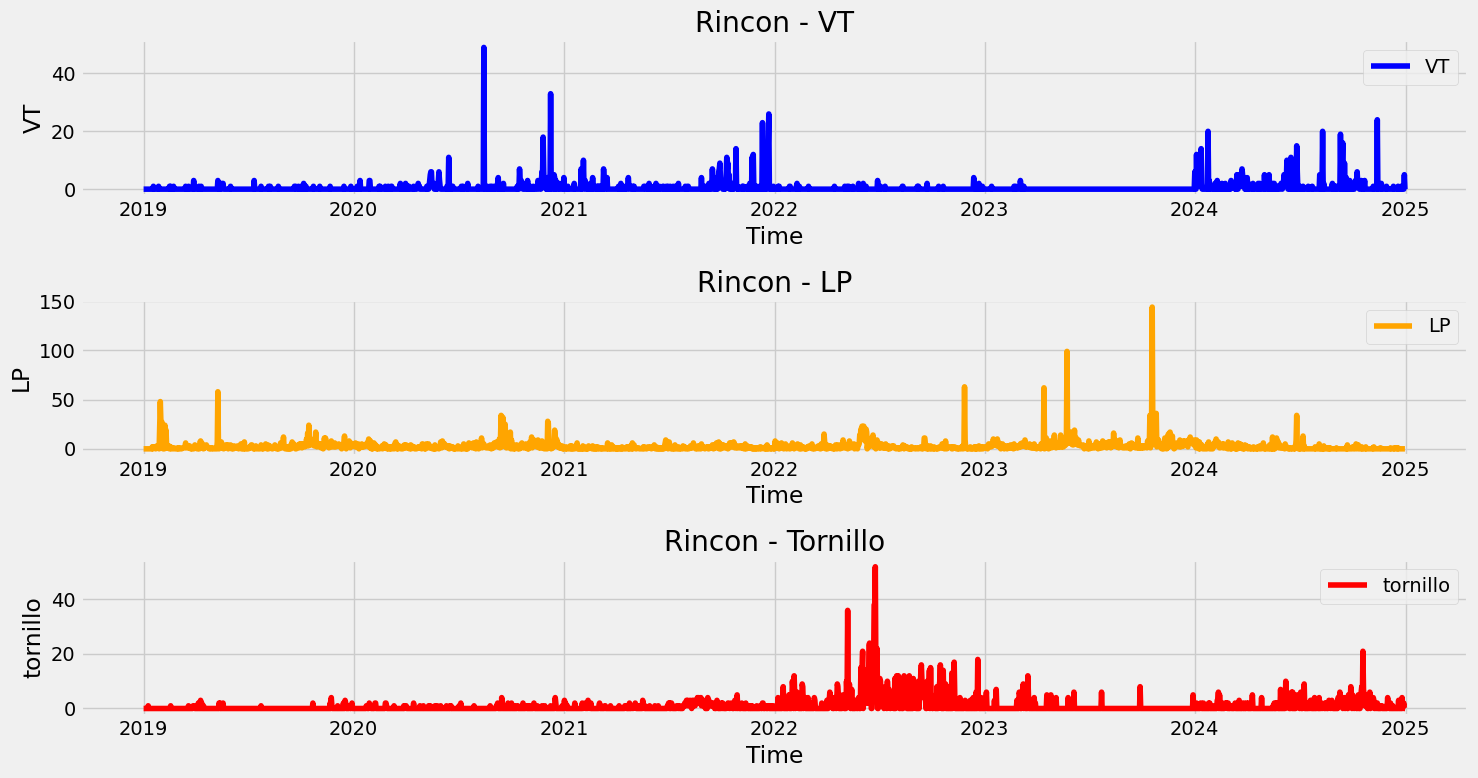

In [36]:
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(Rincon_df.index, Rincon_df['VT'], label='VT', color='blue')
plt.title('Rincon - VT')
plt.xlabel('Time')
plt.ylabel('VT')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(Rincon_df.index, Rincon_df['LP'], label='LP', color='orange')
plt.title('Rincon - LP')
plt.xlabel('Time')
plt.ylabel('LP')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(Rincon_df.index , Rincon_df['tornillo'], label='tornillo', color='red')
plt.title('Rincon - Tornillo')
plt.xlabel('Time')
plt.ylabel('tornillo')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Check the date are ascending in Rincon 
for i in range(1, Rincon_df.shape[0]):
    current_time = Rincon_df.index[i]
    previous_time = Rincon_df.index[i - 1]
    if current_time < previous_time:
        print(f"Data is not in ascending order at index {i}: {current_time} < {previous_time}")

They doesnt seem to follow a specific pattern. There seems to be possible outliers . To handle them, I will apply a mean filtering technique to smooth the data and reduce their impact.

# Data preparation (features extraction,...)

## Eruption data features extraction

### Temporal Features

We can use the seasons in costa rica to categorize the eruptions in VRBA. The dry season is from December to April and the wet season is from May to November. We can create a new column in the VRBA eruptions dataframe that will tell us if the eruption happened in the dry or wet season.
https://costa-rica-guide.com/travel/weather/seasons-in-costa-rica/
Evenmore, we can extract the month and time of the day  of each eruption as new features.

In [38]:
def add_temporal_features(df):
    # 0 = Dry Season (Dec–Apr), 1 = Rainy Season (May–Nov)
    dry_months = {12, 1, 2, 3, 4}
    df = df.copy()
    df['season'] = np.where(df['t1'].dt.month.isin(dry_months), 0, 1).astype(int)

    # month feature
    df['month'] = df['t1'].dt.month
    # Cyclical month feature
    df['month norm'] = np.sin((df['t1'].dt.month - 1) * (2 * np.pi / 12))

    # time-of-day feature
    df['Time of the Day'] = df['t1'].dt.hour + df['t1'].dt.minute / 60
    # Cyclical time-of-day feature
    tod = df['t1'].dt.hour + df['t1'].dt.minute / 60
    df['Time of the Day norm'] = np.sin(tod * (2 * np.pi / 24))
    return df

# # Apply to VRBA_eruptions_df and keep season synced
# VRBA_eruptions_df = add_temporal_features(VRBA_eruptions_df)
# VRBA_eruptions_df.info()
# VRBA_with_energy_category_df['season'] = VRBA_eruptions_df['season'].values

### Analysis New features

Here, as we known that the energy, amplitude rms, amplitude max, amplitude p2p, duration and magnitude are computed after the eruption occured, these features cannot be used for prediction. Thus, we will analyze the correlation of the new features (season, month, time of the day) with the laahres to see if they can be useful for prediction. But they will be used as target variables for classification models.

In [39]:
VRBA_eruptions_df.columns

Index(['t1', 't2', 'amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy',
       'duration', 'magnitude', 'Lahares', 'Time before Lahar (min)'],
      dtype='object')

In [40]:
# Prepare final DataFrames for features and target

feature_columns= ['season', 'month norm', 'Time of the Day norm', 'month', 'Time of the Day']
feature_norm_columns = ['season', 'month norm', 'Time of the Day norm']
# VRBA_all_features_df = VRBA_eruptions_df[['season', 'month', 'Time of the Day']].copy()
# VRBA_all_features_df.info()


target_columns = ['Lahares','duration','amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy_scaled', 'magnitude']
# VRBA_target_df = VRBA_eruptions_df[['Lahares','duration','amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy_scaled']].copy()
# VRBA_target_df.info()

# VRBA_eruptions_df.info()

In [41]:
# VRBA_eruptions_df['Lahares'] = VRBA_eruptions_df['Lahares'].astype(int)
# fast_eda(VRBA_eruptions_df[['amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy', 'Lahares', 'season', 'month', 'Time of the Day','magnitude', 'duration']], target= 'Lahares')

In [42]:
# Scale the energy column
scaler = StandardScaler()
VRBA_eruptions_df['energy_scaled'] = scaler.fit_transform(VRBA_eruptions_df[['energy']])

In [43]:
VRBA_df = VRBA_eruptions_df[feature_norm_columns + target_columns].copy()

VRBA_df['Lahares'] = VRBA_df['Lahares'].astype(int)


KeyError: "['season', 'month norm', 'Time of the Day norm'] not in index"

As we can see, the energy, amplitude rms, amplitude max, amplitude p2p are higly correlated with each other. Thus, we will keep only one of the feature to estimate the others and reduce the dimensionality of the dataset.

In [ ]:
VRBA_df.columns

Index(['season', 'month norm', 'Time of the Day norm', 'Lahares', 'duration',
       'amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy_scaled',
       'magnitude'],
      dtype='object')

In [ ]:
TSNE_FEATURES = list(VRBA_df.drop(columns=target_columns).columns)
print(TSNE_FEATURES)
train_tsne = VRBA_df[TSNE_FEATURES].values
y_tsne = VRBA_df['Lahares'].values

['season', 'month norm', 'Time of the Day norm']


In [ ]:

%%time
plot_tsne = TSNE().fit(train_tsne)


CPU times: total: 3.16 s
Wall time: 3.28 s


C:\Users\bryan\AppData\Local\Temp\ipykernel_29256\4224289989.py:6: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,


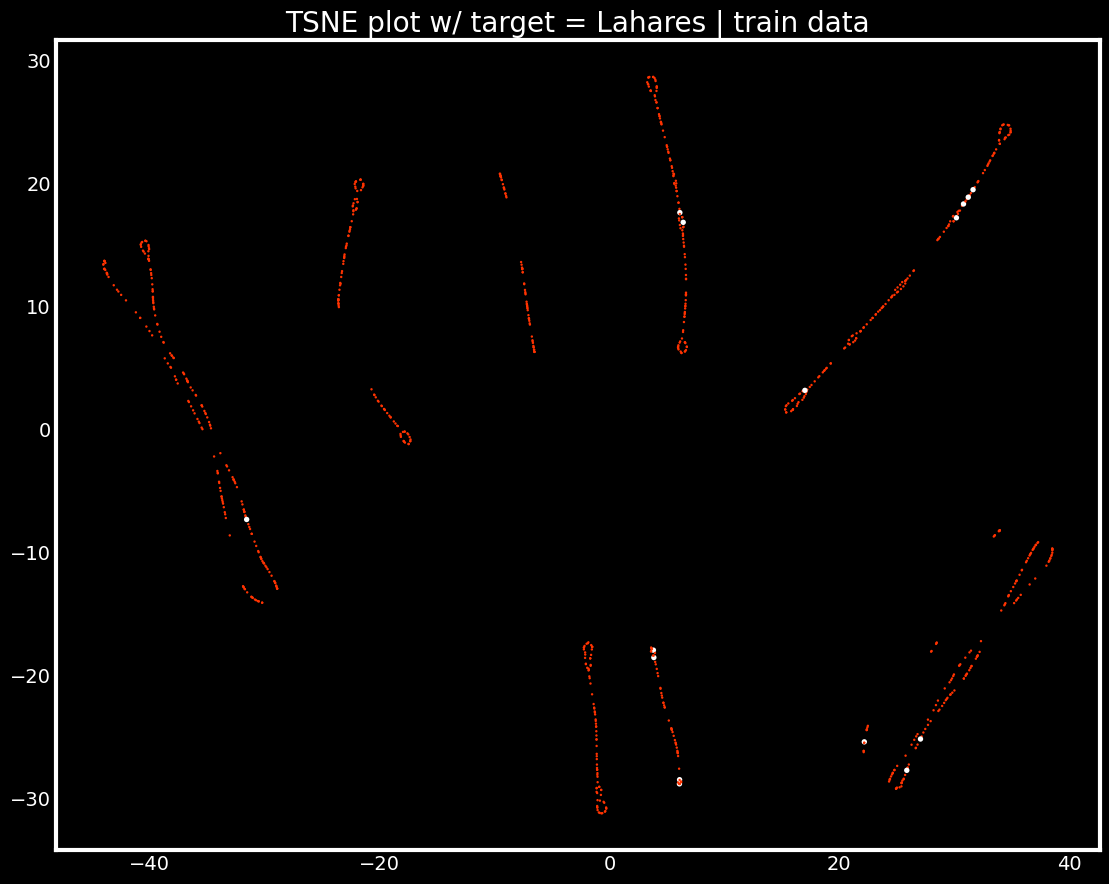

In [ ]:
plt.style.use("dark_background")
plt.figure(figsize = (12, 10))

marker_sizes = [15 if hue == 1 else 3 for hue in y_tsne]

ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,
                     linewidth = 0, palette = ["#ff3300", "#ffffff", "#33cc33"],
                     legend=False)
plt.grid(False)
plt.title(f"TSNE plot w/ target = Lahares | train data")
plt.show()

In [ ]:
# TSNE_FEATURES = list(VRBA_df.drop(columns=['Lahares', 'season', 'month norm', 'Time of the Day norm']).columns)
# print(TSNE_FEATURES)
# train_tsne = VRBA_df[TSNE_FEATURES].values
# y_tsne = VRBA_df['Lahares'].values

In [ ]:
# %%time
# plot_tsne = TSNE().fit(train_tsne)

In [ ]:
# plt.style.use("dark_background")
# plt.figure(figsize = (12, 10))

# marker_sizes = [15 if hue == 1 else 3 for hue in y_tsne]

# ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,
#                      linewidth = 0, palette = ["#ff3300", "#ffffff", "#33cc33"],
#                      legend=False)
# plt.grid(False)
# plt.title(f"TSNE plot w/ target = Lahares | train data")
# plt.show()

### Continuous Measurements Features Extraction

#### Eruption chains

A lot of eruptions happens in a chain. Here we will identify those chains and create a new feature in the VRBA eruptions dataframe that will categorize if the eruption is part of a chain or not. An eruption is considered part of a chain if it happens within the window size (predefined) of another eruption.

In [44]:
## Find sequences of following eruptions
def find_eruption_chains(df, window_size):
    chains = []
    # Check if dataframe is empty
    if df.empty:
        return chains
    # Ensure data is sorted by time 
    df_sorted = df.sort_values('t1')
    # Initialize the first chain with the first eruption
    # current_chain stores the indices of the eruptions
    first_id = df_sorted.index[0] 
    current_chain = [int(first_id)]
    # Keep track of the 'last seen' time to compare against
    last_time = df_sorted.loc[first_id, 't1']
    # Iterate through the rest of the eruptions
    for i in range(1, len(df_sorted)):
        curr_id = df_sorted.index[i]
        curr_time = df_sorted.loc[curr_id, 't1']
        # Current Time vs. LAST ADDED Time 
        if curr_time - last_time <= window_size:
            # In the window of the previous eruption, add to chain
            current_chain.append(int(curr_id))
            last_time = curr_time 
        else:
            # Time gap is too big
            # Store the finished chain
            chains.append(current_chain)
            # Start a new chain with the current eruption
            current_chain = [int(curr_id)]
            last_time = curr_time
    # Append the final chain after the loop finishes
    chains.append(current_chain)
    head_chains = [chain[0] for chain in chains]
    return chains, head_chains


It might interresting to predict the head of the chain eruptions because they have the particularity of not being influenced by previous eruptions.

In [45]:
WINDOW_SIZE = pd.Timedelta(days=3)
WINDOW_SIZE2 = pd.Timedelta(days=5)


In [46]:
## Store the eruption chains and their heads with some stats printed
# VRBA_chains_df = VRBA_eruptions_df[VRBA_eruptions_df['magnitude'] >= 2.5].copy()

# print(f'Number of eruptions with magnitude >= 2.5: {len(VRBA_chains_df)}')

# print(f"Number of eruptions with magnitude >= 2.5 not in 2023: {len(VRBA_chains_df[VRBA_chains_df['t1'].dt.year != 2023])}")

eruption_chains, head_chains = find_eruption_chains(VRBA_eruptions_df, WINDOW_SIZE2)
# eruption_chains, head_chains = find_eruption_chains(VRBA_chains_df, WINDOW_SIZE2)

print(f"Found {len(eruption_chains)} distinct eruption sequences.")
for y, chain in enumerate(eruption_chains):
        print(f"Sequence {y+1}: ({len(chain)}) eruptions {chain}")

print("\n")

# Calculate the time differences between each chains
chain_time_differences = []
chain_gaps = []
for i, chain in enumerate(eruption_chains):
    first_erup_id = chain[0]
    last_erup_id = chain[-1]
    first_time = VRBA_eruptions_df.loc[first_erup_id, 't1']
    last_time = VRBA_eruptions_df.loc[last_erup_id, 't1']
    # first_time = VRBA_chains_df.loc[first_erup_id, 't1']
    # last_time = VRBA_chains_df.loc[last_erup_id, 't1']
    time_diff = last_time - first_time
    if i+1 < len(eruption_chains):
        next_chain = eruption_chains[i+1]
        next_first_erup_id = next_chain[0]
        next_first_time = VRBA_eruptions_df.loc[next_first_erup_id, 't1']
        # next_first_time = VRBA_chains_df.loc[next_first_erup_id, 't1']
        gap = next_first_time - last_time
        chain_gaps.append(gap)

        chain_time_differences.append(time_diff)
        print(f"Sequence {i+1} duration: {time_diff} ")

print("\n")
print("Gaps between sequence:")
for i, gap in enumerate(chain_gaps):
    print(f"Gap after sequence {i+1}: {gap}")

    

Found 79 distinct eruption sequences.
Sequence 1: (2) eruptions [0, 1]
Sequence 2: (2) eruptions [2, 3]
Sequence 3: (4) eruptions [4, 5, 6, 7]
Sequence 4: (4) eruptions [8, 9, 10, 11]
Sequence 5: (9) eruptions [12, 13, 14, 15, 16, 17, 18, 19, 20]
Sequence 6: (6) eruptions [21, 22, 23, 24, 25, 26]
Sequence 7: (2) eruptions [27, 28]
Sequence 8: (5) eruptions [29, 30, 31, 32, 33]
Sequence 9: (1) eruptions [34]
Sequence 10: (1) eruptions [35]
Sequence 11: (2) eruptions [36, 37]
Sequence 12: (1) eruptions [38]
Sequence 13: (2) eruptions [39, 40]
Sequence 14: (4) eruptions [41, 42, 43, 44]
Sequence 15: (58) eruptions [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102]
Sequence 16: (1) eruptions [103]
Sequence 17: (4) eruptions [104, 105, 106, 107]
Sequence 18: (2) eruptions [108, 109]
Sequence 19: (40) eruption

In [47]:
def find_days_of_low_magnitude_eruptions(chain, df,  window_size,magnitude_threshold=2.0):
    erup_time = pd.to_datetime(df.loc[chain, 't1']) 
    erup_magnitude = df.loc[chain, 'magnitude']
    
    low_magnitude_sequences = []
    low_magnitude_sequences_times = []
    
    low_mag_seq = []
    low_mag_seq_times = []
    
    # We keep track of the last strong eruption time to calculate the "true" gap duration when we encounter a new strong eruption
    last_strong_erup_time = erup_time.iloc[0] # Init with the time of the first eruption in the chain, but it will be updated as we go through the chain
    
    for i in range(len(chain)):
        current_time = erup_time.iloc[i]
        current_mag = erup_magnitude.iloc[i]
        
        if current_mag < magnitude_threshold:
            low_mag_seq.append(chain[i])
            low_mag_seq_times.append(current_time)
        else:
            # Find a strong eruption, we check if we had a sequence of low magnitude eruptions before
            if low_mag_seq:
                # Calculate the "true" gap duration from the last strong eruption to the current time (which is the time of the new strong eruption)
                true_gap_duration = current_time - last_strong_erup_time
                # Keep the sequence if the true gap duration is greater than or equal to the window size, otherwise ignore it
                if true_gap_duration >= window_size:
                    print(f"Low mag seq: {low_mag_seq_times[0].strftime('%Y-%m-%d')} to {low_mag_seq_times[-1].strftime('%Y-%m-%d')} | Gap Duration: {true_gap_duration} | Dropped: {len(low_mag_seq)}")
                    low_magnitude_sequences.append(low_mag_seq)
                    
                    low_magnitude_sequences_times.append(low_mag_seq_times)
                # else:
                #     print(f"Ignored small gap: {true_gap_duration} (Need {window_size.days} days)")
                    
                low_mag_seq = []
                low_mag_seq_times = []
            
            last_strong_erup_time = current_time
    # After the loop, we check if there is an ongoing sequence of low magnitude eruptions that we need to evaluate
    if low_mag_seq:
        # Calculate the "true" gap duration from the last strong eruption to the last low magnitude eruption time
        true_gap_duration = low_mag_seq_times[-1] - last_strong_erup_time
        
        if true_gap_duration >= window_size:
            print(f"Final Low mag seq: {low_mag_seq_times[0].strftime('%Y-%m-%d')} to {low_mag_seq_times[-1].strftime('%Y-%m-%d')} | Gap Duration: {true_gap_duration} | Dropped: {len(low_mag_seq)}")
            low_magnitude_sequences.append(low_mag_seq)
            low_magnitude_sequences_times.append(low_mag_seq_times)
        # else:
        #     print(f"Ignored final small gap: {true_gap_duration} (Need {window_size.days} days)")

    return erup_time, erup_magnitude, low_magnitude_sequences, low_magnitude_sequences_times




--- Scanning Sequence 39 ---


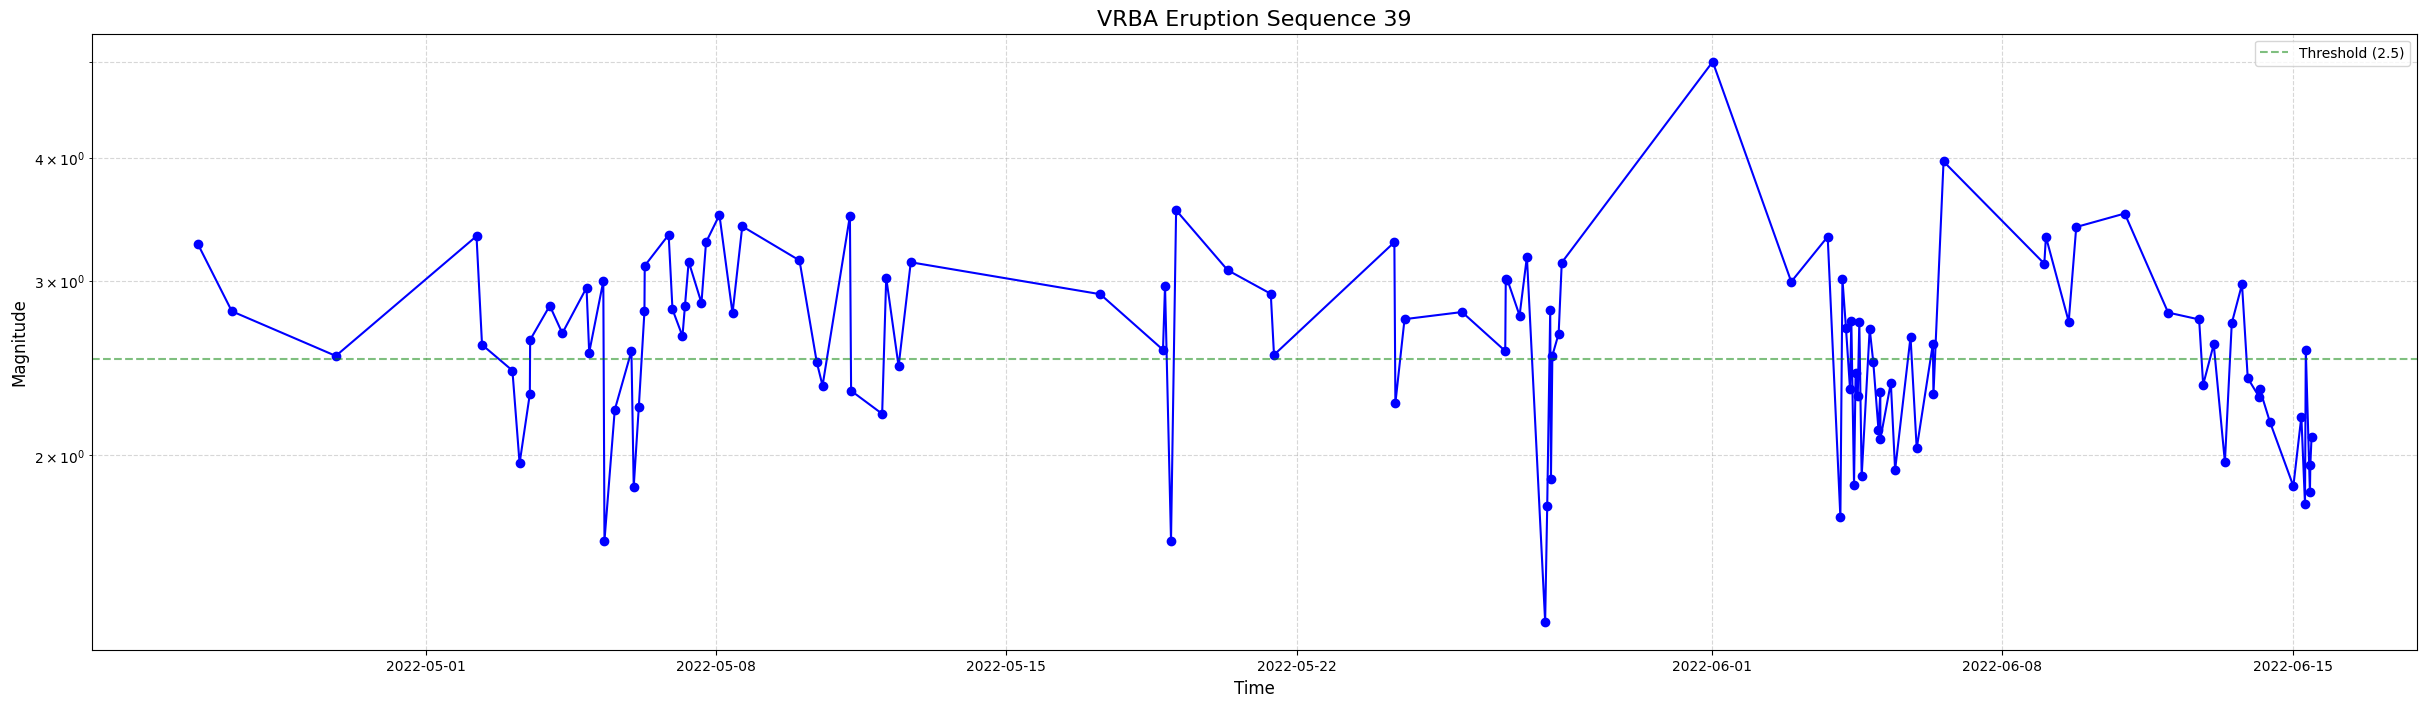


--- Scanning Sequence 54 ---
Low mag seq: 2023-07-20 to 2023-07-20 | Gap Duration: 5 days 09:58:57.158000 | Dropped: 1
Low mag seq: 2023-07-22 to 2023-07-29 | Gap Duration: 7 days 17:34:29.568000 | Dropped: 6


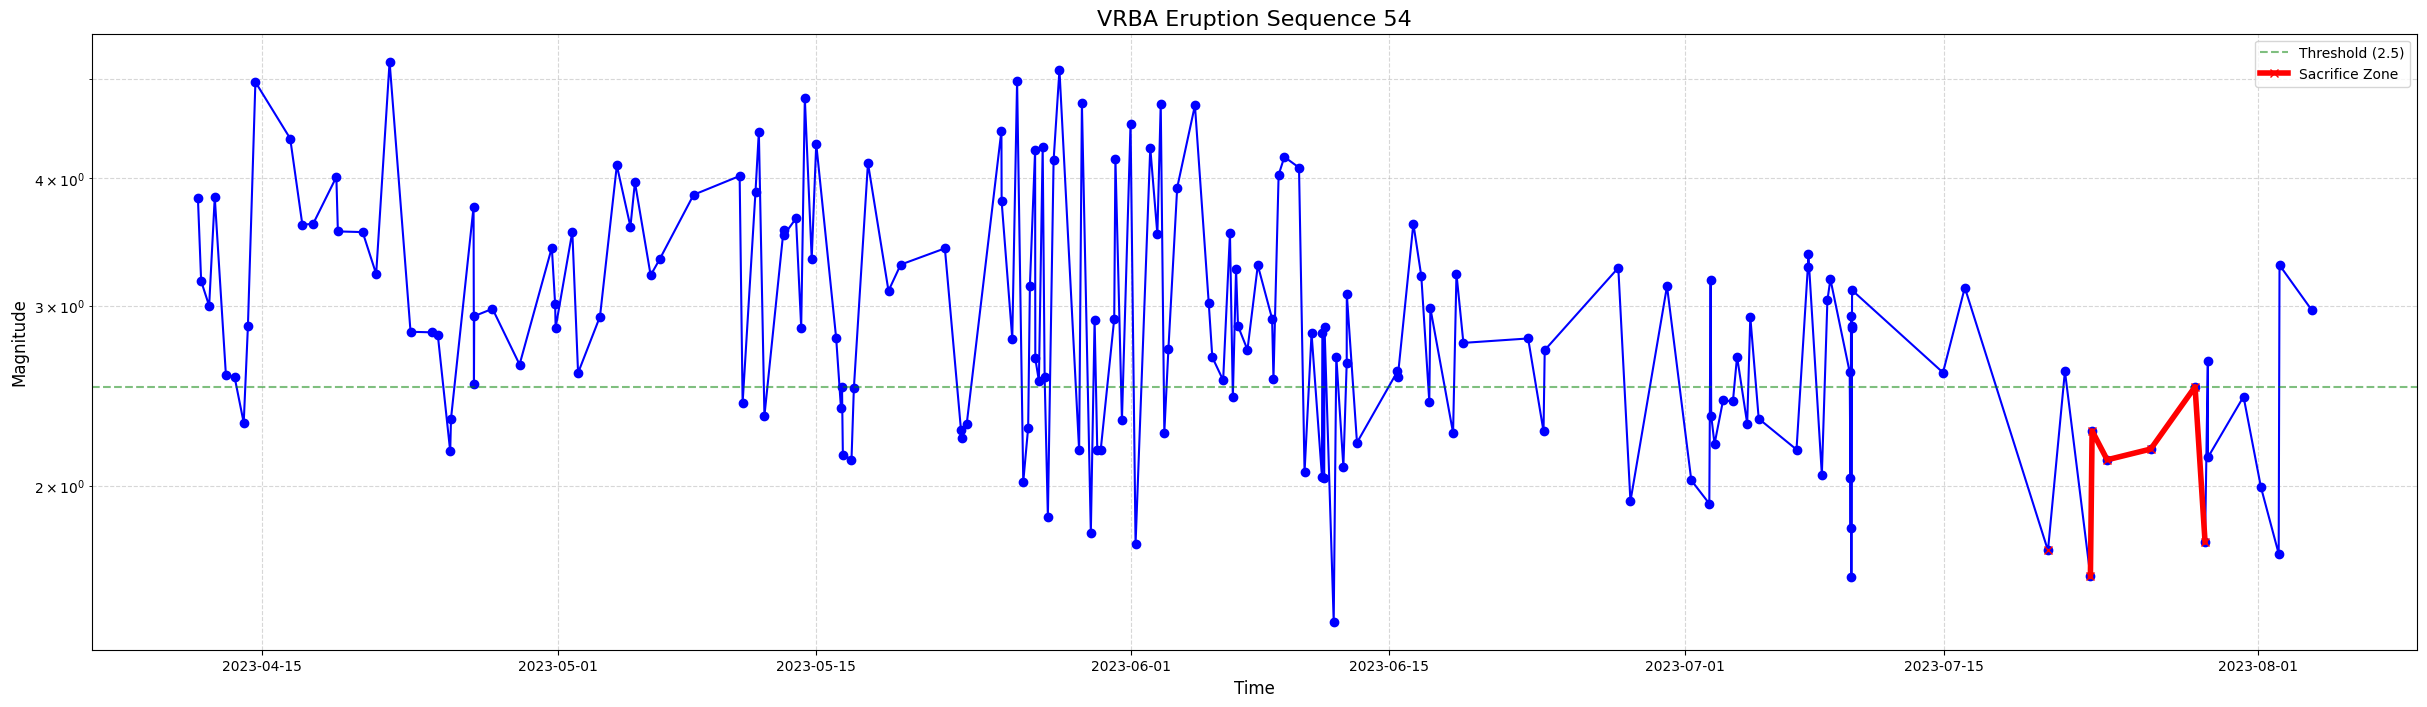


--- Scanning Sequence 55 ---
Low mag seq: 2023-08-10 to 2023-08-13 | Gap Duration: 6 days 07:05:48.924000 | Dropped: 2
Low mag seq: 2023-10-07 to 2023-10-26 | Gap Duration: 19 days 07:26:08.895000 | Dropped: 21
Low mag seq: 2023-10-29 to 2023-10-31 | Gap Duration: 5 days 15:12:51.460000 | Dropped: 3


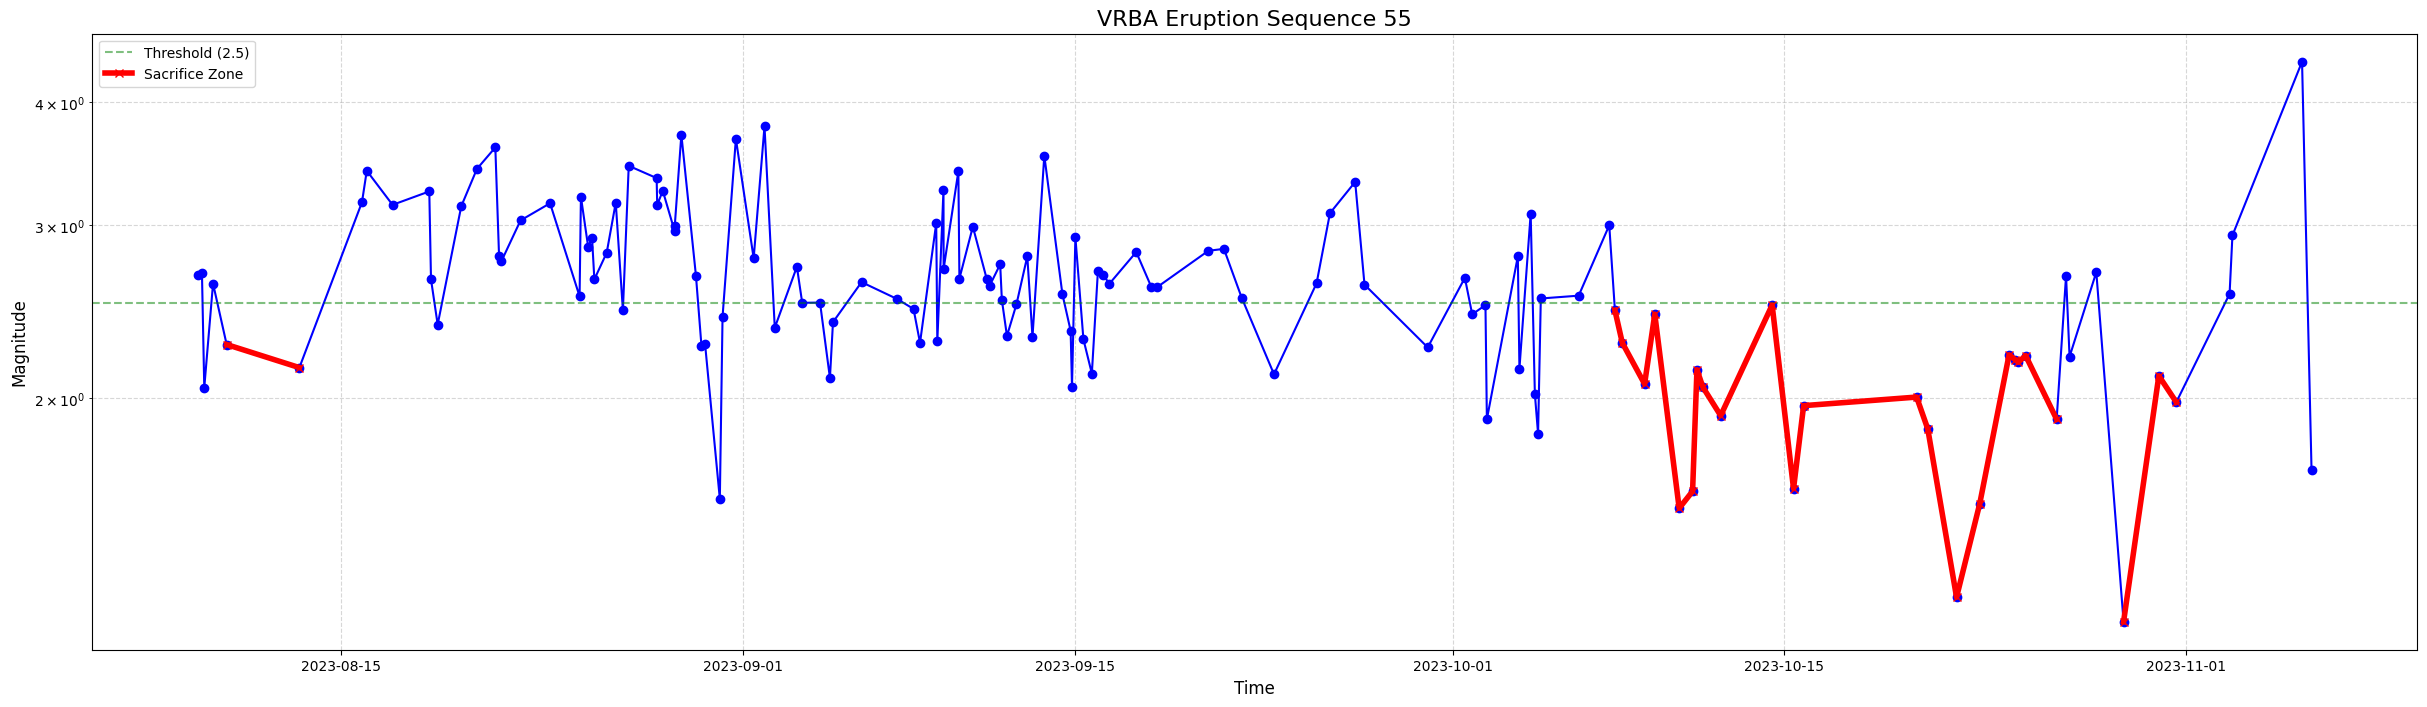

In [48]:
# Plot possible sacrifice zones of low magnitude eruptions in the 3 longest chains (with a threshold of 2.5) to see if they could be used as firewalls
plt.style.use('default')
THRESHOLD = 2.5 
WINDOW_SIZE = pd.Timedelta(days=5)
for k in [38, 53, 54]: 
    chain = eruption_chains[k]
    plt.figure(figsize=(30, 8)) 
    
    print(f"\n--- Scanning Sequence {k+1} ---")
    erup_time, erup_magnitude, low_magnitude_sequences, low_magnitude_sequences_times = find_days_of_low_magnitude_eruptions(
        chain, 
        VRBA_eruptions_df, 
        magnitude_threshold=THRESHOLD,
        window_size=WINDOW_SIZE
    )
    
    plt.plot(erup_time, erup_magnitude, marker='o', linestyle='-', color='blue')
    
    # On trace une ligne horizontale pour montrer le seuil
    plt.axhline(y=THRESHOLD, color='green', linestyle='--', alpha=0.5, label=f'Threshold ({THRESHOLD})')
    
    plt.title(f"VRBA Eruption Sequence {k+1}", fontsize=16)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Magnitude', fontsize=12)
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    for low_seq, low_seq_times in zip(low_magnitude_sequences, low_magnitude_sequences_times):
        plt.plot(low_seq_times, VRBA_eruptions_df.loc[low_seq, 'magnitude'], color='red', linewidth=4, marker='x', label='Sacrifice Zone' if low_seq == low_magnitude_sequences[0] else "")

    plt.legend()
    plt.show()

In [49]:
def apply_purged_grouping(df, window_size, time_col='t1', cut_dates=['2022-05-22', '2023-05-15', '2023-06-25', '2023-09-01', '2023-10-15']):
    """
    Forces hard cuts in time-series data to break up massive sequences.
    Drops data within the purge window and re-calculates isolated sequence IDs.
    """
    # Work on a copy to keep original data safe
    df_clean = df.copy()

    # Deleted Eruptions
    deleted_eruptions = []

    # Identify rows to drop (The Purge Zone)
    rows_to_drop = pd.Series(False, index=df_clean.index)
    
    for date_str in cut_dates:
        start_purge = pd.to_datetime(date_str)
        end_purge = start_purge + window_size
        
        # Find eruptions that fall exactly inside our dead zone
        in_purge_zone = (df_clean[time_col] >= start_purge) & (df_clean[time_col] <= end_purge)
        rows_to_drop = rows_to_drop | in_purge_zone
        deleted_eruptions.extend(df_clean[in_purge_zone].index.tolist())
        
    # Execute the Purge (Drop the rows)
    df_clean = df_clean[~rows_to_drop].copy()
    
    # Automatically generate the new Safe_Group_IDs
    # Any gap > purge_window_days automatically starts a new group.
    # Since we just forced artificial 5-day gaps, this clusters everything perfectly!
    time_diffs = df_clean[time_col].diff()
    
    # The first row is always the start of Group 0. Every gap > 5 days adds +1 to the ID.
    new_sequence_starts = time_diffs > window_size
    df_clean['Erup_Group_ID'] = new_sequence_starts.cumsum()
    
    # print("\n--- Summary ---")
    # print(f"Original eruptions: {len(df)}")
    # print(f"Eruptions safely kept: {len(df_clean)}")
    # print(f"Total isolated groups created: {df_clean['Erup_Group_ID'].nunique()} (No overlapping data!)")
    
    return df_clean, deleted_eruptions

# cuts = [
#     '2022-05-22', # Splitting Sequence 39
#     '2023-05-15', # Splitting Sequence 54 (Cut 1)
#     '2023-06-25', # Splitting Sequence 54 (Cut 2)
#     '2023-09-01', # Splitting Sequence 55 (Cut 1)
#     '2023-10-15', # Splitting Sequence 55 (Cut 2)
# ]

# # Run the function
# safe_eruptions_df, deleted_eruptions = apply_purged_grouping(
#     df=VRBA_eruptions_df, 
#     time_col='t1', 
#     cut_dates=cuts, 
#     window_size=WINDOW_SIZE2
# )
# print(f"\nDeleted Eruptions Indices: {deleted_eruptions}")
# print(f"Deleted Eruptions Count: {len(deleted_eruptions)}")

In [50]:
## Store the eruption chains and their heads with some stats printed
eruption_chains, head_chains = find_eruption_chains(safe_eruptions_df, WINDOW_SIZE)
# Store the head of each chain


print(f"Found {len(eruption_chains)} distinct eruption sequences.")
for y, chain in enumerate(eruption_chains):
        print(f"Sequence {y+1}: ({len(chain)}) eruptions {chain}")

print("\n")

# Calculate the time differences between each chains
chain_time_differences = []
chain_gaps = []
for i, chain in enumerate(eruption_chains):
    first_erup_id = chain[0]
    last_erup_id = chain[-1]
    first_time = VRBA_eruptions_df.loc[first_erup_id, 't1']
    last_time = VRBA_eruptions_df.loc[last_erup_id, 't1']
    time_diff = last_time - first_time
    if i+1 < len(eruption_chains):
        next_chain = eruption_chains[i+1]
        next_first_erup_id = next_chain[0]
        next_first_time = VRBA_eruptions_df.loc[next_first_erup_id, 't1']
        gap = next_first_time - last_time
        chain_gaps.append(gap)

        chain_time_differences.append(time_diff)
        print(f"Sequence {i+1} duration: {time_diff} ")

print("\n")
print("Gaps between sequence:")
for i, gap in enumerate(chain_gaps):
    print(f"Gap after sequence {i+1}: {gap}")

NameError: name 'safe_eruptions_df' is not defined

In [ ]:
# # Plot the chains in different colors over time with y being the energy of the eruptions and point out the lahar eruptions
# plt.style.use("default")
# plt.figure(figsize=(30, 40))
# for i, chain in enumerate(eruption_chains):
#     plt.subplot(len(eruption_chains), 1, i+1)
#     times = [VRBA_eruptions_df.loc[erup_id, 't1'] for erup_id in chain]
#     energies = [VRBA_eruptions_df.loc[erup_id, 'energy_scaled'] for erup_id in chain]
#     plt.plot(times, energies, marker='o', label=f'Sequence {i+1}')
#     # Highlight lahar eruptions in the chain
#     for window_id in chain:
#         if VRBA_eruptions_df.loc[window_id, 'Lahares']:
#             plt.plot(VRBA_eruptions_df.loc[window_id, 't1'], VRBA_eruptions_df.loc[window_id, 'energy_scaled'], marker='o', color='red', markersize=10)
#             plt.title(f'Sequence {i+1} (Lahares in Red)')
#     plt.xlabel('Time')
#     plt.ylabel('Eruption Energy')
#     plt.legend()

# plt.show()


In [ ]:
# Eruptions that had lahar events
lahar_eruptions = VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True].index.tolist()
print(f"Eruptions with Lahares: {lahar_eruptions}")

Eruptions with Lahares: [0, 37, 94, 208, 240, 245, 326, 494, 536, 544, 576, 595, 606, 608, 838]


In [ ]:
for y, chain in enumerate(eruption_chains):
    for lahar in lahar_eruptions:
        if lahar in chain:
            print(f"Sequence {y+1} contains lahar eruption ID: {lahar}")
            idx = chain.index(lahar)
            if idx > 0:
                print(f"  Previous eruptions in sequence: {len(chain[:idx])}")
            else:
                print("  This lahar eruption is the first in the sequence")
            

Sequence 1 contains lahar eruption ID: 0
  This lahar eruption is the first in the sequence
Sequence 11 contains lahar eruption ID: 37
  Previous eruptions in sequence: 1
Sequence 15 contains lahar eruption ID: 94
  Previous eruptions in sequence: 49
Sequence 26 contains lahar eruption ID: 208
  This lahar eruption is the first in the sequence
Sequence 36 contains lahar eruption ID: 240
  Previous eruptions in sequence: 6
Sequence 36 contains lahar eruption ID: 245
  Previous eruptions in sequence: 11
Sequence 39 contains lahar eruption ID: 326
  Previous eruptions in sequence: 64
Sequence 51 contains lahar eruption ID: 494
  This lahar eruption is the first in the sequence
Sequence 54 contains lahar eruption ID: 536
  Previous eruptions in sequence: 8
Sequence 54 contains lahar eruption ID: 544
  Previous eruptions in sequence: 16
Sequence 54 contains lahar eruption ID: 576
  Previous eruptions in sequence: 48
Sequence 54 contains lahar eruption ID: 595
  Previous eruptions in sequenc

    We see that two Lahares are starting the sequence of eruptions. Those eruptions will particularly interesting when comparing with the others eruptions starting sequences.

In [ ]:
## Accumulation of potential ash because of following eruptions
def calculate_ash_potential(df, decay_rate=0.98):
    """
    Calculate ash accumulation potential over time.
    decay_rate: fraction of ash remaining from previous day (0.98 = 98% retention)
    """
    df = df.sort_values('t1')
    
    ash_potential = []
    current_ash = 0
    last_time = df.iloc[0]['t1']
    
    for index, row in df.iterrows():
        current_time = row['t1']
        
        days_passed = (current_time - last_time)
        
        if days_passed > pd.Timedelta(0):
            days_passed = days_passed.total_seconds() / (24 * 3600)
            current_ash = current_ash * (decay_rate ** days_passed)
        
        ash_potential.append(current_ash)
        
        current_ash += 1 
        
        last_time = current_time
        
    df['ash_history_score'] = ash_potential
    return df


In [ ]:
# # Plot per years
# years = reduce_VRBA_df['t1'].dt.year.unique()
# for year in years:
#     yearly_df = reduce_VRBA_df[reduce_VRBA_df['t1'].dt.year == year]
#     plt.figure(figsize=(15, 6))
#     plt.plot(yearly_df['t1'], yearly_df['ash_history_score'], label='Ash History Score', color='blue')
#     # Overlay red points where Lahares == True
#     lahar_df = yearly_df[yearly_df["Lahares"] == True]
#     plt.scatter(
#         lahar_df['t1'],
#         lahar_df['ash_history_score'],
#         color='red',
#         label='Potential Lahar'
#     )
#     mask = (Rain2019_2024_df.index.year == year)
    
#     # Apply the mask using position
#     times = Rain2019_2024_df.loc[mask].index
#     smoothed_precipitations_year = smoothed_precipitations[mask]
    
#     precipitations_year = precipitations[mask]

#     plt.plot(times, smoothed_precipitations_year, label='Smoothed Precipitations', color='green')
#     plt.plot(times, precipitations_year, label='Precipitations', color='cyan', alpha=0.5)

#     plt.title(f'VRBA Eruptions - Ash History Score over Time in {year} (Lahares in Red)')
#     plt.xlabel('Time')
#     plt.ylabel('Ash History Score')
#     plt.legend()
#     plt.show()

#### Seismic Data 

##### Eruption Windows 

Lets analyze the Rsam values from Rincon de la Vieja just before the eruptions in VRBA. We want to prevent populutation of an eruption at least 7 minutes before it happens. We will thus take an averge value and standard deviation of Rsam values from Rincon de la Vieja in the time window of 7 to 60 minutes before each eruption in VRBA. (POSSIBLE DE REDUIRE LINTERVALLE POUR PLUS DE PRECISION)

It has been established that signals of eruptions could append till 5 days  before the actual eruption. We will thus analyze the Rsam values from Rincon de la Vieja in the time window of 5 days to 7 minutes before each eruption in VRBA. We make sure to take care of the gaps in the countinuous data in order to avoid bias in the calculations. 

In [51]:
WINDOW_SIZE = pd.Timedelta(days=5) # pd.Timedelta(days=3)

In [52]:
def get_eruptions_windows_data(continuous_df, reference_df, window_size, maximum_observation_time_before_eruption,time_type = 'min'):
    
    # Security check
    increasing_index = continuous_df.index.is_monotonic_increasing
    datetime_index = isinstance(continuous_df.index, pd.DatetimeIndex)
    if not datetime_index :
        raise ValueError("The continuous DataFrame index must be a DatetimeIndex.")
    if not increasing_index:
        #print("Sorting continuous DataFrame by index...")
        continuous_df = continuous_df.sort_index()
     
    # Dictionaries to store results
    eruptions_windows_indices = {}

    max_obs_bfr_eruption = maximum_observation_time_before_eruption
    
    for index, row in reference_df.items():
        
        eruption_time = row.floor(time_type)

        start_time = eruption_time - window_size
        end_time = eruption_time - max_obs_bfr_eruption

        # Create a mask for the time window
        mask = (continuous_df.index >= start_time) & (continuous_df.index <= end_time)
        window_data = continuous_df.loc[mask]

        # Store indices 
        eruptions_windows_indices[index] = window_data.index.tolist()

    # Return both dictionaries
    return eruptions_windows_indices

In [53]:
maximum_observation_time_before_eruption = pd.Timedelta(minutes=7)
maximum_observation_time_before_eruption2 = pd.Timedelta(days=1)

In [54]:
def build_or_load_eruptions_windows_indices(
    datasets,
    eruption_times,
    window_size,
    output_dir='MSc_Bryan_Rincon/Eruptions indices',
    mode='load',
    max_obs_minutes=7,
    max_obs_days=1,
):
    """
    Automated extraction, computation, and loading of eruption windows for multiple datasets.
    
    Parameters:
    -----------
    datasets : dict
        Configuration dictionary mapping dataset names to their config.
        Example:
        {
            'eruptions_windows_indices_VRBA': {
                'df': Rincon_de_la_Vieja_df,
                'file_name': 'eruptions_windows_indices_VRBA.npy',
                'time_type': None,  # optional
            },
            'sei_geo_eruptions_windows_indices': {
                'df': Rincon_df,
                'file_name': 'sei_geo_eruptions_windows_indices.npy',
                'time_type': 'D',  # optional, for daily granularity
            }
        }
    
    eruption_times : pd.Series
        Series containing eruption time points (e.g., VRBA_eruptions_df['t1'])
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    output_dir : str, default 'MSc_Bryan_Rincon/Eruptions indices'
        Directory where numpy files are saved/loaded
    
    mode : str, default 'load'
        - 'load': Load pre-computed data from numpy files (fastest)
        - 'save': Compute and save to numpy files
        - 'compute': Compute without saving
    
    max_obs_minutes : int, default 7
        Minutes before eruption for standard observation window
    
    max_obs_days : int, default 1
        Days before eruption for daily-granularity datasets
    
    Returns:
    --------
    dict : Dictionary mapping dataset names to their eruptions_windows_indices
    
    Example Usage:
    --------------
    # First time: compute and save all datasets
    all_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_WINDOWS_CONFIG,
        eruption_times=VRBA_eruptions_df['t1'],
        window_size=WINDOW_SIZE,
        mode='save'
    )
    
    # Subsequent runs: load from disk (fast)
    all_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_WINDOWS_CONFIG,
        eruption_times=VRBA_eruptions_df['t1'],
        window_size=WINDOW_SIZE,
        mode='load'
    )
    
    # Extract individual results
    vrba_data = all_windows['eruptions_windows_indices_VRBA']
    rsam_data = all_windows['eruptions_windows_indices_rsam_VORI']
    dsar_data = all_windows['eruptions_windows_indices_dsar_VORI']
    sei_data = all_windows['sei_geo_eruptions_windows_indices']
    """
    
    results = {}
    max_obs_minutes_td = pd.Timedelta(minutes=max_obs_minutes)
    max_obs_days_td = pd.Timedelta(days=max_obs_days)

    for result_name, cfg in datasets.items():
        file_path = f"{output_dir}/{cfg['file_name']}"

        # Load mode: retrieve pre-computed data from disk
        if mode == 'load':
            results[result_name] = np.load(file_path, allow_pickle=True).item()
            continue

        # Compute or Save mode: determine which observation window to use
        time_type = cfg.get('time_type', None)
        max_obs = max_obs_days_td if time_type == 'D' else max_obs_minutes_td

        # Build kwargs for get_eruptions_windows_data
        kwargs = {
            'maximum_observation_time_before_eruption': max_obs,
        }
        if time_type == 'D':
            kwargs['time_type'] = 'D'

        # Call the extraction function
        windows = get_eruptions_windows_data(
            cfg['df'],
            eruption_times,
            window_size,
            **kwargs,
        )
        results[result_name] = windows

        # Save mode: persist to disk
        if mode == 'save':
            np.save(file_path, windows)
    return results

In [55]:
ERUPTION_WINDOWS_CONFIG = {
    'eruptions_windows_indices_VRBA': {
        'df': Rincon_de_la_Vieja_df,
        'file_name': 'eruptions_windows_indices_VRBA.npy',
    },
    'eruptions_windows_indices_rsam_VORI': {
        'df': rsam_VORI_df,
        'file_name': 'eruptions_windows_indices_rsam_VORI.npy',
    },
    'eruptions_windows_indices_dsar_VORI': {
        'df': dsar_VORI_df,
        'file_name': 'eruptions_windows_indices_dsar_VORI.npy',
    },
    'sei_geo_eruptions_windows_indices': {
        'df': Rincon_df,
        'file_name': 'sei_geo_eruptions_windows_indices.npy',
        'time_type': 'D',  # Use 1-day observation window
    },
}

In [56]:
all_eruptions_windows = build_or_load_eruptions_windows_indices(
    datasets=ERUPTION_WINDOWS_CONFIG,
    eruption_times=VRBA_eruptions_df['t1'],
    window_size=WINDOW_SIZE,
    mode='load',  # Computes and saves all 4 datasets
)
# all_eruptions_windows = build_or_load_eruptions_windows_indices(
#     datasets=ERUPTION_WINDOWS_CONFIG,
#     eruption_times=VRBA_eruptions_df['t1'],
#     window_size=WINDOW_SIZE,
#     mode='load',  # Just loads from numpy files
# )

eruptions_windows_indices_VRBA = all_eruptions_windows['eruptions_windows_indices_VRBA']
eruptions_windows_indices_rsam_VORI = all_eruptions_windows['eruptions_windows_indices_rsam_VORI']
eruptions_windows_indices_dsar_VORI = all_eruptions_windows['eruptions_windows_indices_dsar_VORI']
sei_geo_eruptions_windows_indices = all_eruptions_windows['sei_geo_eruptions_windows_indices']

In [57]:
eruptions_windows_indices_VRBA = all_eruptions_windows['eruptions_windows_indices_VRBA']
eruptions_windows_indices_rsam_VORI = all_eruptions_windows['eruptions_windows_indices_rsam_VORI']
eruptions_windows_indices_dsar_VORI = all_eruptions_windows['eruptions_windows_indices_dsar_VORI']
sei_geo_eruptions_windows_indices = all_eruptions_windows['sei_geo_eruptions_windows_indices']

In [ ]:
## Store the eruptions windows data in numpy files for different continuous datasets
# maximum_observation_time_before_eruption = pd.Timedelta(minutes=7)
# eruptions_windows_indices_VRBA = get_eruptions_windows_data(Rincon_de_la_Vieja_df, VRBA_eruptions_df['t1'], WINDOW_SIZE, maximum_observation_time_before_eruption= maximum_observation_time_before_eruption)
# eruptions_windows_indices_rsam_VORI = get_eruptions_windows_data(rsam_VORI_df, VRBA_eruptions_df['t1'], WINDOW_SIZE, maximum_observation_time_before_eruption= maximum_observation_time_before_eruption)
# eruptions_windows_indices_dsar_VORI = get_eruptions_windows_data(dsar_VORI_df, VRBA_eruptions_df['t1'], WINDOW_SIZE, maximum_observation_time_before_eruption= maximum_observation_time_before_eruption)
# maximum_observation_time_before_eruption2 = pd.Timedelta(days=1)
# sei_geo_eruptions_windows_indices = get_eruptions_windows_data(Rincon_df, VRBA_eruptions_df['t1'], WINDOW_SIZE, maximum_observation_time_before_eruption=maximum_observation_time_before_eruption2, time_type='D')

# # Save to numpy files
# np.save('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices_VRBA.npy', eruptions_windows_indices_VRBA)
# np.save('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices_rsam_VORI.npy', eruptions_windows_indices_rsam_VORI)
# np.save('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices_dsar_VORI.npy', eruptions_windows_indices_dsar_VORI)
# np.save('MSc_Bryan_Rincon/Eruptions indices/sei_geo_eruptions_windows_indices.npy', sei_geo_eruptions_windows_indices)

# maximum_observation_time_before_eruption = pd.Timedelta(minutes=7)
# maximum_observation_time_before_eruption2 = pd.Timedelta(days=1)

# eruptions_windows_indices_VRBA = np.load('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices_VRBA.npy', allow_pickle=True).item()
# eruptions_windows_indices_rsam_VORI = np.load('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices_rsam_VORI.npy', allow_pickle=True).item()
# eruptions_windows_indices_dsar_VORI = np.load('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices_dsar_VORI.npy', allow_pickle=True).item()
# sei_geo_eruptions_windows_indices = np.load('MSc_Bryan_Rincon/Eruptions indices/sei_geo_eruptions_windows_indices.npy', allow_pickle=True).item()

In [58]:
# Get an overview of the data present in each eruption window for the VRBA station
max_data_points =  (WINDOW_SIZE - maximum_observation_time_before_eruption) / pd.Timedelta(minutes=1)  # in minutes
for y in range(0, len(eruptions_windows_indices_VRBA)):
    print(f"Eruption {y} window indices: {len(eruptions_windows_indices_VRBA[y])} percentage data present: {len(eruptions_windows_indices_VRBA[y]) / max_data_points * 100:.2f}% ")
    if len(eruptions_windows_indices_VRBA[y]) / max_data_points * 100 == 0:
        print(f"eruption {y} has no data in the window")

Eruption 0 window indices: 6614 percentage data present: 91.95% 
Eruption 1 window indices: 7070 percentage data present: 98.29% 
Eruption 2 window indices: 7143 percentage data present: 99.30% 
Eruption 3 window indices: 6586 percentage data present: 91.56% 
Eruption 4 window indices: 6582 percentage data present: 91.51% 
Eruption 5 window indices: 6458 percentage data present: 89.78% 
Eruption 6 window indices: 6351 percentage data present: 88.29% 
Eruption 7 window indices: 6162 percentage data present: 85.67% 
Eruption 8 window indices: 1370 percentage data present: 19.05% 
Eruption 9 window indices: 1702 percentage data present: 23.66% 
Eruption 10 window indices: 4435 percentage data present: 61.66% 
Eruption 11 window indices: 4909 percentage data present: 68.25% 
Eruption 12 window indices: 5186 percentage data present: 72.10% 
Eruption 13 window indices: 5188 percentage data present: 72.13% 
Eruption 14 window indices: 2723 percentage data present: 37.86% 
Eruption 15 window i

In [59]:
# Get an overview of the data present in each eruption window for the VORI station
for y in range(0, len(eruptions_windows_indices_rsam_VORI)):
    print(f"Eruption {y} window indices RSAM VORI: {len(eruptions_windows_indices_rsam_VORI[y])} percentage data present: {len(eruptions_windows_indices_rsam_VORI[y]) / max_data_points * 100:.2f}% ")
    print(f"----------------------------DSAR VORI: {len(eruptions_windows_indices_dsar_VORI[y])} percentage data present: {len(eruptions_windows_indices_dsar_VORI[y]) / max_data_points * 100:.2f}% ")
    if len(eruptions_windows_indices_rsam_VORI[y]) / max_data_points * 100 == 0:
        print(f"eruption {y} has no RSAM VORI data in the window")
    if len(eruptions_windows_indices_dsar_VORI[y]) / max_data_points * 100 == 0:
        print(f"eruption {y} has no DSAR VORI data in the window")

Eruption 0 window indices RSAM VORI: 5750 percentage data present: 79.94% 
----------------------------DSAR VORI: 5750 percentage data present: 79.94% 
Eruption 1 window indices RSAM VORI: 7189 percentage data present: 99.94% 
----------------------------DSAR VORI: 7189 percentage data present: 99.94% 
Eruption 2 window indices RSAM VORI: 7189 percentage data present: 99.94% 
----------------------------DSAR VORI: 7189 percentage data present: 99.94% 
Eruption 3 window indices RSAM VORI: 7189 percentage data present: 99.94% 
----------------------------DSAR VORI: 7189 percentage data present: 99.94% 
Eruption 4 window indices RSAM VORI: 7189 percentage data present: 99.94% 
----------------------------DSAR VORI: 7189 percentage data present: 99.94% 
Eruption 5 window indices RSAM VORI: 7189 percentage data present: 99.94% 
----------------------------DSAR VORI: 7189 percentage data present: 99.94% 
Eruption 6 window indices RSAM VORI: 7189 percentage data present: 99.94% 
-------------

 We can see that a lot of eruptions are poorly covered during the 5 days preceding the eruption for the VRBA station. The eruptions that are less covered will be less reliable for the analysis. However for the VORI station there seems to be better coverage of the eruptions during the 5 days preceding the eruption.

##### No Eruption Windows

We need to evaluate also window where nothing is happening to have a better idea of the difference between eruption and non-eruption windows. We will thus create random windows of 5 days duration in the Rincon de la Vieja continuous dataframe where no eruption is happening in VRBA. We will then apply the same feature extraction process on those windows.

In [81]:
len(VRBA_eruptions_df)

971

In [60]:
# Exclude data points that are too close to eruptions
def get_surrounding_eruption_indices(continuous_df, eruption_df, neighbour_limit):

    surrounding_indices = {}
    
    for index, row in eruption_df.iterrows():
        eruption_time = row['t1'] 
     
        start_exclusion = eruption_time - neighbour_limit[0]
        end_exclusion = eruption_time + neighbour_limit[1]
        
        mask = (continuous_df.index >= start_exclusion) & (continuous_df.index <= end_exclusion)
        indices_to_exclude = continuous_df.index[mask].tolist()
        
        if indices_to_exclude:
            surrounding_indices[index] = indices_to_exclude
            
    return surrounding_indices

In [61]:
# List all data points left unused after excluding eruption windows
def get_unused_data_indices(df, eruptions_windows_indices):
    # Collect all indices currently used in eruption windows
    all_used_indices = set()
    for indices in eruptions_windows_indices.values():
        all_used_indices.update(indices)
    
    # Get all available indices from the DataFrame
    all_data_indices = set(df.index.tolist())
    
    # Find the difference (available - used) and sort them
    unused_indices = sorted(list(all_data_indices - all_used_indices))
    
    #print(f"Number of unused data points: {len(unused_indices)}")
    
    return unused_indices

In [62]:
# Group close non eruptions points together

def create_group_non_eruption_points(unused_indices, window_duration):

    if len(unused_indices) == 0:
        print("No unused data points to group.")
        return []

    sorted_indices = sorted(unused_indices)

    groups = []
    current_group = [sorted_indices[0]]


    for i in range(1, len(sorted_indices)):
        time_diff = sorted_indices[i] - sorted_indices[i-1]

        if time_diff > window_duration:
            groups.append(current_group)
            current_group = [sorted_indices[i]]
        else:
            current_group.append(sorted_indices[i])

    if current_group:
        groups.append(current_group)

    return groups

In [63]:
## Create Window of maximum WINDOW SIZE days of no-eruption data
def create_no_eruption_windows(groups, window_duration, offset, maximum_observation_time_before_eruption, max_chain_length=36, return_chains=False):

    no_eruptions_windows_indices = {}
    virtual_no_eruption_times = []
    
    # id for each window
    window_id = 0 

    # Security gap before virtual no-eruption time
    max_obs_bfr_eruption = maximum_observation_time_before_eruption

    # Store the chains of no-eruption windows for each group
    no_eruption_chains = []
    

    for group_id, group in enumerate(groups):
        # Skip empty groups
        if not group:
            continue 

        start_time = group[0]
        max_time = group[-1]

        current_start = start_time

        # window in the same group
        if current_start + window_duration > max_time:
            continue
        chain = []

        while current_start + window_duration <= max_time:
            # Virtual no-eruption 
            virtual_no_eruption_time = current_start + window_duration
        
            # Security end time
            security_end_time = virtual_no_eruption_time - max_obs_bfr_eruption
            
            # Get indices within the current window
            window_indices = [t for t in group if current_start <= t <= security_end_time]

            number_of_points = len(window_indices)

            # Skip empty windows
            if number_of_points == 0:
                current_start += offset
                continue

            # Store in dictionary with its window id
            no_eruptions_windows_indices[window_id] = window_indices

            # Store the virtual no-eruption time
            virtual_no_eruption_times.append(virtual_no_eruption_time)

            # Increment for next window
            chain.append(window_id)
            window_id += 1

            if len(chain) >= max_chain_length and  offset < window_duration:

                no_eruption_chains.append(chain)
                chain = []
                current_start += window_duration
            else :
                current_start += offset
        if chain:  # Check if there's an unfinished chain at the end of the group
            no_eruption_chains.append(chain)

    return no_eruptions_windows_indices, np.array(virtual_no_eruption_times), no_eruption_chains
  


In [64]:
NEIGHBOUR_LIMIT = [pd.Timedelta(days=5), pd.Timedelta(days=4)]

# VRBA will be the only one kept because it has the less complete data
# Get indices to exclude around eruptions 
nearby_eruption_indices_VRBA = get_surrounding_eruption_indices(Rincon_de_la_Vieja_df, VRBA_eruptions_df, NEIGHBOUR_LIMIT)

# Get unused data indices after exclusion
unused_indices_VRBA = get_unused_data_indices(Rincon_de_la_Vieja_df, nearby_eruption_indices_VRBA)



non_eruption_groups = create_group_non_eruption_points(unused_indices_VRBA, WINDOW_SIZE2)
print(f"Number of non-eruption data point groups: {len(non_eruption_groups)}")


Number of non-eruption data point groups: 45


In [65]:
# # # No eruption windows creation
# Create no-eruption windows for the VRBA station
continuous_OFFSET = pd.Timedelta(days=0.4)
no_eruption_windows_indices_VRBA, virtual_no_eruption_times2, no_eruption_chains = create_no_eruption_windows(non_eruption_groups, WINDOW_SIZE, continuous_OFFSET, maximum_observation_time_before_eruption=maximum_observation_time_before_eruption, return_chains=True)
print(f"Number of no-eruption windows created: {len(no_eruption_windows_indices_VRBA)}")
for i, chain in enumerate(no_eruption_chains):
    print(f"Chain n°{i} of length ({len(chain)}): {chain}")
# print(f"Number of no-eruption windows created: {len(no_eruption_windows_indices_VRBA)}")
# # Get the data points present in each no-eruption window for the VORI station
# no_eruption_windows_indices_rsam_VORI = get_eruptions_windows_data(rsam_VORI_df, pd.Series(virtual_no_eruption_times2), WINDOW_SIZE, maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# no_eruption_windows_indices_dsar_VORI = get_eruptions_windows_data(dsar_VORI_df, pd.Series(virtual_no_eruption_times2), WINDOW_SIZE, maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)

# # # # Save to numpy files
# np.save('MSc_Bryan_Rincon/Eruptions indices/no_eruption_windows_indices_VRBA.npy', no_eruption_windows_indices_VRBA)
# np.save('MSc_Bryan_Rincon/Eruptions indices/no_eruption_windows_indices_rsam_VORI.npy', no_eruption_windows_indices_rsam_VORI)
# np.save('MSc_Bryan_Rincon/Eruptions indices/no_eruption_windows_indices_dsar_VORI.npy', no_eruption_windows_indices_dsar_VORI)
# # np.save('MSc_Bryan_Rincon/Eruptions indices/virtual_no_eruption_times.npy', virtual_no_eruption_times)

# no_eruption_windows_indices_VRBA = np.load('MSc_Bryan_Rincon/Eruptions indices/no_eruption_windows_indices_VRBA.npy', allow_pickle=True).item()
# no_eruption_windows_indices_rsam_VORI = np.load('MSc_Bryan_Rincon/Eruptions indices/no_eruption_windows_indices_rsam_VORI.npy', allow_pickle=True).item()
# no_eruption_windows_indices_dsar_VORI = np.load('MSc_Bryan_Rincon/Eruptions indices/no_eruption_windows_indices_dsar_VORI.npy', allow_pickle=True).item()
# virtual_no_eruption_times = np.load('MSc_Bryan_Rincon/Eruptions indices/virtual_no_eruption_times.npy', allow_pickle=True)


Number of no-eruption windows created: 1166
Chain n°0 of length (24): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Chain n°1 of length (36): [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
Chain n°2 of length (36): [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
Chain n°3 of length (1): [96]
Chain n°4 of length (36): [97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]
Chain n°5 of length (36): [133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168]
Chain n°6 of length (36): [169, 170, 171, 172, 173, 174, 175

In [66]:
def chain_stratified_undersampling(no_eruption_chains, no_erup_dict, target_nb):
    """
    Samples no-eruption windows while respecting isolated chains.
    The number of windows drawn from each chain is proportional to its length.
    """
    total_available_windows = sum(len(chain) for chain in no_eruption_chains)
    
    selected_keys = []
    
    if target_nb >= total_available_windows:
        print(f"Not enough total windows available. There are only {total_available_windows} available, keeping all.")
        return selected_keys  # list(no_erup_dict.keys())

    
    # Iterate through each isolated chain
    for chain in no_eruption_chains:
        
        # Calculate the quota: How many windows should this chain provide?
        # (Chain size / Total available) * Target requirement
        proportion = len(chain) / total_available_windows
        quota = int(round(proportion * target_nb))
        
        # If the chain is supposed to provide windows, extract them
        if quota > 0:
            # Safety check: Cannot extract more windows than the chain contains
            quota = min(quota, len(chain))
            
            # Systematic sampling WITHIN the chain (to maximize the gap between windows)
            indices = np.linspace(0, len(chain) - 1, quota, dtype=int)
            for idx in indices:
                selected_keys.append(chain[idx])

    # Final adjustment (due to rounding, we might end up with 398 or 402 instead of 400)
    # If there are slightly too many, randomly remove the excess
    if len(selected_keys) > target_nb:
        selected_keys = random.sample(selected_keys, target_nb)
    # If there are slightly too few, we could compensate (usually negligible)
        
    # Reconstruct the final dictionary
    # balanced_no_eruptions = {k: no_erup_dict[k] for k in selected_keys}
    
    print(f"Extraction complete: {len(selected_keys)} windows extracted from {len(no_eruption_chains)} chains.")
    return selected_keys  #balanced_no_eruptions

In [67]:
no_eruption_windows_indices_VRBA.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [68]:
s = chain_stratified_undersampling(no_eruption_chains, no_eruption_windows_indices_VRBA, target_nb=555)
print(type(s))
print(f"Sampled window IDs: {s}")
print(type(virtual_no_eruption_times2))

Extraction complete: 550 windows extracted from 44 chains.
<class 'list'>
Sampled window IDs: [0, 2, 4, 6, 9, 11, 13, 16, 18, 20, 23, 24, 26, 28, 30, 32, 34, 37, 39, 41, 43, 45, 48, 50, 52, 54, 56, 59, 60, 62, 64, 66, 68, 70, 73, 75, 77, 79, 81, 84, 86, 88, 90, 92, 95, 97, 99, 101, 103, 105, 107, 110, 112, 114, 116, 118, 121, 123, 125, 127, 129, 132, 133, 135, 137, 139, 141, 143, 146, 148, 150, 152, 154, 157, 159, 161, 163, 165, 168, 169, 171, 173, 175, 177, 179, 182, 184, 186, 188, 190, 193, 195, 197, 199, 201, 204, 205, 207, 209, 211, 213, 215, 218, 220, 222, 224, 226, 229, 231, 233, 235, 237, 240, 241, 243, 245, 247, 249, 251, 254, 256, 258, 260, 262, 265, 267, 269, 271, 273, 276, 277, 279, 281, 284, 285, 287, 289, 291, 293, 295, 298, 300, 302, 304, 306, 309, 311, 313, 315, 317, 320, 321, 323, 325, 327, 329, 331, 334, 336, 338, 340, 342, 345, 347, 349, 351, 353, 356, 357, 359, 361, 363, 366, 368, 370, 372, 375, 377, 379, 382, 383, 385, 387, 389, 391, 393, 396, 398, 400, 402, 404, 40

In [69]:

def build_or_load_no_eruption_windows_indices(
    datasets,
    eruptions_df,
    window_size,
    neighbour_limits,
    continuous_offset,
    max_obs_minutes=7,
    output_dir='MSc_Bryan_Rincon/Eruptions indices',
    mode='load',
    time_type= 'min',
):
    """
    Automated extraction, computation, and loading of non-eruption windows for multiple datasets.
    
    Parameters:
    -----------
    datasets : dict
        Configuration dictionary mapping dataset names to their config.
        Must include reference dataset (typically VRBA) for creating non-eruption groups.
        Example:
        {
            'no_eruption_windows_indices_VRBA': {
                'df': Rincon_de_la_Vieja_df,
                'file_name': 'no_eruption_windows_indices_VRBA.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
                'is_reference': True,  # Only one dataset should be True
            },
            'no_eruption_windows_indices_rsam_VORI': {
                'df': rsam_VORI_df,
                'file_name': 'no_eruption_windows_indices_rsam_VORI.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
            },
            'no_eruption_windows_indices_dsar_VORI': {
                'df': dsar_VORI_df,
                'file_name': 'no_eruption_windows_indices_dsar_VORI.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
            }
        }
    
    eruptions_df : pd.DataFrame
        DataFrame containing eruption information (typically VRBA_eruptions_df)
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    neighbour_limits : list of pd.Timedelta
        Time limits to exclude around eruptions [before_limit, after_limit]
        Example: [pd.Timedelta(days=14), pd.Timedelta(days=2)]
    
    continuous_offset : pd.Timedelta
        Offset for creating virtual non-eruption times
        Example: pd.Timedelta(days=4)
    
    max_obs_minutes : int, default 7
        Minutes before non-eruption times for observation window
    
    output_dir : str, default 'MSc_Bryan_Rincon/Eruptions indices'
        Directory where numpy files are saved/loaded
    
    mode : str, default 'load'
        - 'load': Load pre-computed data from numpy files (fastest)
        - 'save': Compute and save to numpy files
        - 'compute': Compute without saving
    
    Returns:
    --------
    dict : Dictionary mapping dataset names to their no_eruption_windows_indices
    dict : Dictionary of virtual non-eruption times used for computation
    """
    
    results = {}
    max_obs_td = pd.Timedelta(minutes=max_obs_minutes)
    virtual_no_eruption_times = None
    no_eruption_chains = None
    reference_unused_indices = None
    
    # Find the reference dataset (is_reference=True)
    reference_name = None
    reference_cfg = None
    for name, cfg in datasets.items():
        if cfg.get('is_reference', False):
            reference_name = name
            reference_cfg = cfg
            break
    
    if reference_name is None:
        raise ValueError("One dataset must have 'is_reference': True")
    
    # Load mode: retrieve pre-computed data from disk
    # if mode == 'load':
    #     for result_name, cfg in datasets.items():
    #         file_path = f"{output_dir}/{cfg['file_name']}"
    #         results[result_name] = np.load(file_path, allow_pickle=True).item()
    if mode == 'load':
        for result_name, cfg in datasets.items():
            file_path = f"{output_dir}/{cfg['file_name']}"
            # Charger depuis pickle au lieu de numpy
            pkl_path = file_path.replace('.npy', '.pkl')
            with open(pkl_path, 'rb') as f:
                results[result_name] = pickle.load(f)
        
        # Also load virtual times
        if reference_cfg.get('virtual_file_name', False):
            virtual_times_path = f"{output_dir}/{reference_cfg['virtual_file_name']}"
            virtual_no_eruption_times = np.load(virtual_times_path, allow_pickle=True)

        # Load no-eruption chains if needed
        if reference_cfg.get('no_eruption_chains_file_name', False):
            chains_path = f"{output_dir}/{reference_cfg['no_eruption_chains_file_name']}"
            with open(chains_path, 'rb') as f:
                no_eruption_chains = pickle.load(f)

        
        return results, virtual_no_eruption_times, no_eruption_chains
    
    # Compute mode: generate from scratch
    # Step 1: Get indices to exclude around eruptions (reference dataset only)
    nearby_eruption_indices = get_surrounding_eruption_indices(
        reference_cfg['df'],
        eruptions_df,
        neighbour_limits
    )
    
    # Step 2: Get unused data indices after exclusion
    reference_unused_indices = get_unused_data_indices(
        reference_cfg['df'],
        nearby_eruption_indices
    )
    
    # Step 3: Create groups of non-eruption points
    non_eruption_groups = create_group_non_eruption_points(
        reference_unused_indices,
        window_size
    )
    #print(f"Number of non-eruption data point groups: {len(non_eruption_groups)}")
    
    # Step 4: Create no-eruption windows for reference dataset
    no_eruption_windows_reference, virtual_no_eruption_times, no_eruption_chains = create_no_eruption_windows(
        non_eruption_groups,
        window_size,
        continuous_offset,
        maximum_observation_time_before_eruption=max_obs_td
    )
    #print(f"Number of no-eruption windows created: {len(no_eruption_windows_reference)}")
    
    results[reference_name] = no_eruption_windows_reference
    
    # Step 5: Get no-eruption windows for other datasets using virtual times
    for result_name, cfg in datasets.items():
        if cfg.get('is_reference', False):
            continue  # Already computed above
        
        windows = get_eruptions_windows_data(
            cfg['df'],
            pd.Series(virtual_no_eruption_times),
            window_size,
            maximum_observation_time_before_eruption=max_obs_td,
            time_type=time_type
        )
        results[result_name] = windows
    
    # Step 6: Save mode - persist all to disk
    # if mode == 'save':
    #     for result_name, data in results.items():
    #         cfg = datasets[result_name]
    #         file_path = f"{output_dir}/{cfg['file_name']}"
    #         np.save(file_path, data)

    # Step 6: Save mode - persist all to disk
    if mode == 'save':
        for result_name, data in results.items():
            cfg = datasets[result_name]
            file_path = f"{output_dir}/{cfg['file_name']}"
            # Remplacer np.save par pickle
            with open(file_path.replace('.npy', '.pkl'), 'wb') as f:
                pickle.dump(data, f)
    
    # Dans load, adapter aussi :
    # results[result_name] = pickle.load(open(file_path.replace('.npy', '.pkl'), 'rb'))
        
        # Also save virtual times
        if reference_cfg.get('virtual_file_name', False):
            virtual_times_path = f"{output_dir}/{reference_cfg['virtual_file_name']}"
            np.save(virtual_times_path, virtual_no_eruption_times)

        if reference_cfg.get('no_eruption_chains_file_name', False):
            chains_path = f"{output_dir}/{reference_cfg['no_eruption_chains_file_name']}"
            with open(chains_path, 'wb') as f:
                pickle.dump(no_eruption_chains, f)
    
    return results, virtual_no_eruption_times, no_eruption_chains

In [70]:
NO_ERUPTION_WINDOWS_CONFIG = {
    'no_eruption_windows_indices_VRBA': {
        'df': Rincon_de_la_Vieja_df,
        'file_name': 'no_eruption_windows_indices_VRBA.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',
        'is_reference': True,  # This dataset creates the non-eruption groups
    },
    'no_eruption_windows_indices_rsam_VORI': {
        'df': rsam_VORI_df,
        'file_name': 'no_eruption_windows_indices_rsam_VORI.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',

    },
    'no_eruption_windows_indices_dsar_VORI': {
        'df': dsar_VORI_df,
        'file_name': 'no_eruption_windows_indices_dsar_VORI.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',
    }
}

In [71]:
all_no_eruption_windows, virtual_times = build_or_load_no_eruption_windows_indices(
    datasets=NO_ERUPTION_WINDOWS_CONFIG,
    eruptions_df=VRBA_eruptions_df,
    window_size=WINDOW_SIZE,
    neighbour_limits=NEIGHBOUR_LIMIT,
    continuous_offset=pd.Timedelta(days=4),
    mode='load',
)

# all_no_eruption_windows, virtual_times = build_or_load_no_eruption_windows(
#     datasets=NO_ERUPTION_WINDOWS_CONFIG,
#     eruptions_df=VRBA_eruptions_df,
#     window_size=WINDOW_SIZE,
#     neighbour_limits=NEIGHBOUR_LIMITS,
#     continuous_offset=pd.Timedelta(days=4),
#     mode='load',
# )

no_eruption_windows_indices_VRBA = all_no_eruption_windows['no_eruption_windows_indices_VRBA']
no_eruption_windows_indices_rsam_VORI = all_no_eruption_windows['no_eruption_windows_indices_rsam_VORI']
no_eruption_windows_indices_dsar_VORI = all_no_eruption_windows['no_eruption_windows_indices_dsar_VORI']
virtual_no_eruption_times = virtual_times

FileNotFoundError: [Errno 2] No such file or directory: 'MSc_Bryan_Rincon/Eruptions indices/no_eruption_windows_indices_VRBA.pkl'

##### No overlapping Eruption and No Eruption Windows

As said before, the head of the chain eruptions could be interresting to predict because they are not influenced by previous eruptions. In this sense, for a balanced dataset, we need to select an equivalent number of no-eruption windows as head eruptions. As we allowed overlapping windows for the no-eruption windows, 

In [ ]:
# Extract head eruption windows data
def extract_head_eruption_windows_data(eruptions_windows_indices_VRBA, eruptions_windows_indices_rsam_VORI, eruptions_windows_indices_dsar_VORI, sei_geo_eruptions_windows_indices, head_chains, print_number=False):
    # Implementation for extracting head eruption windows data
    head_eruptions_windows_indices_VRBA = {erup_id: eruptions_windows_indices_VRBA[erup_id] for erup_id in head_chains}
    head_eruptions_windows_indices_rsam_VORI = {erup_id: eruptions_windows_indices_rsam_VORI[erup_id] for erup_id in head_chains}
    head_eruptions_windows_indices_dsar_VORI = {erup_id: eruptions_windows_indices_dsar_VORI[erup_id] for erup_id in head_chains}
    head_sei_geo_eruptions_windows_indices = {erup_id: sei_geo_eruptions_windows_indices[erup_id] for erup_id in head_chains}
    if print_number:
        print(f"Number of head eruption windows: {len(head_eruptions_windows_indices_VRBA)}")

    return head_eruptions_windows_indices_VRBA, head_eruptions_windows_indices_rsam_VORI, head_eruptions_windows_indices_dsar_VORI, head_sei_geo_eruptions_windows_indices

# print(type(eruptions_windows_indices_dsar_VORI))
# head_eruptions_windows_indices_VRBA, head_eruptions_windows_indices_rsam_VORI, head_eruptions_windows_indices_dsar_VORI, head_sei_geo_eruptions_windows_indices = extract_head_eruption_windows_data(eruptions_windows_indices_VRBA, eruptions_windows_indices_rsam_VORI, eruptions_windows_indices_dsar_VORI, sei_geo_eruptions_windows_indices, head_chains, print_number=True)


In [ ]:
def extract_closest_eruptions_info(no_erup_ids):
    stats = {
        'in less than a week': 0,
        'in less than 2 weeks': 0,
        'in less than 3 weeks': 0,
        'in less than a month': 0,
        'more than a month': 0
    }
    for no_erup_id in no_erup_ids:
        no_erup_time = virtual_times[no_erup_id]
        eruptions_after_no_erup = VRBA_eruptions_df[VRBA_eruptions_df['t1'] > no_erup_time]['t1']
        if not eruptions_after_no_erup.empty:
            closest_erup_time = eruptions_after_no_erup.min()
            closest_erup_id = VRBA_eruptions_df[VRBA_eruptions_df['t1'] == closest_erup_time].index[0]
            delta_time = closest_erup_time - no_erup_time
            #print(f"No-eruption window {no_erup_id} has closest eruption {closest_erup_id} at time {closest_erup_time} with delta time {delta_time}")
            if delta_time < pd.Timedelta(days=7):  # less than a week
                stats['in less than a week'] += 1
            elif delta_time < pd.Timedelta(days=14):  # less than 2 weeks
                stats['in less than 2 weeks'] += 1
            elif delta_time < pd.Timedelta(days=21):  # less than 3 weeks
                stats['in less than 3 weeks'] += 1
            elif delta_time < pd.Timedelta(days=30):  # less than a month
                stats['in less than a month'] += 1
            else:
                stats['more than a month'] += 1
        else:
            print(f"No-eruption window {no_erup_id} has no eruption after it.")

    print("Statistics of closest eruptions to no-eruption windows:")
    for key, value in stats.items():
        print(f"{key}: {value}")

In [ ]:
extract_closest_eruptions_info(list(no_eruption_windows_indices_VRBA.keys()))

##### Eruption and No Eruption Windows Features Extraction

Here we are going to write functions that will help select the useful informations in the windows.

First we create a function that will for each eruptions seperate continuous data stream with a tolerance of missing data points. For example if we have a window with data points [1,2,3,10,11,12] and a tolerance of 2, the function will return [[1,2,3],[10,11,12]] because the gap between 3 and 10 is more than 2. If the tolerance was 7, the function would return [[1,2,3,10,11,12]] because the gap is less than 7. It will help us for the next function where we are going to pass those groups trough a median filter to get a signal with less fluctuations.

In [73]:
## Median filter the RSAM data in each valid list of continuous data points per eruption window

MEDIAN_NUMBER = int(pd.Timedelta(days=1)/pd.Timedelta(minutes=1))
#MEDIAN_NUMBER = int(pd.Timedelta(hours=1)/pd.Timedelta(minutes=1)) 


def median_filter(valid_lists,continuous_df, metric):# Need a list of lists as input
    n = len(valid_lists)
    filtered = []
    for i in range(n):
        Rincon_metric = continuous_df[metric][continuous_df.index.isin(valid_lists[i])].copy()
        Rincon_metric = Rincon_metric.rolling(window=MEDIAN_NUMBER,min_periods=int(MEDIAN_NUMBER / 2), center=True).median()
        filtered.append(Rincon_metric)
    return filtered


In [74]:
# Separate window on subset of continuous data with a certain limit of missing data allowed
continuous_LIMIT_HOLE = pd.Timedelta(hours=1)  # Maximum allowed gap between data points
SEI_GEO_LIMIT_HOLE = pd.Timedelta(days=1)  # Maximum allowed gap between data points for SEI-GEO data       

def select_valid_lists(indices_list, limit_hole=continuous_LIMIT_HOLE):
    # Check if the list is empty
    if not indices_list:
        return []
    
    # Initiate lists
    valid_lists =[]
    current_group = [indices_list[0]]

    for i in range(1, len(indices_list)):
        current = indices_list[i]
        prev = current_group[-1]

        #  Check the gap
        if (current - prev) <= limit_hole: 
            # Gap is within limit: add to current group
            current_group.append(current)
        else :
            if limit_hole == continuous_LIMIT_HOLE:   
                # Gap is too big: group is finished.
                if len(current_group)>0.5*MEDIAN_NUMBER :
                    valid_lists.append(current_group)
            elif limit_hole == SEI_GEO_LIMIT_HOLE:
                valid_lists.append(current_group)
            # Start a new group with the current number
            current_group = [current]
            
    # Handle the last group remaining after the loop
    if limit_hole == continuous_LIMIT_HOLE:   
        if len(current_group)> 0.5*MEDIAN_NUMBER :
            valid_lists.append(current_group)
    elif limit_hole == SEI_GEO_LIMIT_HOLE:
        valid_lists.append(current_group)
    return valid_lists

In [ ]:
# # Overview of the number of valid groups of continuous data points per eruption and no-eruption window
# def analyze_data_fragmentation(indices_dict):
#     # Initialize storage dictionaries
#     segment_count_frequency = {} 
#     segment_lengths_by_count = {} 

#     # Iterate through each eruption window
#     for indices in indices_dict.values():
        
#         # Get valid continuous segments
#         valid_segments = select_valid_lists(indices)
#         num_segments = len(valid_segments)
        
#         # Update the frequency of this segment count
#         if num_segments not in segment_count_frequency:
#             segment_count_frequency[num_segments] = 0
#         segment_count_frequency[num_segments] += 1
        
#         # Store lengths of these segments
#         if num_segments not in segment_lengths_by_count:
#             segment_lengths_by_count[num_segments] = []
            
#         for segment in valid_segments:
#             segment_lengths_by_count[num_segments].append(len(segment))
            
#     # Display results
#     for n_segments, occurrence in sorted(segment_count_frequency.items()):
#         s = "s" if n_segments > 1 else ""
#         print(f"Windows with {n_segments} continuous segment{s}: {occurrence} occurrences")

#     return segment_count_frequency, segment_lengths_by_count
# print("VRBA")
# print("Data continuity fragment analysis for eruption windows:")
# eruption_segment_count_freq, eruption_segment_lengths_by_count = analyze_data_fragmentation(eruptions_windows_indices_VRBA)
# print("\nData continuity fragment analysis for no-eruption windows:")
# no_eruption_segment_count_freq, no_eruption_segment_lengths_by_count = analyze_data_fragmentation(no_eruption_windows_indices_VRBA)
# print("\nData continuity fragment analysis for head eruption windows:")
# head_eruption_segment_count_freq, head_eruption_segment_lengths_by_count = analyze_data_fragmentation(head_eruptions_windows_indices_VRBA)
# # print("\nData continuity fragment analysis for head no-eruption windows:")
# # head_no_eruption_segment_count_freq, head_no_eruption_segment_lengths_by_count = analyze_data_fragmentation(head_no_eruption_windows_indices_VRBA)
# print('-----------------------------------')
# print("rsam VORI")
# print('-----------------------------------')
# print("Data continuity fragment analysis for eruption windows:")
# eruption_segment_count_freq, eruption_segment_lengths_by_count = analyze_data_fragmentation(eruptions_windows_indices_rsam_VORI)
# print("\nData continuity fragment analysis for no-eruption windows:")
# no_eruption_segment_count_freq, no_eruption_segment_lengths_by_count = analyze_data_fragmentation(no_eruption_windows_indices_rsam_VORI)
# print("\nData continuity fragment analysis for head eruption windows:")
# head_eruption_segment_count_freq, head_eruption_segment_lengths_by_count = analyze_data_fragmentation(head_eruptions_windows_indices_rsam_VORI)
# # print("\nData continuity fragment analysis for head no-eruption windows:")
# # head_no_eruption_segment_count_freq, head_no_eruption_segment_lengths_by_count = analyze_data_fragmentation(head_no_eruption_windows_indices_rsam_VORI)

# print('-------------------------------------')
# print("dsar VORI")
# print('-------------------------------------')
# print("Data continuity fragment analysis for eruption windows:")
# eruption_segment_count_freq, eruption_segment_lengths_by_count = analyze_data_fragmentation(eruptions_windows_indices_dsar_VORI)
# print("\nData continuity fragment analysis for no-eruption windows:")
# no_eruption_segment_count_freq, no_eruption_segment_lengths_by_count = analyze_data_fragmentation(no_eruption_windows_indices_dsar_VORI)
# print("\nData continuity fragment analysis for head eruption windows:")
# head_eruption_segment_count_freq, head_eruption_segment_lengths_by_count = analyze_data_fragmentation(head_eruptions_windows_indices_dsar_VORI)
# # print("\nData continuity fragment analysis for head no-eruption windows:")
# # head_no_eruption_segment_count_freq, head_no_eruption_segment_lengths_by_count = analyze_data_fragmentation(head_no_eruption_windows_indices_dsar_VORI)

We can see there is a majoritiy of one unified group of data points per window. It means that most of the eruptions have continuous measurement that did not get interrupted. However, few eruptions have multiple groups of data points meaning that there several non negligible gaps in the data points coverage.    

In [76]:
def get_window_coverage(indices_dict, window_duration, measure_frequency, station, maximum_observation_time_before_eruption=7, limit_hole=continuous_LIMIT_HOLE):
    """
    Filters eruption windows to keep only those exceeding a minimum data coverage percentage.
    
    Parameters:
    - indices_dict: Dictionary of raw indices for each window {id: [indices]}.
    - window_duration: Duration of the window (e.g., 5 days).
    - measure_frequency: Frequency of measurements (e.g., 1 minute).
    - coverage_threshold: Minimum percentage of data required (default 50).
    - station: Station name for reference.
    - maximum_observation_time_before_eruption: Time before eruption to consider.
    
    Returns:
    - coverage_filtered_indices: Dictionary with coverage info for each window.
    """
    coverage_filtered_indices = {}

    # Iterate through the dictionary 
    for eruption_id, window_indices in indices_dict.items():
        
        # Get valid continuous segments 
        valid_segments = select_valid_lists(window_indices, limit_hole=limit_hole)
        
        # Calculate total present data points
        total_data_points = sum(len(group) for group in valid_segments)
       
        # Calculate coverage percentage
        coverage_percentage = (total_data_points / ((window_duration - maximum_observation_time_before_eruption) / measure_frequency)) * 100
        
        
        coverage_filtered_indices[eruption_id] = {  
                                                    'indices' : window_indices,
                                                    'coverage_percentage' : coverage_percentage,
                                                    'station' : station
                                                }
          
    return coverage_filtered_indices

# MEASURE_FREQUENCY = pd.Timedelta(minutes=1)  
# # print("Getting eruption window data coverage...")
# # eruption_coverage_data_VRBA = get_window_coverage(eruptions_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# # eruption_coverage_rsam_data_VORI = get_window_coverage(eruptions_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# # eruption_coverage_dsar_data_VORI = get_window_coverage(eruptions_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# print("Getting no-eruption window data coverage...")
# no_eruption_coverage_data_VRBA = get_window_coverage(no_eruption_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# no_eruption_coverage_rsam_data_VORI = get_window_coverage(no_eruption_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# no_eruption_coverage_dsar_data_VORI = get_window_coverage(no_eruption_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# print("Getting head eruption window data coverage...")
# head_eruption_coverage_data_VRBA = get_window_coverage(head_eruptions_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_eruption_coverage_data_rsam_VORI = get_window_coverage(head_eruptions_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_eruption_coverage_data_dsar_VORI = get_window_coverage(head_eruptions_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# print("Getting head no-eruption window data coverage...")
# head_no_eruption_coverage_data_VRBA = get_window_coverage(head_no_eruption_windows_indices_VRBA, WINDOW_SIZE, MEASURE_FREQUENCY, station='VRBA', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_no_eruption_coverage_data_rsam_VORI = get_window_coverage(head_no_eruption_windows_indices_rsam_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)
# head_no_eruption_coverage_data_dsar_VORI = get_window_coverage(head_no_eruption_windows_indices_dsar_VORI, WINDOW_SIZE, MEASURE_FREQUENCY, station='VORI', maximum_observation_time_before_eruption=maximum_observation_time_before_eruption)


In [75]:
def build_window_coverage_data(
    window_datasets,
    window_size,
    measure_frequency,
    max_obs_minutes=7,
):
    """
    Automated computation of window coverage data for multiple window types and datasets.
    
    Parameters:
    -----------
    window_datasets : dict
        Configuration dictionary mapping window type names to their datasets.
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    measure_frequency : pd.Timedelta
        Measurement frequency for coverage calculation (e.g., pd.Timedelta(minutes=1))
    
    max_obs_minutes : int, default 7
        Minutes before eruptions for observation window
    
    Returns:
    --------
    dict : Nested dictionary organized as:
           {window_type: {dataset_name: coverage_data}}
    """
    
    results = {}
    max_obs_td = pd.Timedelta(minutes=max_obs_minutes)
    
    for window_type, datasets in window_datasets.items():
        results[window_type] = {}
        print(f"Getting {window_type} window data coverage...")
        
        for dataset_name, cfg in datasets.items():
            coverage_data = get_window_coverage(
                cfg['indices'],
                window_size,
                measure_frequency,
                station=cfg['station'],
                maximum_observation_time_before_eruption=max_obs_td,
            )
            results[window_type][dataset_name] = coverage_data
    
    return results

In [78]:
WINDOW_COVERAGE_CONFIG = {
    'eruption': {
        'eruptions_windows_indices_VRBA': {
            'indices': eruptions_windows_indices_VRBA,
            'station': 'VRBA',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'indices': eruptions_windows_indices_rsam_VORI,
            'station': 'VORI',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'indices': eruptions_windows_indices_dsar_VORI,
            'station': 'VORI',
        },
    },
    # 'no_eruption': {
    #     'no_eruption_windows_indices_VRBA': {
    #         'indices': no_eruption_windows_indices_VRBA,
    #         'station': 'VRBA',
    #     },
    #     'no_eruption_windows_indices_rsam_VORI': {
    #         'indices': no_eruption_windows_indices_rsam_VORI,
    #         'station': 'VORI',
    #     },
    #     'no_eruption_windows_indices_dsar_VORI': {
    #         'indices': no_eruption_windows_indices_dsar_VORI,
    #         'station': 'VORI',
    #     },
    # },
    # 'head_eruption': {
    #     'head_eruptions_windows_indices_VRBA': {
    #         'indices': head_eruptions_windows_indices_VRBA,
    #         'station': 'VRBA',
    #     },
    #     'head_eruptions_windows_indices_rsam_VORI': {
    #         'indices': head_eruptions_windows_indices_rsam_VORI,
    #         'station': 'VORI',
    #     },
    #     'head_eruptions_windows_indices_dsar_VORI': {
    #         'indices': head_eruptions_windows_indices_dsar_VORI,
    #         'station': 'VORI',
    #     },
    # },
    # 'head_no_eruption': {
    #     'head_no_eruption_windows_indices_VRBA': {
    #         'indices': head_no_eruption_windows_indices_VRBA,
    #         'station': 'VRBA',
    #     },
    #     'head_no_eruption_windows_indices_rsam_VORI': {
    #         'indices': head_no_eruption_windows_indices_rsam_VORI,
    #         'station': 'VORI',
    #     },
    #     'head_no_eruption_windows_indices_dsar_VORI': {
    #         'indices': head_no_eruption_windows_indices_dsar_VORI,
    #         'station': 'VORI',
    #     },
    # },
}

MEASURE_FREQUENCY = pd.Timedelta(minutes=1)

In [79]:
# Compute all coverage data at once
all_coverage = build_window_coverage_data(
    window_datasets=WINDOW_COVERAGE_CONFIG,
    window_size=WINDOW_SIZE,
    measure_frequency=MEASURE_FREQUENCY,
    max_obs_minutes=7,
)

# Extract individual results (organized by window type, then dataset)
eruption_coverage_data_VRBA = all_coverage['eruption']['eruptions_windows_indices_VRBA']
eruption_coverage_rsam_data_VORI = all_coverage['eruption']['eruptions_windows_indices_rsam_VORI']
eruption_coverage_dsar_data_VORI = all_coverage['eruption']['eruptions_windows_indices_dsar_VORI']

# no_eruption_coverage_data_VRBA = all_coverage['no_eruption']['no_eruption_windows_indices_VRBA']
# no_eruption_coverage_rsam_data_VORI = all_coverage['no_eruption']['no_eruption_windows_indices_rsam_VORI']
# no_eruption_coverage_dsar_data_VORI = all_coverage['no_eruption']['no_eruption_windows_indices_dsar_VORI']

# head_eruption_coverage_data_VRBA = all_coverage['head_eruption']['head_eruptions_windows_indices_VRBA']
# head_eruption_coverage_data_rsam_VORI = all_coverage['head_eruption']['head_eruptions_windows_indices_rsam_VORI']
# head_eruption_coverage_data_dsar_VORI = all_coverage['head_eruption']['head_eruptions_windows_indices_dsar_VORI']

# head_no_eruption_coverage_data_VRBA = all_coverage['head_no_eruption']['head_no_eruption_windows_indices_VRBA']
# head_no_eruption_coverage_data_rsam_VORI = all_coverage['head_no_eruption']['head_no_eruption_windows_indices_rsam_VORI']
# head_no_eruption_coverage_data_dsar_VORI = all_coverage['head_no_eruption']['head_no_eruption_windows_indices_dsar_VORI']

Getting eruption window data coverage...


In [80]:
def count_high_coverage_windows(coverage_data, threshold=50):
    """
    Count the number of windows with coverage above a certain threshold.
    
    Parameters:
    -----------
    coverage_data : dict
        Dictionary with window IDs as keys and coverage info as values.
        Example: {0: {'indices': [...], 'coverage_percentage': 75.0, 'station': 'VRBA'}, ...}
    threshold : float
        Coverage percentage threshold to count windows.
        
    Returns:
    --------
    int
        Number of windows with coverage above the threshold.
    """
    count = 0
    for window_info in coverage_data.values():
        if window_info['coverage_percentage'] >= threshold:
            count += 1
    return count


def print_coverage_summary(coverage_datasets, thresholds=[50, 70, 99]):
    """
    Print coverage summary for multiple datasets at different thresholds.
    
    Parameters:
    -----------
    coverage_datasets : dict
        Dictionary with dataset names as keys and coverage data as values.
        Example: {'Eruption VRBA': eruption_coverage_data_VRBA, ...}
    thresholds : list
        List of coverage thresholds (in percent) to report.
    """
    for threshold in thresholds:
        print(f"=== Coverage >= {threshold}% ===")
        for name, data in coverage_datasets.items():
            high_coverage = count_high_coverage_windows(data, threshold=threshold)
            total = len(data)
            percentage = (high_coverage / total * 100) if total > 0 else 0
            print(f"{name}: {high_coverage} / {total} ({percentage:.1f}%)")
        print()

# coverage_datasets = {
#     'Eruption VRBA': eruption_coverage_data_VRBA,
#     'Eruption RSAM VORI': eruption_coverage_rsam_data_VORI,
#     'Eruption DSAR VORI': eruption_coverage_dsar_data_VORI,
#     'No-eruption VRBA': no_eruption_coverage_data_VRBA,
#     'No-eruption RSAM VORI': no_eruption_coverage_rsam_data_VORI,
#     'No-eruption DSAR VORI': no_eruption_coverage_dsar_data_VORI,
# }
# print_coverage_summary(coverage_datasets, thresholds=[50, 70, 99])

head_coverage_datasets = {
    'Eruption VRBA': eruption_coverage_data_VRBA,
    'Eruption RSAM VORI': eruption_coverage_rsam_data_VORI,
    'Eruption DSAR VORI': eruption_coverage_dsar_data_VORI,
    # 'Head Eruption VRBA': head_eruption_coverage_data_VRBA,
    # 'Head Eruption RSAM VORI': head_eruption_coverage_data_rsam_VORI,
    # 'Head Eruption DSAR VORI': head_eruption_coverage_data_dsar_VORI,
    # 'No Eruption VRBA': no_eruption_coverage_data_VRBA,
    # 'No Eruption RSAM VORI': no_eruption_coverage_rsam_data_VORI,
    # 'No Eruption DSAR VORI': no_eruption_coverage_dsar_data_VORI,
    # 'Head No-eruption VRBA': head_no_eruption_coverage_data_VRBA,
    # 'Head No-eruption RSAM VORI': head_no_eruption_coverage_data_rsam_VORI,
    # 'Head No-eruption DSAR VORI': head_no_eruption_coverage_data_dsar_VORI,
}

print_coverage_summary(head_coverage_datasets, thresholds=[50, 70, 99])

=== Coverage >= 50% ===
Eruption VRBA: 874 / 971 (90.0%)
Eruption RSAM VORI: 910 / 971 (93.7%)
Eruption DSAR VORI: 920 / 971 (94.7%)

=== Coverage >= 70% ===
Eruption VRBA: 511 / 971 (52.6%)
Eruption RSAM VORI: 887 / 971 (91.3%)
Eruption DSAR VORI: 898 / 971 (92.5%)

=== Coverage >= 99% ===
Eruption VRBA: 102 / 971 (10.5%)
Eruption RSAM VORI: 613 / 971 (63.1%)
Eruption DSAR VORI: 796 / 971 (82.0%)



In [ ]:
# Function to plot eruption windows data RSAM and DSAR
def get_filtered_window_data(eid, cov_vrba, cov_rsam_vori, cov_dsar_vori, show_stats=False, inverse_rsam=False):
    """
    Retrieves and filters RSAM and DSAR data for a specific eruption ID.
    """
    # Prepare raw index lists
    list_vrba = select_valid_lists(cov_vrba[eid]['indices'])
    list_rsam_vori = select_valid_lists(cov_rsam_vori[eid]['indices'])
    list_dsar_vori = select_valid_lists(cov_dsar_vori[eid]['indices'])

    if show_stats:
            print(f"Eruption Window ID: {eid} - VRBA valid segments: {len(list_vrba)}, VORI RSAM valid segments: {len(list_rsam_vori)}, VORI DSAR valid segments: {len(list_dsar_vori)}")

    # Apply median filter
    if not inverse_rsam :
        filt_rsam_vrba = median_filter(list_vrba, Rincon_de_la_Vieja_df, 'rsam')
        filt_rsam_vori = median_filter(list_rsam_vori, rsam_VORI_df, 'value')
    else:
        Inverse_rsam_VRBA_df = 1/Rincon_de_la_Vieja_df['rsam']
        Inverse_rsam_VORI_df = 1/rsam_VORI_df['value']
        filt_rsam_vrba = median_filter(list_vrba, Inverse_rsam_VRBA_df.to_frame(name='rsam'), 'rsam')
        filt_rsam_vori = median_filter(list_rsam_vori, Inverse_rsam_VORI_df.to_frame(name='value'), 'value')
    filt_dsar_vrba = median_filter(list_vrba, Rincon_de_la_Vieja_df, 'dsar')
    filt_dsar_vori = median_filter(list_dsar_vori, dsar_VORI_df, 'value')

    return filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori

def plot_peaks_on_segment(s, peak_info, annotate=True):
    """
    Plot peaks and troughs on a given signal segment.
    s : pandas Series
    peak_info : dict for one segment (peaks[eid][station][metric][segment_id])
    """

    # High peaks 
    h_idx = peak_info.get("h_index", [])
    if len(h_idx) > 0:
        plt.scatter(s.index[h_idx], s.values[h_idx], marker='x', color='red', label='Peaks')
        h_widths = peak_info.get("h_widths_plot", [])
        left_ips = np.clip(h_widths[2].astype(int), 0, len(s) - 1)
        right_ips = np.clip(h_widths[3].astype(int), 0, len(s) - 1)
        plt.hlines(h_widths[1],s.index[left_ips], s.index[right_ips], color='C3')

        if annotate:
            for i, idx in enumerate(h_idx):
                prom = peak_info["h_prominences"][i]
                t = s.index[idx]
                v = s.values[idx]

                plt.vlines(t, v - prom, v, color='orange', linestyle='--', alpha=0.7)
                plt.text(t, v + 0.05 * v, f'Prominence:{prom:.1f}', color='orange', ha='center')

    # Low troughs
    l_idx = peak_info.get("l_index", [])
    if len(l_idx) > 0:
        plt.scatter(s.index[l_idx], s.values[l_idx], marker='x', color='green')
        l_widths = peak_info.get("l_widths_plot", [])
        left_ips = np.clip(l_widths[2].astype(int), 0, len(s) - 1)
        right_ips = np.clip(l_widths[3].astype(int), 0, len(s) - 1)
        plt.hlines(-l_widths[1],s.index[left_ips], s.index[right_ips], color='purple', linestyle='-', alpha=0.7)
        if annotate:
            for i, idx in enumerate(l_idx):
                depth = peak_info["l_prominences"][i]
                t = s.index[idx]
                v = s.values[idx]

                plt.vlines(t, v, v + depth, color='purple', linestyle='--', alpha=0.7)
                plt.text(t, v - 0.05 * v, f'Drop: {depth:.1f}', color='purple', ha='center')


def plot_eruption_windows(erup_ids, cov_vrba, cov_rsam_vori, cov_dsar_vori, peaks = None, inverse_rsam=False):
    plt.style.use("default")
    plt.figure(figsize=(30, 5 * len(erup_ids)))

    # Color maps (using objects to avoid index errors)
    cmap_vrba = plt.cm.tab10
    cmap_rsam_vori = plt.cm.tab20b
    cmap_dsar_vori = plt.cm.Accent

    for i, eid in enumerate(erup_ids):
        # Get filtered data
        filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(eid, cov_vrba, cov_rsam_vori, cov_dsar_vori, inverse_rsam=inverse_rsam)

        # Plot RSAM
        plt.subplot(len(erup_ids), 2, 2*i + 1)
        has_plot = False
        
        for k, s in enumerate(filt_rsam_vrba):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'RSAM VRBA {k+1}', color=cmap_vrba(k % 10))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VRBA']['RSAM'][k], annotate=True)
                has_plot = True
                
        for k, s in enumerate(filt_rsam_vori):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'RSAM VORI {k+1}', color=cmap_rsam_vori(k % 20), linestyle='--')
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VORI']['RSAM'][k], annotate=True)
                has_plot = True

        plt.title(f'ID: {eid} (RSAM)')
        plt.ylabel('RSAM')
        if has_plot: plt.legend(fontsize='small')

        # Plot DSAR
        plt.subplot(len(erup_ids), 2, 2*i + 2)
        has_plot = False

        for k, s in enumerate(filt_dsar_vrba):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'DSAR VRBA {k+1}', color=cmap_vrba(k % 10))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VRBA']['DSAR'][k], annotate=True)
                has_plot = True

        for k, s in enumerate(filt_dsar_vori):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'DSAR VORI {k+1}', color=cmap_dsar_vori(k % 8))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VORI']['DSAR'][k], annotate=True)
                has_plot = True

        plt.title(f'ID: {eid} (DSAR)')
        plt.ylabel('DSAR')
        if has_plot: plt.legend(fontsize='small')

    plt.tight_layout()
    plt.show()

In [ ]:
# Plot 10 random eruptions examples of median filtered data 

# Get random eruptions IDs
random.seed(42)

# random_eruption_ids = random.sample(
#     list(eruption_coverage_data_VRBA.keys()), 
#     min(10, len(eruption_coverage_data_VRBA))
# )

# plot_eruption_windows(
#     erup_ids=random_eruption_ids,
#     cov_vrba=eruption_coverage_data_VRBA,
#     cov_rsam_vori=eruption_coverage_rsam_data_VORI,
#     cov_dsar_vori=eruption_coverage_dsar_data_VORI)

head_random_eruption_ids = random.sample(
    list(head_eruption_coverage_data_VRBA.keys()), 
    min(10, len(head_eruption_coverage_data_VRBA))
)

plot_eruption_windows(
    erup_ids=head_random_eruption_ids,
    cov_vrba=head_eruption_coverage_data_VRBA,
    cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
    cov_dsar_vori=head_eruption_coverage_data_dsar_VORI)

In [ ]:
# Get random eruptions IDs with inverse RSAM
random.seed(42)
# random_eruption_ids = random.sample(
#     list(eruption_coverage_data_VRBA.keys()), 
#     min(10, len(eruption_coverage_data_VRBA))
# )

# plot_eruption_windows(
#     erup_ids=random_eruption_ids,
#     cov_vrba=eruption_coverage_data_VRBA,
#     cov_rsam_vori=eruption_coverage_rsam_data_VORI,
#     cov_dsar_vori=eruption_coverage_dsar_data_VORI,
#     inverse_rsam=True)

In [ ]:
# Plot 10 random examples of median filtered RSAM data for non eruption windows
# random_no_eruption_ids = random.sample(
#     list(no_eruption_coverage_data_VRBA.keys()), 
#     min(10, len(no_eruption_coverage_data_VRBA))
# )
# plot_eruption_windows(
#     erup_ids=random_no_eruption_ids,
#     cov_vrba=no_eruption_coverage_data_VRBA,
#     cov_rsam_vori=no_eruption_coverage_rsam_data_VORI,
#     cov_dsar_vori=no_eruption_coverage_dsar_data_VORI)

# random_head_no_eruption_ids = random.sample(
#     list(head_no_eruption_coverage_data_VRBA.keys()), 
#     min(10, len(head_no_eruption_coverage_data_VRBA))
# )
# plot_eruption_windows(
#     erup_ids=random_head_no_eruption_ids,
#     cov_vrba=head_no_eruption_coverage_data_VRBA,
#     cov_rsam_vori=head_no_eruption_coverage_rsam_VORI,
#     cov_dsar_vori=head_no_eruption_coverage_dsar_VORI)


In [ ]:
# Plot 10 random examples of median filtered RSAM data for non eruption windows with inverse RSAM
# plot_eruption_windows(
#     erup_ids=random_no_eruption_ids,
#     cov_vrba=no_eruption_coverage_data_VRBA,
#     cov_rsam_vori=no_eruption_coverage_rsam_data_VORI,
#     cov_dsar_vori=no_eruption_coverage_dsar_data_VORI
#     , inverse_rsam=True) 

In [ ]:
# Plot the 15 lahares eruptions with their filtered RSAM data
# plot_eruption_windows(
#     erup_ids=lahar_eruptions,
#     cov_vrba=eruption_coverage_data_VRBA,
#     cov_rsam_vori=eruption_coverage_rsam_data_VORI,
#     cov_dsar_vori=eruption_coverage_dsar_data_VORI)


head_lahar_eruptions = [erup_id for erup_id in head_eruption_coverage_data_VRBA if erup_id in lahar_eruptions]

plot_eruption_windows(
    erup_ids=head_lahar_eruptions,
    cov_vrba=head_eruption_coverage_data_VRBA,
    cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
    cov_dsar_vori=head_eruption_coverage_data_dsar_VORI)

In [ ]:
## Plot the 15 lahares eruptions with their filtered RSAM data with inverse RSAM
# plot_eruption_windows(
#     erup_ids=lahar_eruptions,
#     cov_vrba=eruption_coverage_data_VRBA,
#     cov_rsam_vori=eruption_coverage_rsam_data_VORI,
#     cov_dsar_vori=eruption_coverage_dsar_data_VORI,
#     inverse_rsam=True)

plot_eruption_windows(
    erup_ids=head_lahar_eruptions,
    cov_vrba=head_eruption_coverage_data_VRBA,
    cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
    cov_dsar_vori=head_eruption_coverage_data_dsar_VORI,
    inverse_rsam=True)

In [ ]:
# Function to extract peak and trough information from metric data

def extract_metric_info(metric_clean, metric_inverted, h_selected, l_selected):
    high_peaks = {}
    high_peak_widths = {}
    h_prominences = {}
    high_peak_heights = {}

    low_trough = {}
    low_trough_widths = {}
    l_prominences = {}
    low_trough_heights = {}

    for (key, index) in h_selected:
        if key not in high_peaks:
            high_peaks[key] = []
            high_peak_widths[key] = []
            h_prominences[key] = []
            high_peak_heights[key] = []
        high_peaks[key].append(index)

        high_peak_widths[key] = signal.peak_widths(metric_clean[key], high_peaks[key], rel_height=1.0)
        # Find the prominence of the high peaks
        h_prominences[key] = signal.peak_prominences(metric_clean[key], high_peaks[key])[0]
        # Find the heights of the peaks
        high_peak_heights[key] = metric_clean[key][high_peaks[key]]

        
    for (key, index) in l_selected:
        if key not in low_trough:
            low_trough[key] = []
            low_trough_widths[key] = []
            l_prominences[key] = []
            low_trough_heights[key] = []
        low_trough[key].append(index)

        low_trough_widths[key] = signal.peak_widths(metric_inverted[key], low_trough[key], rel_height=1.0)
        # Find the depth of the drops
        l_prominences[key] = signal.peak_prominences(metric_inverted[key], low_trough[key])[0]
        # Find the heights of the troughs (negative values)
        low_trough_heights[key] = metric_clean[key][low_trough[key]]

    return high_peaks, high_peak_widths,h_prominences, high_peak_heights, low_trough,low_trough_widths,l_prominences, low_trough_heights

In [ ]:
## Analyze RSAM data to find peaks and troughs

# Parameters for peak detection

DISTANCE_PEAKS = pd.Timedelta(days=0.5)/pd.Timedelta(minutes=1)  # Minimum distance between peaks in number of data points

HEIGHT_THRESHOLD = 80
def clean_dict(data_dict):
        cleaned = {}
        for k, v in data_dict.items():
            # If v is a tuple (raw scipy output), take the first item
            if isinstance(v, tuple):
                cleaned[k] = v[0]
            else:
                cleaned[k] = v
        return cleaned

def analyze_and_plot_metric(metrics_signals, dates):
    high_peaks_index = []
    low_trough_index = []
    high_peaks_values = []
    low_trough_values = []
    metric_clean = {}
    metric_inverted = {}
    dates_clean = {}

    
    for index, metric_signal in enumerate(metrics_signals):

        # Remove NaNs
        mask = metric_signal.notna().values
        metric_clean[index] = metric_signal.values[mask]
        dates_clean[index] = np.array(dates[index])[mask]

        # Create an inverted copy for minima detection
        metric_inverted[index] = -metric_clean[index]

        # Check if metric_clean is empty
        if len(metric_clean[index]) == 0:
            print("No valid metric data to analyze in this window.")
            continue
        else:
            # Find the peaks 
            peaks= signal.find_peaks(metric_clean[index], distance=DISTANCE_PEAKS)[0]
            # Strore information per peak
            for peak in peaks:
                high_peaks_index.append((index, peak))
                high_peaks_values.append(metric_clean[index][peak])

            # Find the troughs
            troughs = signal.find_peaks(metric_inverted[index], distance=DISTANCE_PEAKS)[0]
            # Store information per trough
            for trough in troughs:
                low_trough_index.append((index, trough))
                low_trough_values.append(metric_inverted[index][trough])

    # Stop if no peaks or troughs found
    if len(high_peaks_index) == 0 and len(low_trough_index) == 0:
        #print("No peaks or troughs found in the data.")
        return {}, {}, {}, {}, {}, {}, {}, {}

    # Select 10% highest peaks end lowest troughs
    if len(high_peaks_values) > 0:
        h_p = np.percentile(high_peaks_values, HEIGHT_THRESHOLD)
        h_mask = np.array(high_peaks_values) >= h_p
    else:
        h_mask = [] # Empty mask if no peaks

    if len(low_trough_values) > 0:
        l_p = np.percentile(low_trough_values, HEIGHT_THRESHOLD)
        l_mask = np.array(low_trough_values) >= l_p
    else:
        l_mask = [] # Empty mask if no troughs

    h_selected = [(segment,index) for (segment, index), m in zip(high_peaks_index, h_mask) if m]
    l_selected = [(segment,index) for (segment, index), m in zip(low_trough_index, l_mask) if m]

    high_peaks, high_peak_widths, h_prominences,  high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights = extract_metric_info(metric_clean, metric_inverted, h_selected, l_selected) 
        
    #high_peak_widths = clean_dict(high_peak_widths)
    h_prominences = clean_dict(h_prominences)
    #low_trough_widths = clean_dict(low_trough_widths)
    l_prominences = clean_dict(l_prominences)

    return high_peaks, high_peak_widths, h_prominences, high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights

In [ ]:
def extract_metrics_info(window_id,indices_VRBA, indices_rsam_VORI, indices_dsar_VORI, plot=False):
    # Get filtered data for the window
    filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(window_id, indices_VRBA, indices_rsam_VORI, indices_dsar_VORI, show_stats=False)

    # Initialize storage for peaks and troughs information
    station_metric = [['VRBA','RSAM'], ['VRBA','DSAR'], ['VORI','RSAM'], ['VORI','DSAR']]

    peaks = {}
    if window_id not in peaks:
        peaks[window_id] = {}
    for station, metric in station_metric:
        peaks[window_id].setdefault(station, {})
        peaks[window_id][station].setdefault(metric, {})


    # Store peaks and troughs information for each metric
    for i, filter in enumerate([filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori]):
        high_peaks, high_peak_widths, h_prominences, high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights = analyze_and_plot_metric(filter, dates=[s.index for s in filter])
        for segment_id in range(len(filter)):
            peaks[window_id][station_metric[i][0]][station_metric[i][1]].setdefault(segment_id, {})
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_index"] = high_peaks.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_widths_plot"] = high_peak_widths.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_widths"] = clean_dict(high_peak_widths).get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_prominences"] = h_prominences.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_heights"] = high_peak_heights.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_index"] = low_troughs.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_widths_plot"] = low_trough_widths.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_widths"] = clean_dict(low_trough_widths).get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_heights"] = low_trough_heights.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_prominences"] = l_prominences.get(segment_id, [])

    # Plot eruption windows with peaks and troughs annotated
    if plot:
            plot_eruption_windows(
                erup_ids=[window_id],
                cov_vrba=indices_VRBA,
                cov_rsam_vori=indices_rsam_VORI,
                cov_dsar_vori=indices_dsar_VORI,
                peaks=peaks)
    return peaks



In [ ]:
window_id = 114
# peaks_info_eruption_114 = extract_metrics_info(window_id, eruption_coverage_data_VRBA, eruption_coverage_rsam_data_VORI, eruption_coverage_dsar_data_VORI, plot=True)
    

In [ ]:
# Plot the 10 examples of eruption windows RSAM data with peaks and troughs identified

# for i, window_id in enumerate(random_eruption_ids):
#     print(f"Processing eruption ID: {window_id} ({i+1}/{len(random_eruption_ids)})")
#     peaks_info = extract_metrics_info(window_id, eruption_coverage_data_VRBA, eruption_coverage_rsam_data_VORI, eruption_coverage_dsar_data_VORI, plot=True)

for i, window_id in enumerate(head_random_eruption_ids):
    print(f"Processing head eruption ID: {window_id} ({i+1}/{len(head_random_eruption_ids)})")
    peaks_info = extract_metrics_info(window_id, head_eruption_coverage_data_VRBA, head_eruption_coverage_data_rsam_VORI, head_eruption_coverage_data_dsar_VORI, plot=True)



In [ ]:
# Plot the 10 examples of no-eruption windows RSAM data with peaks and troughs identified
# for i, no_erup_id in enumerate(random_no_eruption_ids):
#     print(f"Processing no-eruption window ID: {no_erup_id} ({i+1}/{len(random_no_eruption_ids)})")
#     peaks_info_no_eruption = extract_metrics_info(no_erup_id, no_eruption_coverage_data_VRBA, no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI, plot=True)

# for i, no_erup_id in enumerate(random_head_no_eruption_ids):
#     print(f"Processing head no-eruption window ID: {no_erup_id} ({i+1}/{len(random_head_no_eruption_ids)})")
#     peaks_info_no_eruption = extract_metrics_info(no_erup_id, head_no_eruption_coverage_data_VRBA, head_no_eruption_coverage_rsam_VORI, head_no_eruption_coverage_dsar_VORI, plot=True)

In [ ]:
# # Plot the 15 lahares eruptions RSAM data with peaks and troughs identified
# for i, window_id in enumerate(lahar_eruptions):
#     print(f"Lahar Eruption ID: {window_id} Peak and Trough")
#     peaks_info = extract_metrics_info(window_id, eruption_coverage_data_VRBA, eruption_coverage_rsam_data_VORI, eruption_coverage_dsar_data_VORI, plot=True)

# for i, window_id in enumerate(lahar_eruptions)

In [ ]:
# Function to join all part data into a single array
def join_data(part_data):
    if len(part_data) > 0:
        join_data = np.concatenate(list(part_data.values()))
    else:
        join_data = np.array([])
    return join_data

Feature added following paper "Multitimescale Template Matching: Discovering Eruption Precursors across
Diverse Volcanic Settings
"

In [ ]:
def calculate_simple_metrics(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, q_low=0.8, q_high=1, min_q=0.1):
    # Get the filtered data
    windows_rsam_VRBA = Rincon_de_la_Vieja_df['rsam'].loc[windows_indices_VRBA]
    windows_dsar_VRBA = Rincon_de_la_Vieja_df['dsar'].loc[windows_indices_VRBA]
    windows_rsam_VORI = rsam_VORI_df['value'].loc[window_indices_rsam_VORI]
    windows_dsar_VORI = dsar_VORI_df['value'].loc[window_indices_dsar_VORI]

    windows = [windows_rsam_VRBA, windows_dsar_VRBA, windows_rsam_VORI, windows_dsar_VORI]
    quantile_above_80_mean = []
    means = []
    stds = []
    medians = []
    var = []
    low_quantile_mean = []
    high_quantile_mean = []
    low_percentile = []

    for data in windows:
        # Remove NaN values
        data = np.array(data)
        data = data[~np.isnan(data)]
        
        # Check if we have enough data to find a quantile
        if len(data) == 0:
            quantile_above_80_mean.append(0.0)
            means.append(0.0)
            stds.append(0.0)
            medians.append(0.0)
            var.append(0.0)
            low_quantile_mean.append(0.0)
            high_quantile_mean.append(0.0)
            low_percentile.append(0.0)
            continue
            
        # Apply Quantile Filter
        low, high = np.quantile(data, [q_low, q_high])
        filtered = data[(data >= low) & (data <= high)]
        
        # Calculate Mean Difference. We need at least 2 points to have 1 difference value
        if len(filtered) >= 2:
            diffs = np.abs(np.diff(filtered))
            quantile_above_80_mean.append(np.mean(diffs))
        else:
            quantile_above_80_mean.append(0.0)

        # Calculate other simple metrics
        means.append(np.mean(data))
        stds.append(np.std(data))
        medians.append(np.median(data))
        var.append(np.var(data))

        # Calculate mean of values below a certain quantile
        sorted_data = np.sort(data)
        n_low = max(1, int(len(data) * min_q))  # At least 1 value
        n_high = max(1, int(len(data) * (1 - min_q)))  # At least 1 value
        lowest_values = sorted_data[:n_low]
        high_values = sorted_data[n_high:]
        low_quantile_mean.append(np.mean(lowest_values))
        high_quantile_mean.append(np.mean(high_values))
        low_percentile.append(np.percentile(data, min_q * 100))

    return quantile_above_80_mean, means, stds, medians, var, low_quantile_mean, high_quantile_mean, low_percentile # A regarder

In [ ]:
def get_simple_ruptures_info(segment, min_size=360, pen=0.0):
    # # Detection (Pelt finds the breakpoints)
    # signal = segment.values.reshape(-1, 1)
    # algo = rpt.Pelt(model="l2", min_size=min_size).fit(signal)
    # pen = 10
    # pen = np.var(segment) * pen
    # result_indices = algo.predict(pen=pen)

    # Detection (Pelt finds the breakpoints)
    signal = segment.values.reshape(-1, 1)
    algo = rpt.Pelt(model="linear", min_size=min_size).fit(signal)
    result_indices = algo.predict(pen=pen)

    results = []
    start_idx = 0
    slope_threshold = None  # Will be set adaptively based on signal range and duration
    for end_idx in result_indices:
        # Create segment
        segment_data = segment.iloc[start_idx:end_idx]
        
        if len(segment_data) < 2:
            start_idx = end_idx
            continue
        # Time Information  
        t_start = segment_data.index[0]
        t_end = segment_data.index[-1]

        # Basic Statistics
        vals = segment_data.values
        mean_val = np.mean(vals)
        std = np.std(vals)
        var = np.var(vals)

        # Metrics Calculation 
        # Convert to hours for slope calculation
        t_hours = (segment_data.index - t_start).total_seconds().values.reshape(-1, 1) / 3600.0

        # Fit linear regression to get slope
        slope, intercept = np.polyfit(t_hours.flatten(), vals, 1)

        # Adaptive threshold: plateau if slope is small relative to signal range
        if slope_threshold is None:
            signal_range = np.max(signal) - np.min(signal)
            total_duration = len(signal)
            # Expected slope if signal changed fully over entire duration
            max_expected_slope = signal_range / total_duration
            # Plateau threshold: 10% of max expected slope
            slope_threshold = 40 * max_expected_slope
    
        # Derivatives
        derivatives = np.gradient(vals, t_hours.flatten())
        mean_derivative = np.mean(derivatives)
        mean_abs_derivative = np.mean(np.abs(derivatives))

        # Acceleration
        acceleration = np.gradient(derivatives, t_hours.flatten())
        mean_acceleration = np.mean(np.abs(acceleration)) if len(acceleration) > 0 else 0.0

        if slope > slope_threshold:
            current_state = "RAISING"
        elif slope < -slope_threshold:
            current_state = "FALLING"
        else:
            current_state = "STABLE"
        
        results.append({
            'state': current_state,
            'start': t_start,
            'end': t_end,
            'slope': slope,
            #'quality': [quality],
            'mean_derivative': mean_derivative,
            'mean_abs_derivative': mean_abs_derivative,
            'mean_acceleration': mean_acceleration,
            'mean_value': mean_val,
            'std': std,
            'var': var
        })
        
        start_idx = end_idx
        
    
    return results

In [ ]:
def get_segments_ruptures_info(segment, min_size=360, pen=0.0):
    # Detection (Pelt finds the breakpoints)
    signal = segment.values.reshape(-1, 1)
    algo = rpt.Pelt(model="linear", min_size=min_size).fit(signal)
    result_indices = algo.predict(pen=pen)

    results = []
    start_idx = 0

    slope_threshold = None

    for end_idx in result_indices:
        # Create segment
        segment_data = segment.iloc[start_idx:end_idx]
        
        if len(segment_data) < 2:
            start_idx = end_idx
            continue

        # Basic Statistics
        vals = segment_data.values
        mean_val = np.mean(vals)
        std = np.std(vals)
        var = np.var(vals)

        
        # Time Information 
        t_start = segment_data.index[0]
        t_end = segment_data.index[-1]
        
        # Metrics Calculation 
        # Convert to hours for slope calculation
        t_hours = (segment_data.index - t_start).total_seconds().values.reshape(-1, 1) / 3600.0
        

        # Derivative
        lr = LinearRegression().fit(t_hours, vals)
        r2 = lr.score(t_hours, vals)
        
        # Fit linear regression to get slope
        slope, intercept = np.polyfit(t_hours.flatten(), vals, 1)

        # Adaptive threshold: plateau if slope is small relative to signal range
        if slope_threshold is None:
            signal_range = np.max(signal) - np.min(signal)
            total_duration = len(signal)
            # Expected slope if signal changed fully over entire duration
            max_expected_slope = signal_range / total_duration
            # Plateau threshold: 10% of max expected slope
            slope_threshold = 40 * max_expected_slope
        
        if slope > slope_threshold:
            current_state = "RAISING"
        elif slope < -slope_threshold:
            current_state = "FALLING"
        else:
            current_state = "STABLE"


        if r2 > 0.8: quality = "LINEAR_TREND"
        elif r2 > 0.4: quality = "MODERATE_TREND"
        else: quality = "WEAK_TREND"

        # Simple initial merge (if state is identical to previous)
        merged = False
        if results:
            prev_result = results[-1]
            if prev_result['state'] == current_state:
                results[-1]['end'] = t_end
                results[-1]['quality'].append(quality)
                results[-1]['last_slope'] = slope 
                # Update mean value for the next comparison (simple average approximation)
                results[-1]['mean_value'] = (results[-1]['mean_value'] + mean_val) / 2
                merged = True

        if not merged:
            results.append({
                'state': current_state,
                'start': t_start,
                'end': t_end,
                'last_slope': slope,
                'quality': [quality],
                'mean_value': mean_val
            })
        
        start_idx = end_idx

    final_results = []
    
    for result in results:
        part_seg = segment.loc[result['start']:result['end']]

        # Duration in hours
        result['duration_hours'] = (result['end'] - result['start']).total_seconds() / 3600.0
        
        # Recalculate Mean 
        result['mean_value'] = np.mean(part_seg.values)
        
        # Recalculate Slope on the final segment 
        t_hours = (part_seg.index - result['start']).total_seconds().values.reshape(-1, 1) / 3600.0 
        if len(t_hours) > 1:
            lr = LinearRegression().fit(t_hours, part_seg.values)
            result['slope'] = lr.coef_[0]
            result['r2'] = lr.score(t_hours, part_seg.values)
        else:
            result['slope'] = 0
            result['r2'] = 0

        # Derivatives
        t_absolute = (part_seg.index - part_seg.index[0]).total_seconds().to_numpy()
        derivatives = np.gradient(part_seg.values, t_absolute)
        result["mean_derivative"] = np.mean(derivatives)
        result["mean_abs_derivative"] = np.mean(np.abs(derivatives))
        
        # Acceleration
        acceleration = np.gradient(derivatives, t_absolute)
        result["acceleration"] = np.mean(np.abs(acceleration)) if len(acceleration) > 0 else 0.0
        
        # Clean up temporary keys
        if 'last_slope' in result: del result['last_slope']
        
        final_results.append(result)
    
    return final_results

In [ ]:
# quiescence_threshold_rsam_VRBA = np.percentile(Rincon_de_la_Vieja_df['rsam'], 20)
# quiescence_threshold_rsam_VORI = np.percentile(rsam_VORI_df['value'], 20)
dsar_threshold_VRBA = np.percentile(np.log(Rincon_de_la_Vieja_df['dsar'] + 1e-6), 80)
dsar_threshold_VORI = np.percentile(np.log(dsar_VORI_df['value'] + 1e-6), 80)
dsar_threshold = {'VRBA': dsar_threshold_VRBA, 'VORI': dsar_threshold_VORI}

In [ ]:
def extract_literature_features(results_rsam, results_inv_rsam, results_log_dsar, metric, dsar_threshold):
    if any(len(x) == 0 for x in [results_rsam, results_inv_rsam, results_log_dsar]):
        return {}

    # Get the last segment info for inv RSAM and DSAR
    last_inv = results_inv_rsam[-1]
    last_dsar = results_log_dsar[-1]
    last_rsam = results_rsam[-1]
    
    features = {}
    dsar_threshold_VRBA = dsar_threshold['VRBA']
    dsar_threshold_VORI = dsar_threshold['VORI']
    
    # Cascading material failure (Ardid paper)
    is_dsar_high = (last_dsar['mean_value'] > dsar_threshold_VORI) if metric == "VORI" else (last_dsar['mean_value'] > dsar_threshold_VRBA)
    # Ardid paper - Inv RSAM quality
    q_map = {"LINEAR_TREND": 3, "MODERATE_TREND": 2, "WEAK_TREND": 1, "STABLE": 0}
    best_q = 0
    scores = [q_map.get(q, 0) for q in last_inv['quality']]
    best_q = max(scores) if scores else 0
        
    #features['inv_rsam_quality_acceleration'] = best_q if last_inv['state'] == "FALLING" else 0

    features['is_cascading_material_failure'] = 1 if (last_inv['state'] == "FALLING" and last_dsar['state'] == "RAISING" and is_dsar_high and best_q == 3) else 0

    # Possible Seal failure 
    #is_rsam_low  =(last_rsam['mean_value'] < quiescence_threshold_rsam_VORI) if metric == "VORI" else (last_rsam['mean_value'] < quiescence_threshold_rsam_VRBA)
    is_rsam_quiet = (last_rsam['state'] in ["FALLING", "STABLE"])# and is_rsam_low
    features['is_possible_seal_failure'] = 1 if (is_rsam_quiet and last_dsar['state'] == "RAISING" and is_dsar_high) else 0

    
    
    # Pressurization
    try :
        features['is_pressurizing'] = 1 if (last_dsar['state'] == "RAISING" or (last_dsar['state'] == "STABLE" and results_log_dsar[-2]['state'] == "RAISING" ) and is_dsar_high) else 0
    except :
        features['is_pressurizing'] = 1 if (last_dsar['state'] == "RAISING" and is_dsar_high) else 0
    
    # Slope Interaction (Signals divergence)
    denom = last_inv['slope'] if abs(last_inv['slope']) > 1e-9 else 1e-9  #Slope are at that order of magnitude
    features['slope_ratio'] = last_dsar['slope'] / denom

    # Count number of states changes
    features['num_state_changes_inv_rsam'] = len(results_inv_rsam)
    features['num_state_changes_log_dsar'] = len(results_log_dsar)

    # Quiescence detection
    features['is_hydrothermal_seal'] = 0
    features['falling_rsam_acceleration'] = 0
    features['falling_rsam_slope'] = 0
    features['falling_rsam_mean_derivative'] = 0
    features['falling_rsam_mean_abs_derivative'] = 0
    features['quiescence_rsam_duration'] = 0
    features['quiescence_rsam_drop_ratio'] = 0
    for i, result in enumerate(results_rsam):
        is_stable = (result['state'] == "STABLE")
        was_falling_before = (i > 0 and results_rsam[i-1]['state'] == "FALLING")
        # is_quiet_level = (result['mean_value'] < quiescence_threshold_rsam_VORI) if metric == "VORI" else (result['mean_value'] < quiescence_threshold_rsam_VRBA)
        # Calculate drop_ratio with multiple safety checks
        drop_ratio = 0
        if i > 2:
            # Safety check: Validate i-2 index and its values
            if results_rsam[i-2] is not None and 'mean_value' in results_rsam[i-2]:
                prev_prev_value = results_rsam[i-2]['mean_value']
                if not pd.isna(prev_prev_value) and prev_prev_value is not None:
                    denominator = (prev_prev_value + 1e-6)
                    if not pd.isna(denominator) and denominator != 0:
                        drop_ratio = (prev_prev_value - result['mean_value']) / denominator
                        # Safety check: Ensure drop_ratio is valid
                        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
                            drop_ratio = 0
        elif i > 0:
            # Safety check: Validate i-1 index and its values
            if results_rsam[i-1] is not None and 'mean_value' in results_rsam[i-1]:
                prev_value = results_rsam[i-1]['mean_value']
                if not pd.isna(prev_value) and prev_value is not None:
                    denominator = (prev_value + 1e-6)
                    if not pd.isna(denominator) and denominator != 0:
                        drop_ratio = (prev_value - result['mean_value']) / denominator
                        # Safety check: Ensure drop_ratio is valid
                        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
                            drop_ratio = 0
        
        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
            print(f"Warning: Invalid drop_ratio calculated at index {i} for window. Setting drop_ratio to 0.")
            drop_ratio = 0
        is_drop_significant = drop_ratio > 0.5
        is_quiet_duration_longer = (result['duration_hours'] >= features['quiescence_rsam_duration']) if features['quiescence_rsam_duration'] > 0 else True
        if is_stable and is_drop_significant and was_falling_before and is_quiet_duration_longer:
            features['is_hydrothermal_seal'] = 1
            features['falling_rsam_acceleration'] = results_rsam[i-1]['acceleration']
            features['falling_rsam_slope'] = results_rsam[i-1]['slope']
            features['falling_rsam_mean_derivative'] = results_rsam[i-1]['mean_derivative']
            features['falling_rsam_mean_abs_derivative'] = results_rsam[i-1]['mean_abs_derivative']
            features['quiescence_rsam_duration'] = result['duration_hours']
            features['quiescence_rsam_drop_ratio'] = drop_ratio
            
        if pd.isna(features['quiescence_rsam_drop_ratio']):
            raise ValueError("A NAN case has bypassed the safety checks, investigate the data and calculations for this case.")
        
    return features

In [ ]:
def get_metrics_behavior(id, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, dsar_threshold: dict, plot=False):

    ALL_FEATURES = {
        "VRBA": {},
        "VORI": {},
    }

    all_features = {
        "is_cascading_material_failure" : 0,
        "is_possible_seal_failure" : 0,
        "inv_rsam_quality_acceleration" : 0,
        "is_pressurizing" : 0,
        "slope_ratio" : 0,
        "num_state_changes_inv_rsam" : 0,
        "num_state_changes_log_dsar" : 0,
        "is_hydrothermal_seal" : 0,
        "falling_rsam_acceleration" : 0,
        "falling_rsam_slope" : 0,
        "falling_rsam_mean_derivative" : 0,
        "falling_rsam_mean_abs_derivative" : 0,
        "quiescence_rsam_duration" : 0,
        "quiescence_rsam_drop_ratio" : 0
    }

    
    # Station and metric definitions
    station_metric = [['RSAM', 'VRBA'], ['DSAR', 'VRBA'], ['RSAM', 'VORI'], ['DSAR', 'VORI']]
    colors = ['blue', 'orange', 'green', 'red']
    
    ## Get filtered data
    filt_metrics = get_filtered_window_data(id, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, show_stats=False)

    for i, metric_data in enumerate(filt_metrics):
        current_metric = station_metric[i][0] # e.g., RSAM
        current_station = station_metric[i][1] # e.g., VRBA
        dict_key = f"{current_station}"
        
        ## Initialize arrays for station pair
        # We reset these when starting a new station (i=0 for VRBA, i=2 for VORI)
        if i % 2 == 0:
            slope_segments_rsam_final = np.array([])
            slope_segments_rsam_inv_final = np.array([])
            slope_segments_dsar_final = np.array([])


        if plot:
            print(f"Processing metric: {current_metric} at station {current_station} for window ID {id}")
            plt.figure(figsize=(15, 5))

        for segment_idx, segment in enumerate(metric_data):

            ## Remove NaN values
            mask = segment.notna().values
            if np.sum(mask) != len(segment):
                print(f"There were NaN values in the segment for id {id} with station {dict_key}.")
            
            segment = segment[mask]
            
            if len(segment) == 0:
                continue
            
            ## Process RSAM (Inverse)
            if current_metric == 'RSAM':
                inv = 1 / (segment + 1e-6)
                
                # Detect change points
                slope_segments_rsam_inv = get_segments_ruptures_info(inv)
                slope_segments_rsam = get_segments_ruptures_info(segment)
                #slope_segments_rsam_inv = get_simple_ruptures_info(inv)
                #slope_segments_rsam = get_simple_ruptures_info(segment)
                
                # Accumulate results
                slope_segments_rsam_final = np.concatenate((slope_segments_rsam_final, slope_segments_rsam))
                slope_segments_rsam_inv_final = np.concatenate((slope_segments_rsam_inv_final, slope_segments_rsam_inv))
                
                if plot:
                    for regime in slope_segments_rsam_inv:
                        #print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with m_derivative {regime['mean_derivative']:.8f} with m_abs_derivative {regime['mean_abs_derivative']:.8f} with acceleration {regime['acceleration']:.8f} with mean value {regime['mean_value']:.8f}")
                        print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with quality {regime['quality']} with mean value {regime['mean_value']:.8f}")
                    print(f"Analyzing segment n°{segment_idx+1} with {len(segment)} data points")
                    plt.plot(segment.index, inv.values, label=f'Segment {current_metric} {segment_idx+1}', color=colors[i])
                    for cp in slope_segments_rsam_inv:
                        plt.axvline(x=cp['start'], color=colors[i], linestyle='--', label='Change Point' if cp == slope_segments_rsam_inv[0] else "")

            ## Process DSAR (Log)
            elif current_metric == 'DSAR':
                segment_log = np.log(segment + 1e-6)
                
                # Detect change points
                slope_segments_dsar = get_segments_ruptures_info(segment_log)
                #slope_segments_dsar = get_simple_ruptures_info(segment_log)
                
                # Accumulate results
                slope_segments_dsar_final = np.concatenate((slope_segments_dsar_final, slope_segments_dsar))

                if plot:
                    for regime in slope_segments_dsar:
                        print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with quality {regime['quality']} with mean value {regime['mean_value']:.8f}")
                    print(f"Analyzing segment n°{segment_idx+1} with {len(segment)} data points")
                    plt.plot(segment.index, segment_log.values, label=f'Segment {current_metric} {current_station} {segment_idx+1}', color=colors[i])
                    for cp in slope_segments_dsar:
                        plt.axvline(x=cp['start'], color=colors[i], linestyle='--', label='Change Point' if cp == slope_segments_dsar[0] else "")

        ## Feature Extraction
        # We only extract features after processing DSAR (since it requires both RSAM and DSAR data)
        if current_metric == 'DSAR':
            # Extract combined features for the station
            features = extract_literature_features(slope_segments_rsam_final, slope_segments_rsam_inv_final, slope_segments_dsar_final, current_station, dsar_threshold)
            if features is not None:
                all_features.update(features)
            # Save to main dictionary using the composite key
            # Note: We assign these features to the specific DSAR key, or potentially both if needed
            ALL_FEATURES[dict_key] = {f"{k}": v for k, v in all_features.items()}

        ## Finalize Plot
        if plot:
            plt.title(f'Metric: {current_metric} {current_station} with Detected Change Points')
            plt.xlabel('Time')
            plt.ylabel('Value')
            plt.legend()
            plt.show()

    return ALL_FEATURES

In [ ]:
# ID de test
test_id = 223

print(f" Id {test_id} ---")

plt.style.use('default')

# get_metrics_behavior(
#     test_id, 
#     eruption_coverage_data_VRBA, 
#     eruption_coverage_rsam_data_VORI, 
#     eruption_coverage_dsar_data_VORI,
#     dasar_threshold=dsar_threshold,
#     plot=True
# )
get_metrics_behavior(
    test_id, 
    head_eruption_coverage_data_VRBA, 
    head_eruption_coverage_data_rsam_VORI, 
    head_eruption_coverage_data_dsar_VORI,
    dsar_threshold=dsar_threshold,
    plot=True
)

##### Features Extraction Function

In [ ]:
def extract_reduce(coverage_data_VRBA, coverage_rsam_data_VORI, coverage_dsar_data_VORI, behavioral_features):

    data = {}

    # Coverage Window
    data[f'Coverage Percentage VRBA'] = coverage_data_VRBA
    data[f'Coverage Percentage VORI RSAM'] = coverage_rsam_data_VORI
    data[f'Coverage Percentage VORI DSAR'] = coverage_dsar_data_VORI

    # Behavioral features
    for key, dic in behavioral_features.items():
        for feat_key, feat_value in dic.items():
            data[f'{feat_key} {key}'] = feat_value
            
    features = pd.DataFrame([data])
    
    return features


In [ ]:
def get_behave_features_per_eruption(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI):
    all_features = []
    for i, key in enumerate(windows_indices_VRBA.keys()):
        if (i%100)==0:
            print(f"Processing eruption {i} / {len(windows_indices_VRBA)}") 
        behavior_features = get_metrics_behavior(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, dsar_threshold=dsar_threshold)
        features = extract_reduce(windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
        all_features.append(features)
    all_features_df = pd.concat(all_features, ignore_index=True)
    return all_features_df

# Rsam_eruption_features_df = get_rsam_features_per_eruption(eruption_coverage_data_VRBA, eruption_coverage_rsam_data_VORI, eruption_coverage_dsar_data_VORI, plot= False)
# behave_head_eruption_df = get_behave_features_per_eruption(head_eruption_coverage_data_VRBA, head_eruption_coverage_data_rsam_VORI, head_eruption_coverage_data_dsar_VORI)
# # Rsam_no_eruption_features_df = get_rsam_features_per_eruption(no_eruption_coverage_data_VRBA ,no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI, plot= False)
# behave_no_eruption_df = get_behave_features_per_eruption(no_eruption_coverage_data_VRBA, no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI)
# behave_head_eruption_df.to_csv("behave_head_eruption_df.csv", index=False)  
# behave_no_eruption_df.to_csv("behave_no_eruption_df.csv", index=False)


In [ ]:
behave_head_eruption_df = pd.read_csv("behave_head_eruption_df.csv")
behave_head_eruption_df.index = list(head_eruption_coverage_data_VRBA.keys())
behave_head_eruption_df.head()

In [ ]:

behave_head_no_eruption_df = pd.read_csv("behave_no_eruption_df.csv")
behave_head_no_eruption_df.index = list(no_eruption_coverage_data_VRBA.keys())
behave_head_no_eruption_df.head()

In [ ]:
eruptions_is_cascading_material_failure_idx = behave_head_eruption_df[((behave_head_eruption_df['is_cascading_material_failure VRBA'] == 1)& (behave_head_eruption_df['inv_rsam_quality_acceleration VRBA']==3)) | ((behave_head_eruption_df['is_cascading_material_failure VORI'] == 1) & (behave_head_eruption_df['inv_rsam_quality_acceleration VORI'] == 3))].index
# eruptions_is_cascading_material_failure_idx = behave_head_eruption_df[(behave_head_eruption_df['inv_rsam_quality_acceleration VRBA']==3) | (behave_head_eruption_df['inv_rsam_quality_acceleration VORI'] == 3)].index

eruptions_is_possible_seal_failure_idx = behave_head_eruption_df[(behave_head_eruption_df['is_possible_seal_failure VRBA'] == 1) | (behave_head_eruption_df['is_possible_seal_failure VORI'] == 1)].index
eruptions_is_pressurizing_idx = behave_head_eruption_df[(behave_head_eruption_df['is_pressurizing VRBA'] == 1) | (behave_head_eruption_df['is_pressurizing VORI'] == 1)].index
eruptions_is_hydrothermal_seal_idx = behave_head_eruption_df[(behave_head_eruption_df['is_hydrothermal_seal VRBA'] == 1) | (behave_head_eruption_df['is_hydrothermal_seal VORI'] == 1)].index

# eruptions_is_cascading_material_failure_VRBA_idx = behave_head_eruption_df[(behave_head_eruption_df['inv_rsam_quality_acceleration VRBA']==3)].index
# eruptions_is_cascading_material_failure_VORI_idx = behave_head_eruption_df[(behave_head_eruption_df['inv_rsam_quality_acceleration VORI'] == 3)].index

eruptions_is_cascading_material_failure_VRBA_idx = behave_head_eruption_df[(behave_head_eruption_df['is_cascading_material_failure VRBA'] == 1) & (behave_head_eruption_df['inv_rsam_quality_acceleration VRBA']==3)].index
eruptions_is_cascading_material_failure_VORI_idx = behave_head_eruption_df[(behave_head_eruption_df['is_cascading_material_failure VORI'] == 1) & (behave_head_eruption_df['inv_rsam_quality_acceleration VORI'] == 3)].index

eruptions_is_possible_seal_failure_VRBA_idx = behave_head_eruption_df[(behave_head_eruption_df['is_possible_seal_failure VRBA'] == 1)].index
eruptions_is_possible_seal_failure_VORI_idx = behave_head_eruption_df[(behave_head_eruption_df['is_possible_seal_failure VORI'] == 1)].index

eruptions_is_pressurizing_VRBA_idx = behave_head_eruption_df[(behave_head_eruption_df['is_pressurizing VRBA'] == 1)].index
eruptions_is_pressurizing_VORI_idx = behave_head_eruption_df[(behave_head_eruption_df['is_pressurizing VORI'] == 1)].index

eruptions_is_hydrothermal_seal_VRBA_idx = behave_head_eruption_df[(behave_head_eruption_df['is_hydrothermal_seal VRBA'] == 1)].index
eruptions_is_hydrothermal_seal_VORI_idx = behave_head_eruption_df[(behave_head_eruption_df['is_hydrothermal_seal VORI'] == 1)].index

no_eruptions_is_cascading_material_failure_idx = behave_head_no_eruption_df[((behave_head_no_eruption_df['is_cascading_material_failure VRBA'] == 1)& (behave_head_no_eruption_df['inv_rsam_quality_acceleration VRBA']==3)) | ((behave_head_no_eruption_df['is_cascading_material_failure VORI'] == 1)& (behave_head_no_eruption_df['inv_rsam_quality_acceleration VORI']==3))].index
# no_eruptions_is_cascading_material_failure_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['inv_rsam_quality_acceleration VRBA']==3) | (behave_head_no_eruption_df['inv_rsam_quality_acceleration VORI']==3)].index

no_eruptions_is_possible_seal_failure_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_possible_seal_failure VRBA'] == 1) | (behave_head_no_eruption_df['is_possible_seal_failure VORI'] == 1)].index
no_eruptions_is_pressurizing_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_pressurizing VRBA'] == 1) | (behave_head_no_eruption_df['is_pressurizing VORI'] == 1)].index
no_eruptions_is_hydrothermal_seal_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_hydrothermal_seal VRBA'] == 1) | (behave_head_no_eruption_df['is_hydrothermal_seal VORI'] == 1)].index

no_eruptions_is_cascading_material_failure_VRBA_idx = behave_head_no_eruption_df[((behave_head_no_eruption_df['is_cascading_material_failure VRBA'] == 1)& (behave_head_no_eruption_df['inv_rsam_quality_acceleration VRBA']==3))].index
no_eruptions_is_cascading_material_failure_VORI_idx = behave_head_no_eruption_df[((behave_head_no_eruption_df['is_cascading_material_failure VRBA'] == 1)& (behave_head_no_eruption_df['inv_rsam_quality_acceleration VRBA']==3))].index

# no_eruptions_is_cascading_material_failure_VRBA_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['inv_rsam_quality_acceleration VRBA']==3)].index
# no_eruptions_is_cascading_material_failure_VORI_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['inv_rsam_quality_acceleration VRBA']==3)].index


no_eruptions_is_possible_seal_failure_VRBA_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_possible_seal_failure VRBA'] == 1)].index
no_eruptions_is_possible_seal_failure_VORI_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_possible_seal_failure VORI'] == 1)].index

no_eruptions_is_pressurizing_VRBA_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_pressurizing VRBA'] == 1)].index
no_eruptions_is_pressurizing_VORI_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_pressurizing VORI'] == 1)].index

no_eruptions_is_hydrothermal_seal_VRBA_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_hydrothermal_seal VRBA'] == 1)].index
no_eruptions_is_hydrothermal_seal_VORI_idx = behave_head_no_eruption_df[(behave_head_no_eruption_df['is_hydrothermal_seal VORI'] == 1)].index

In [ ]:
lahar_eruptions

In [ ]:
nb_lahar_eruptions_is_cascading_material_failure_VRBA = behave_head_eruption_df['is_cascading_material_failure VRBA'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()
nb_lahar_eruptions_is_cascading_material_failure_VORI = behave_head_eruption_df['is_cascading_material_failure VORI'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()
nb_lahar_eruptions_is_possible_seal_failure_VRBA = behave_head_eruption_df['is_possible_seal_failure VRBA'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()
nb_lahar_eruptions_is_possible_seal_failure_VORI = behave_head_eruption_df['is_possible_seal_failure VORI'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()
nb_lahar_eruptions_is_pressurizing_VRBA = behave_head_eruption_df['is_pressurizing VRBA'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()
nb_lahar_eruptions_is_pressurizing_VORI = behave_head_eruption_df['is_pressurizing VORI'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()
nb_lahar_eruptions_is_hydrothermal_seal_VRBA = behave_head_eruption_df['is_hydrothermal_seal VRBA'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()
nb_lahar_eruptions_is_hydrothermal_seal_VORI = behave_head_eruption_df['is_hydrothermal_seal VORI'][behave_head_eruption_df.index.isin(lahar_eruptions)].sum()


nb_eruptions_is_cascading_material_failure_VRBA = behave_head_eruption_df['is_cascading_material_failure VRBA'][behave_head_eruption_df['inv_rsam_quality_acceleration VRBA']==3].sum()
nb_eruptions_is_cascading_material_failure_VORI = behave_head_eruption_df['is_cascading_material_failure VORI'][behave_head_eruption_df['inv_rsam_quality_acceleration VORI']==3].sum()
nb_eruptions_is_possible_seal_failure_VRBA = behave_head_eruption_df['is_possible_seal_failure VRBA'].sum()
nb_eruptions_is_possible_seal_failure_VORI = behave_head_eruption_df['is_possible_seal_failure VORI'].sum()
nb_eruptions_is_pressurizing_VRBA = behave_head_eruption_df['is_pressurizing VRBA'].sum()
nb_eruptions_is_pressurizing_VORI = behave_head_eruption_df['is_pressurizing VORI'].sum()
nb_eruptions_is_hydrothermal_seal_VRBA = behave_head_eruption_df['is_hydrothermal_seal VRBA'].sum()
nb_eruptions_is_hydrothermal_seal_VORI = behave_head_eruption_df['is_hydrothermal_seal VORI'].sum()

nb_no_eruptions_is_cascading_material_failure_VRBA = behave_head_no_eruption_df['is_cascading_material_failure VRBA'][behave_head_no_eruption_df['inv_rsam_quality_acceleration VRBA']==3].sum()
nb_no_eruptions_is_cascading_material_failure_VORI = behave_head_no_eruption_df['is_cascading_material_failure VORI'][behave_head_no_eruption_df['inv_rsam_quality_acceleration VORI']==3].sum()
nb_no_eruptions_is_possible_seal_failure_VRBA = behave_head_no_eruption_df['is_possible_seal_failure VRBA'].sum()
nb_no_eruptions_is_possible_seal_failure_VORI = behave_head_no_eruption_df['is_possible_seal_failure VORI'].sum()
nb_no_eruptions_is_pressurizing_VRBA = behave_head_no_eruption_df['is_pressurizing VRBA'].sum()
nb_no_eruptions_is_pressurizing_VORI = behave_head_no_eruption_df['is_pressurizing VORI'].sum()
nb_no_eruptions_is_hydrothermal_seal_VRBA = behave_head_no_eruption_df['is_hydrothermal_seal VRBA'].sum()
nb_no_eruptions_is_hydrothermal_seal_VORI = behave_head_no_eruption_df['is_hydrothermal_seal VORI'].sum()

mean_eruptions_nb_state_changes_inv_VORI = behave_head_eruption_df['num_state_changes_inv_rsam VORI'].mean()
mean_eruptions_nb_state_changes_dsar_VORI = behave_head_eruption_df['num_state_changes_log_dsar VORI'].mean()
std_eruptions_nb_state_changes_inv_VORI = behave_head_eruption_df['num_state_changes_inv_rsam VORI'].std()
std_eruptions_nb_state_changes_dsar_VORI = behave_head_eruption_df['num_state_changes_log_dsar VORI'].std()

mean_no_eruptions_nb_state_changes_inv_VORI = behave_head_no_eruption_df['num_state_changes_inv_rsam VORI'].mean()
mean_no_eruptions_nb_state_changes_dsar_VORI = behave_head_no_eruption_df['num_state_changes_log_dsar VORI'].mean()
std_no_eruptions_nb_state_changes_inv_VORI = behave_head_no_eruption_df['num_state_changes_inv_rsam VORI'].std()
std_no_eruptions_nb_state_changes_dsar_VORI = behave_head_no_eruption_df['num_state_changes_log_dsar VORI'].std()

mean_eruptions_nb_state_changes_inv_VRBA = behave_head_eruption_df['num_state_changes_inv_rsam VRBA'].mean()
mean_eruptions_nb_state_changes_dsar_VRBA = behave_head_eruption_df['num_state_changes_log_dsar VRBA'].mean()
std_eruptions_nb_state_changes_inv_VRBA = behave_head_eruption_df['num_state_changes_inv_rsam VRBA'].std()
std_eruptions_nb_state_changes_dsar_VRBA = behave_head_eruption_df['num_state_changes_log_dsar VRBA'].std()

mean_no_eruptions_nb_state_changes_inv_VRBA = behave_head_no_eruption_df['num_state_changes_inv_rsam VRBA'].mean()
mean_no_eruptions_nb_state_changes_dsar_VRBA = behave_head_no_eruption_df['num_state_changes_log_dsar VRBA'].mean()
std_no_eruptions_nb_state_changes_inv_VRBA = behave_head_no_eruption_df['num_state_changes_inv_rsam VRBA'].std()
std_no_eruptions_nb_state_changes_dsar_VRBA = behave_head_no_eruption_df['num_state_changes_log_dsar VRBA'].std()


mean_slope_ratio_eruption_VORI = behave_head_eruption_df['slope_ratio VORI'].mean()
median_slope_ratio_eruption_VORI = behave_head_eruption_df['slope_ratio VORI'].median()
mean_slope_ratio_no_eruption_VORI = behave_head_no_eruption_df['slope_ratio VORI'].mean()
median_slope_ratio_no_eruption_VORI = behave_head_no_eruption_df['slope_ratio VORI'].median()
std_slope_ratio_eruption_VORI = behave_head_eruption_df['slope_ratio VORI'].std()
var_slope_ratio_eruption_VORI = behave_head_eruption_df['slope_ratio VORI'].var()
std_slope_ratio_no_eruption_VORI = behave_head_no_eruption_df['slope_ratio VORI'].std()
var_slope_ratio_no_eruption_VORI = behave_head_no_eruption_df['slope_ratio VORI'].var()

mean_slope_ratio_eruption_VRBA = behave_head_eruption_df['slope_ratio VRBA'].mean()
median_slope_ratio_eruption_VRBA = behave_head_eruption_df['slope_ratio VRBA'].median()
mean_slope_ratio_no_eruption_VRBA = behave_head_no_eruption_df['slope_ratio VRBA'].mean()
median_slope_ratio_no_eruption_VRBA = behave_head_no_eruption_df['slope_ratio VRBA'].median()
var_slope_ratio_eruption_VRBA = behave_head_eruption_df['slope_ratio VRBA'].var()
var_slope_ratio_no_eruption_VRBA = behave_head_no_eruption_df['slope_ratio VRBA'].var()
std_slope_ratio_eruption_VRBA = behave_head_eruption_df['slope_ratio VRBA'].std()
std_slope_ratio_no_eruption_VRBA = behave_head_no_eruption_df['slope_ratio VRBA'].std()

print(f"-- Number of lahar eruptions with cascading material failure VRBA: {nb_lahar_eruptions_is_cascading_material_failure_VRBA}")
print(f"\nNumber of eruptions with cascading material failure VRBA: {nb_eruptions_is_cascading_material_failure_VRBA}")
print(f"Number of no-eruptions with cascading material failure VRBA: {nb_no_eruptions_is_cascading_material_failure_VRBA}")
print(f"\n-- Number of lahar eruptions with cascading material failure VORI: {nb_lahar_eruptions_is_cascading_material_failure_VORI}")
print(f"\nNumber of eruptions with cascading material failure VORI: {nb_eruptions_is_cascading_material_failure_VORI}")
print(f"Number of no-eruptions with cascading material failure VORI: {nb_no_eruptions_is_cascading_material_failure_VORI}")
print(f"\n-- Number of lahar eruptions with possible seal failure VRBA: {nb_lahar_eruptions_is_possible_seal_failure_VRBA}")
print(f"\nNumber of eruptions with possible seal failure VRBA: {nb_eruptions_is_possible_seal_failure_VRBA}")
print(f"Number of no-eruptions with possible seal failure VRBA: {nb_no_eruptions_is_possible_seal_failure_VRBA}")
print(f"\n-- Number of lahar eruptions with possible seal failure VORI: {nb_lahar_eruptions_is_possible_seal_failure_VORI}")
print(f"\nNumber of eruptions with possible seal failure VORI: {nb_eruptions_is_possible_seal_failure_VORI}")
print(f"Number of no-eruptions with possible seal failure VORI: {nb_no_eruptions_is_possible_seal_failure_VORI}")
print(f"\n-- Number of lahar eruptions with pressurization VRBA: {nb_lahar_eruptions_is_pressurizing_VRBA}")
print(f"\nNumber of eruptions with pressurization VRBA: {nb_eruptions_is_pressurizing_VRBA}")   
print(f"Number of no-eruptions with pressurization VRBA: {nb_no_eruptions_is_pressurizing_VRBA}")
print(f"\n-- Number of lahar eruptions with pressurization VORI: {nb_lahar_eruptions_is_pressurizing_VORI}")
print(f"\nNumber of eruptions with pressurization VORI: {nb_eruptions_is_pressurizing_VORI}")   
print(f"Number of no-eruptions with pressurization VORI: {nb_no_eruptions_is_pressurizing_VORI}")
print(f"\n-- Number of lahar eruptions with hydrothermal seal VRBA: {nb_lahar_eruptions_is_hydrothermal_seal_VRBA}")
print(f"\nNumber of eruptions with hydrothermal seal VRBA: {nb_eruptions_is_hydrothermal_seal_VRBA}")
print(f"Number of no-eruptions with hydrothermal seal VRBA: {nb_no_eruptions_is_hydrothermal_seal_VRBA}")
print(f"\n-- Number of lahar eruptions with hydrothermal seal VORI: {nb_lahar_eruptions_is_hydrothermal_seal_VORI}")
print(f"\nNumber of eruptions with hydrothermal seal VORI: {nb_eruptions_is_hydrothermal_seal_VORI}")
print(f"Number of no-eruptions with hydrothermal seal VORI: {nb_no_eruptions_is_hydrothermal_seal_VORI}")

print(f"\nMean number of state changes for VORI in inverse RSAM for eruptions: {mean_eruptions_nb_state_changes_inv_VORI:.2f} (std: {std_eruptions_nb_state_changes_inv_VORI:.2f})")
print(f"Mean number of state changes for VORI in inverse RSAM for no eruptions: {mean_no_eruptions_nb_state_changes_inv_VORI:.2f} (std: {std_no_eruptions_nb_state_changes_inv_VORI:.2f})")

print(f"\nMean number of state changes for VRBA in inverse RSAM for eruptions: {mean_eruptions_nb_state_changes_inv_VRBA:.2f} (std: {std_eruptions_nb_state_changes_inv_VRBA:.2f})")
print(f"Mean number of state changes for VRBA in inverse RSAM for no eruptions: {mean_no_eruptions_nb_state_changes_inv_VRBA:.2f} (std: {std_no_eruptions_nb_state_changes_inv_VRBA:.2f})")

print(f"\nMean number of state changes for VORI in log DSAR for eruptions: {mean_eruptions_nb_state_changes_dsar_VORI:.2f} (std: {std_eruptions_nb_state_changes_dsar_VORI:.2f})")
print(f"Mean number of state changes for VORI in log DSAR for no eruptions: {mean_no_eruptions_nb_state_changes_dsar_VORI:.2f} (std: {std_no_eruptions_nb_state_changes_dsar_VORI:.2f})")

print(f"\nMean number of state changes for VRBA in log DSAR for eruptions: {mean_eruptions_nb_state_changes_dsar_VRBA:.2f} (std: {std_eruptions_nb_state_changes_dsar_VRBA:.2f})")
print(f"Mean number of state changes for VRBA in log DSAR for no eruptions: {mean_no_eruptions_nb_state_changes_dsar_VRBA:.2f} (std: {std_no_eruptions_nb_state_changes_dsar_VRBA:.2f})")

print(f"\nMean slope ratio for eruptions for VORI: {mean_slope_ratio_eruption_VORI:.2f} | Median: {median_slope_ratio_eruption_VORI:.2f} (std: {std_slope_ratio_eruption_VORI:.2f} var: {var_slope_ratio_eruption_VORI:.2f})")
print(f"Mean slope ratio for no eruptions for VORI: {mean_slope_ratio_no_eruption_VORI:.2f}| Median: {median_slope_ratio_no_eruption_VORI:.2f} (std: {std_slope_ratio_no_eruption_VORI:.2f} var: {var_slope_ratio_no_eruption_VORI:.2f})")
print(f"\nMean slope ratio for eruptions for VRBA: {mean_slope_ratio_eruption_VRBA:.2f} | Median: {median_slope_ratio_eruption_VRBA:.2f} (std: {std_slope_ratio_eruption_VRBA:.2f} var: {var_slope_ratio_eruption_VRBA:.2f})")
print(f"Mean slope ratio for no eruptions for VRBA: {mean_slope_ratio_no_eruption_VRBA:.2f} | Median: {median_slope_ratio_no_eruption_VRBA:.2f} (std: {std_slope_ratio_no_eruption_VRBA:.2f} var: {var_slope_ratio_no_eruption_VRBA:.2f})")
print("\n---\n")

In [ ]:
print(f"Eruption windows with possible seal failure: {len(eruptions_is_possible_seal_failure_idx)} out of {len(behave_head_eruption_df)}")
print(f"No eruption windows with possible seal failure: {len(no_eruptions_is_possible_seal_failure_idx)} out of {len(behave_head_no_eruption_df)}")
print(f"\nEruption windows with cascading material failure: {len(eruptions_is_cascading_material_failure_idx)} out of {len(behave_head_eruption_df)}")
print(f"No eruption windows with cascading material failure: {len(no_eruptions_is_cascading_material_failure_idx)} out of {len(behave_head_no_eruption_df)}")
print(f"\nEruption windows with pressurization: {len(eruptions_is_pressurizing_idx)} out of {len(behave_head_eruption_df)}")
print(f"No eruption windows with pressurization: {len(no_eruptions_is_pressurizing_idx)} out of {len(behave_head_no_eruption_df)}")
print(f"\nEruption windows with hydrothermal seal: {len(eruptions_is_hydrothermal_seal_idx)} out of {len(behave_head_eruption_df)}")
print(f"No eruption windows with hydrothermal seal: {len(no_eruptions_is_hydrothermal_seal_idx)} out of {len(behave_head_no_eruption_df)}")

In [ ]:
# Compute average and standard deviation for features of interest, handling cases with no valid values
def safe_mean_std(df, mask_col, value_col, stations=['VRBA', 'VORI']):
    all_values = []
    for station in stations:
        mask = df[f'{mask_col} {station}'] == 1
        values = df.loc[mask, f'{value_col} {station}'].dropna()
        all_values.extend(values.tolist())
    
    if len(all_values) == 0:
        print(f"No valid values found for {value_col} with mask {mask_col} across stations {stations}. Returning NaN.") 
        return np.nan, np.nan
    elif len(all_values) == 1:
        return all_values[0], 0.0
    else:
        return np.mean(all_values), np.std(all_values)

# Eruptions
print("Score of inv_rsam_quality_acceleration when cascading material failure for eruptions vs no-eruptions:")
avg_score_eruption, std_score_eruption = safe_mean_std(
    behave_head_eruption_df, 
    'is_cascading_material_failure', 
    'inv_rsam_quality_acceleration'
)

# No-eruptions (note: you're filtering where ==0, which is different!)
avg_score_no_eruption, std_score_no_eruption = safe_mean_std(
    behave_head_no_eruption_df, 
    'is_cascading_material_failure', 
    'inv_rsam_quality_acceleration'
)
print(f"Average score for eruptions: {avg_score_eruption}, Standard deviation: {std_score_eruption}")
print(f"Average score for no-eruptions: {avg_score_no_eruption}, Standard deviation: {std_score_no_eruption}")

print("\nScore of falling_rsam_acceleration when hydrothermal seal for eruptions vs no-eruptions:")
avg_acceleration_eruption, std_acceleration_eruption = safe_mean_std(
    behave_head_eruption_df,
    'is_hydrothermal_seal',
    'falling_rsam_acceleration'
)
avg_acceleration_no_eruption, std_acceleration_no_eruption = safe_mean_std(
    behave_head_no_eruption_df,
    'is_hydrothermal_seal',
    'falling_rsam_acceleration'
)
print(f"Average falling_rsam_acceleration for eruptions: {avg_acceleration_eruption}, Standard deviation: {std_acceleration_eruption}")
print(f"Average falling_rsam_acceleration for no-eruptions: {avg_acceleration_no_eruption}, Standard deviation: {std_acceleration_no_eruption}")

print("\nScore of quiescence_rsam_duration when hydrothermal seal for eruptions vs no-eruptions:")
avg_quiescence_duration_eruption, std_quiescence_duration_eruption = safe_mean_std(
    behave_head_eruption_df,
    'is_hydrothermal_seal',
    'quiescence_rsam_duration'
)
avg_quiescence_duration_no_eruption, std_quiescence_duration_no_eruption = safe_mean_std(
    behave_head_no_eruption_df,
    'is_hydrothermal_seal',
    'quiescence_rsam_duration'
)
print(f"Average quiescence_rsam_duration for eruptions: {avg_quiescence_duration_eruption}, Standard deviation: {std_quiescence_duration_eruption}")
print(f"Average quiescence_rsam_duration for no-eruptions: {avg_quiescence_duration_no_eruption}, Standard deviation: {std_quiescence_duration_no_eruption}")

print("\nScore of falling_rsam_slope when hydrothermal seal for eruptions vs no-eruptions:")
avg_falling_slope_eruption, std_falling_slope_eruption = safe_mean_std(
    behave_head_eruption_df,
    'is_hydrothermal_seal',
    'falling_rsam_slope'
)
avg_falling_slope_no_eruption, std_falling_slope_no_eruption = safe_mean_std(
    behave_head_no_eruption_df,
    'is_hydrothermal_seal',
    'falling_rsam_slope'
)
print(f"Average falling_rsam_slope for eruptions: {avg_falling_slope_eruption}, Standard deviation: {std_falling_slope_eruption}")
print(f"Average falling_rsam_slope for no-eruptions: {avg_falling_slope_no_eruption}, Standard deviation: {std_falling_slope_no_eruption}")

print("\nScore of falling_rsam_mean_derivative when hydrothermal seal for eruptions vs no-eruptions:")
avg_falling_mean_derivative_eruption, std_falling_mean_derivative_eruption = safe_mean_std(
    behave_head_eruption_df,
    'is_hydrothermal_seal', 
    'falling_rsam_mean_derivative'
)
avg_falling_mean_derivative_no_eruption, std_falling_mean_derivative_no_eruption = safe_mean_std(
    behave_head_no_eruption_df,
    'is_hydrothermal_seal', 
    'falling_rsam_mean_derivative'
)
print(f"Average falling_rsam_mean_derivative for eruptions: {avg_falling_mean_derivative_eruption}, Standard deviation: {std_falling_mean_derivative_eruption}")
print(f"Average falling_rsam_mean_derivative for no-eruptions: {avg_falling_mean_derivative_no_eruption}, Standard deviation: {std_falling_mean_derivative_no_eruption}")

print(f"\nScore of falling_rsam_mean_abs_derivative when hydrothermal seal for eruptions vs no-eruptions:")
avg_falling_rsam_mean_abs_derivative_eruption, std_falling_rsam_mean_abs_derivative_eruption = safe_mean_std(
    behave_head_eruption_df,
    'is_hydrothermal_seal',
    'falling_rsam_mean_abs_derivative'
)
avg_falling_rsam_mean_abs_derivative_no_eruption, std_falling_rsam_mean_abs_derivative_no_eruption = safe_mean_std(
    behave_head_no_eruption_df,
    'is_hydrothermal_seal',
    'falling_rsam_mean_abs_derivative'
)
print(f"Average falling_rsam_mean_abs_derivative for eruptions: {avg_falling_rsam_mean_abs_derivative_eruption}, Standard deviation: {std_falling_rsam_mean_abs_derivative_eruption}")
print(f"Average falling_rsam_mean_abs_derivative for no-eruptions: {avg_falling_rsam_mean_abs_derivative_no_eruption}, Standard deviation: {std_falling_rsam_mean_abs_derivative_no_eruption}")  



In [ ]:
print(f"Eruption windows with cascading material failure at VRBA: {len(eruptions_is_cascading_material_failure_VRBA_idx)}")
if len(eruptions_is_cascading_material_failure_VRBA_idx) > 0:
    plot_eruption_windows(
        erup_ids=eruptions_is_cascading_material_failure_VRBA_idx,
        cov_vrba=head_eruption_coverage_data_VRBA,
        cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
        cov_dsar_vori=head_eruption_coverage_data_dsar_VORI,
        peaks=None
    )

In [ ]:
print(f"Eruption windows with cascading material failure at VORI: {len(eruptions_is_cascading_material_failure_VORI_idx)}")
plot_eruption_windows(
    erup_ids=eruptions_is_cascading_material_failure_VORI_idx,
    cov_vrba=head_eruption_coverage_data_VRBA,
    cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
    cov_dsar_vori=head_eruption_coverage_data_dsar_VORI,
    peaks=None
)

In [ ]:
print(f"No Eruption windows with cascading material failure at VRBA: {len(no_eruptions_is_cascading_material_failure_VRBA_idx)}")
if len(no_eruptions_is_cascading_material_failure_VRBA_idx) > 0:
    plot_eruption_windows(
        erup_ids=no_eruptions_is_cascading_material_failure_VRBA_idx,
        cov_vrba=no_eruption_coverage_data_VRBA,
        cov_rsam_vori=no_eruption_coverage_data_rsam_VORI,
        cov_dsar_vori=no_eruption_coverage_data_dsar_VORI,
        peaks=None
    )

In [ ]:
print(f"Eruption windows with possible seal failure at VRBA: {len(eruptions_is_possible_seal_failure_VRBA_idx)}")
if len(eruptions_is_possible_seal_failure_VRBA_idx) > 0:
    plot_eruption_windows(
        erup_ids=eruptions_is_possible_seal_failure_VRBA_idx,
        cov_vrba=head_eruption_coverage_data_VRBA,
        cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
        cov_dsar_vori=head_eruption_coverage_data_dsar_VORI,
        peaks=None
    )

In [ ]:
print(f"Eruption windows with possible seal failure at VORI: {len(eruptions_is_possible_seal_failure_VORI_idx)}")
plot_eruption_windows(
    erup_ids=eruptions_is_possible_seal_failure_VORI_idx,
    cov_vrba=head_eruption_coverage_data_VRBA,
    cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
    cov_dsar_vori=head_eruption_coverage_data_dsar_VORI,
    peaks=None
)

In [ ]:
print(f"Eruptions with hydrothermal seal at VRBA: {len(eruptions_is_hydrothermal_seal_VRBA_idx)}")
ihs_random_selected_idx = np.random.choice(eruptions_is_hydrothermal_seal_VRBA_idx, size=min(10, len(eruptions_is_hydrothermal_seal_VRBA_idx)), replace=False)
plot_eruption_windows(
    erup_ids=ihs_random_selected_idx,
    cov_vrba=head_eruption_coverage_data_VRBA,
    cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
    cov_dsar_vori=head_eruption_coverage_data_dsar_VORI,
    peaks=None
)

In [ ]:
print(f"Eruption windows with hydrothermal seal at VORI: {len(eruptions_is_hydrothermal_seal_VORI_idx)}")
ihs_random_selected_idx = np.random.choice(eruptions_is_hydrothermal_seal_VORI_idx, size=min(10, len(eruptions_is_hydrothermal_seal_VORI_idx)), replace=False)
plot_eruption_windows(
    erup_ids=ihs_random_selected_idx,
    cov_vrba=head_eruption_coverage_data_VRBA,
    cov_rsam_vori=head_eruption_coverage_data_rsam_VORI,
    cov_dsar_vori=head_eruption_coverage_data_dsar_VORI,
    peaks=None
)

In [ ]:
# Indices of eruptions that have at least one of the special features (cascading material failure, possible seal failure, pressurizing, hydrothermal seal) in either VRBA or VORI
special_eruptions = sorted(set().union(
    eruptions_is_cascading_material_failure_VRBA_idx,
    eruptions_is_cascading_material_failure_VORI_idx,
    eruptions_is_possible_seal_failure_VRBA_idx,
    eruptions_is_possible_seal_failure_VORI_idx,
    eruptions_is_pressurizing_VRBA_idx,
    eruptions_is_pressurizing_VORI_idx,
    eruptions_is_hydrothermal_seal_VRBA_idx,
    eruptions_is_hydrothermal_seal_VORI_idx
))

# Summarize the features for these special eruptions
eruption_feature_summary = {}
for eid in special_eruptions:
    row = behave_head_eruption_df.loc[eid]
    eruption_feature_summary[eid] = {
        "hydrothermal_seal": {
            "VRBA": bool(row["is_hydrothermal_seal VRBA"]),
            "VORI": bool(row["is_hydrothermal_seal VORI"]),
        },
        "pressurizing": {
            "VRBA": bool(row["is_pressurizing VRBA"]),
            "VORI": bool(row["is_pressurizing VORI"]),
        },
        "possible_seal_failure": {
            "VRBA": bool(row["is_possible_seal_failure VRBA"]),
            "VORI": bool(row["is_possible_seal_failure VORI"]),
        },
        "cascading_material_failure": {
            "VRBA": bool(row["is_cascading_material_failure VRBA"]),
            "VORI": bool(row["is_cascading_material_failure VORI"]),
        }
    }

In [ ]:
special_no_eruption_windows = sorted(set().union(
    no_eruptions_is_cascading_material_failure_VRBA_idx,
    no_eruptions_is_cascading_material_failure_VORI_idx,
    no_eruptions_is_possible_seal_failure_VRBA_idx,
    no_eruptions_is_possible_seal_failure_VORI_idx,
    no_eruptions_is_pressurizing_VRBA_idx,
    no_eruptions_is_pressurizing_VORI_idx,
    no_eruptions_is_hydrothermal_seal_VRBA_idx,
    no_eruptions_is_hydrothermal_seal_VORI_idx
))

eruption_precursor_summary = {}

for no_erup_id in special_no_eruption_windows:
    no_erup_time = virtual_no_eruption_times[no_erup_id]
    eruptions_after_no_erup = VRBA_eruptions_df[VRBA_eruptions_df['t1'] > no_erup_time]['t1']
    if not eruptions_after_no_erup.empty:
        closest_erup_time = eruptions_after_no_erup.min()
        closest_erup_id = VRBA_eruptions_df[VRBA_eruptions_df['t1'] == closest_erup_time].index[0]
        delta_time = closest_erup_time - no_erup_time
        #print(f"No-eruption window {no_erup_id} has closest eruption {closest_erup_id} at time {closest_erup_time} with delta time {delta_time}")
        row = behave_head_no_eruption_df.loc[no_erup_id]
        eruption_precursor_summary[closest_erup_id] = {
            "hydrothermal_seal_precursor": {
                "VRBA": bool(row["is_hydrothermal_seal VRBA"]),
                "VORI": bool(row["is_hydrothermal_seal VORI"]),
                "time_to_eruption": delta_time
            },
            "pressurizing_precursor": {
                "VRBA": bool(row["is_pressurizing VRBA"]),
                "VORI": bool(row["is_pressurizing VORI"]),
                "time_to_eruption": delta_time
            },
            "possible_seal_failure_precursor": {
                "VRBA": bool(row["is_possible_seal_failure VRBA"]),
                "VORI": bool(row["is_possible_seal_failure VORI"]),
                "time_to_eruption": delta_time
            },
            "cascading_material_failure_precursor": {
                "VRBA": bool(row["is_cascading_material_failure VRBA"]),
                "VORI": bool(row["is_cascading_material_failure VORI"]),
                "time_to_eruption": delta_time
            }

        }
    else:
        print(f"No-eruption window {no_erup_id} has no eruption after it.")



In [ ]:
def format_timedelta_en(delta):
    if delta is None:
        return None

    total_days = delta.days

    if total_days < 1:
        hours = delta.components.hours
        return f"{hours} hour" + ("" if hours == 1 else "s")
    elif total_days < 7:
        return f"{total_days} day" + ("" if total_days == 1 else "s")
    elif total_days < 30:
        weeks = max(1, total_days // 7)
        return f"{weeks} week" + ("" if weeks == 1 else "s")
    else:
        months = max(1, total_days // 30)
        return f"{months} month" + ("" if months == 1 else "s")


def join_english(items):
    if not items:
        return ""
    if len(items) == 1:
        return items[0]
    if len(items) == 2:
        return f"{items[0]} and {items[1]}"
    return ", ".join(items[:-1]) + f", and {items[-1]}"


def describe_eruption_from_dicts(eruption_id,eruption_feature_summary,eruption_precursor_summary=None):
    feature_labels = {
        "hydrothermal_seal": "a hydrothermal seal",
        "pressurizing": "pressurizing",
        "possible_seal_failure": "a possible seal failure",
        "cascading_material_failure": "a cascading material failure",
    }

    precursor_labels = {
        "hydrothermal_seal_precursor": "a hydrothermal seal precursor",
        "pressurizing_precursor": "a pressurizing precursor",
        "possible_seal_failure_precursor": "a possible seal failure precursor",
        "cascading_material_failure_precursor": "a cascading material failure precursor",
    }

    clauses = []
    if eruption_id in lahar_eruptions:
        clauses.append("LAHAR eruption")

    if eruption_id in eruption_feature_summary:
        data = eruption_feature_summary[eruption_id]
        for feature, label in feature_labels.items():
            if feature in data:
                if data[feature].get("VRBA", False):
                    clauses.append(f"{label} with VRBA")
                if data[feature].get("VORI", False):
                    clauses.append(f"{label} with VORI")

    if eruption_precursor_summary is not None and eruption_id in eruption_precursor_summary:
        data = eruption_precursor_summary[eruption_id]
        for feature, label in precursor_labels.items():
            if feature in data:
                time_text = format_timedelta_en(data[feature].get("time_to_eruption"))
                if data[feature].get("VRBA", False):
                    if time_text:
                        clauses.append(f"{label} with VRBA that occurred {time_text} before the eruption")
                    else:
                        clauses.append(f"{label} with VRBA")
                if data[feature].get("VORI", False):
                    if time_text:
                        clauses.append(f"{label} with VORI that occurred {time_text} before the eruption")
                    else:
                        clauses.append(f"{label} with VORI")

    if not clauses:
        return f"Eruption {eruption_id} has no special features."

    return f"Eruption {eruption_id} has {join_english(clauses)}."


def describe_all_eruptions(eruption_feature_summary,eruption_precursor_summary=None,print_result=True):
    all_ids = sorted(
        set(eruption_feature_summary.keys()) |
        (set(eruption_precursor_summary.keys()) if eruption_precursor_summary is not None else set())
    )
    for eid in all_ids:
        if eid not in head_eruption_coverage_data_VRBA.keys():
            print(f"Warning: Eruption ID {eid} is not a head eruption ID")

    print(f"Out of {len(head_eruptions_windows_indices_VRBA.keys())} total head eruptions, {len(all_ids)} have special features or precursors to describe.")
    descriptions = {
        eid: describe_eruption_from_dicts(
            eruption_id=eid,
            eruption_feature_summary=eruption_feature_summary,
            eruption_precursor_summary=eruption_precursor_summary
        )
        for eid in all_ids
    }

    if print_result:
        for eid in all_ids:
            print(descriptions[eid])

    return descriptions

In [ ]:
all_descriptions = describe_all_eruptions(
    eruption_feature_summary=eruption_feature_summary,
    eruption_precursor_summary=eruption_precursor_summary,
    print_result=True
)

In [ ]:
for i in lahar_eruptions:
    if i in head_eruption_coverage_data_VRBA.keys():
        print(f"\nLahar eruption {i} coverage data:")
        

In [ ]:
def extract_closest_eruptions_info(no_erup_ids):
    stats = {
        'in less than a week': 0,
        'in less than 2 weeks': 0,
        'in less than a month': 0,
        'more than a month': 0
    }
    for no_erup_id in no_erup_ids:
        no_erup_time = virtual_no_eruption_times[no_erup_id]
        eruptions_after_no_erup = VRBA_eruptions_df[VRBA_eruptions_df['t1'] > no_erup_time]['t1']
        if not eruptions_after_no_erup.empty:
            closest_erup_time = eruptions_after_no_erup.min()
            closest_erup_id = VRBA_eruptions_df[VRBA_eruptions_df['t1'] == closest_erup_time].index[0]
            delta_time = closest_erup_time - no_erup_time
            #print(f"No-eruption window {no_erup_id} has closest eruption {closest_erup_id} at time {closest_erup_time} with delta time {delta_time}")
            if delta_time < pd.Timedelta(days=7):  # less than a week
                print(f"No-eruption window {no_erup_id} has closest eruption {closest_erup_id} at time {closest_erup_time} with delta time {delta_time} (in less than a week)")
                stats['in less than a week'] += 1
            elif delta_time < pd.Timedelta(days=14):  # less than 2 weeks
                print(f"No-eruption window {no_erup_id} has closest eruption {closest_erup_id} at time {closest_erup_time} with delta time {delta_time} (in less than 2 weeks)")
                stats['in less than 2 weeks'] += 1
            elif delta_time < pd.Timedelta(days=30):  # less than a month
                print(f"No-eruption window {no_erup_id} has closest eruption {closest_erup_id} at time {closest_erup_time} with delta time {delta_time} (in less than a month)")
                stats['in less than a month'] += 1
            else:
                print(f"No-eruption window {no_erup_id} has closest eruption {closest_erup_id} at time {closest_erup_time} with delta time {delta_time} (more than a month)")
                stats['more than a month'] += 1
        else:
            print(f"No-eruption window {no_erup_id} has no eruption after it.")

    print("Statistics of closest eruptions to no-eruption windows:")
    for key, value in stats.items():
        print(f"{key}: {value}")

In [ ]:
extract_closest_eruptions_info(no_eruptions_is_hydrothermal_seal_idx)

In [ ]:
extract_closest_eruptions_info(no_eruptions_is_cascading_material_failure_idx)

In [ ]:
extract_closest_eruptions_info(no_eruptions_is_pressurizing_idx)

In [ ]:
# Look forward to see if pressurizing can be linked to LP events
# eruptions_is_pressurizing_idx


for idx in eruptions_is_pressurizing_idx:
    end_time = VRBA_eruptions_df.loc[idx, 't1']
    start_time = end_time - WINDOW_SIZE

    filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(idx, head_eruption_coverage_data_VRBA, head_eruption_coverage_data_rsam_VORI, head_eruption_coverage_data_dsar_VORI, show_stats=False)

    # Plot DSAR
    cmap_vrba = plt.cm.tab10
    cmap_rsam_vori = plt.cm.tab20b
    cmap_dsar_vori = plt.cm.Accent

    plt.style.use("default")
    plt.figure(figsize=(10, 5))

    for k, s in enumerate(filt_dsar_vrba):
        if len(s) > 0:
            log_s = np.log(s + 1e-8)  # Add small value to avoid log(0)
            plt.plot(s.index, log_s.values, label=f'DSAR VRBA {k+1}', color=cmap_vrba(k % 10))

    for k, s in enumerate(filt_dsar_vori):
        if len(s) > 0:
            log_s = np.log(s + 1e-8)  # Add small value to avoid log(0)
            plt.plot(s.index, log_s.values, label=f'DSAR VORI {k+1}', color=cmap_dsar_vori(k % 8))
    
    lp_events = Rincon_df[(Rincon_df.index >= start_time) & (Rincon_df.index <= end_time)]
    plt.scatter(lp_events.index, lp_events['LP'], color='red', label='LP Events')
    plt.xlabel('Time')
    plt.ylabel('Log(DSAR)')
    plt.title(f'Pressurizing Eruption {idx}: {start_time} to {end_time}')
    plt.legend()
    plt.show()
    

In [ ]:
for idx in no_eruptions_is_pressurizing_idx:
    end_time = virtual_no_eruption_times[idx]
    start_time = end_time - WINDOW_SIZE

    filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(idx, no_eruption_coverage_data_VRBA, no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI, show_stats=False)

    # Plot DSAR
    cmap_vrba = plt.cm.tab10
    cmap_rsam_vori = plt.cm.tab20b
    cmap_dsar_vori = plt.cm.Accent

    plt.style.use("default")
    plt.figure(figsize=(10, 5))

    for k, s in enumerate(filt_dsar_vrba):
        if len(s) > 0:
            log_s = np.log(s + 1e-8)  # Add small value to avoid log(0)
            plt.plot(s.index, log_s.values, label=f'DSAR VRBA {k+1}', color=cmap_vrba(k % 10))

    for k, s in enumerate(filt_dsar_vori):
        if len(s) > 0:
            log_s = np.log(s + 1e-8)  # Add small value to avoid log(0)
            plt.plot(s.index, log_s.values, label=f'DSAR VORI {k+1}', color=cmap_dsar_vori(k % 8))
    
    lp_events = Rincon_df[(Rincon_df.index >= start_time) & (Rincon_df.index <= end_time)]
    plt.scatter(lp_events.index, lp_events['LP'], color='red', label='LP Events')
    plt.xlabel('Time')
    plt.ylabel('Log(DSAR)')
    plt.title(f'Pressurizing No-Eruption {idx}: {start_time} to {end_time}')
    plt.legend()
    plt.show()

##### All features Extraction

In [ ]:
def extract_metrics_features_global(id, info, basic_metrics, coverage_data_VRBA, coverage_rsam_data_VORI, coverage_dsar_data_VORI, behavioral_features=None):


    station_metric = [['VRBA','RSAM'], ['VRBA','DSAR'], ['VORI','RSAM'], ['VORI','DSAR']]

    Data = {}

    for i, (station, metric) in enumerate(station_metric):

        #print(station, metric)
        
        # Get the dictionary of segments for this station/metric
        segments = info[id][station][metric] 

        # Extract dictionaries for each feature across all segments
        h_widths   = {seg_id: data["h_widths"] for seg_id, data in segments.items()}
        h_proms    = {seg_id: data["h_prominences"] for seg_id, data in segments.items()}
        h_heights  = {seg_id: data["h_heights"] for seg_id, data in segments.items()}
        
        l_widths   = {seg_id: data["l_widths"] for seg_id, data in segments.items()}
        l_proms    = {seg_id: data["l_prominences"] for seg_id, data in segments.items()}
        l_heights  = {seg_id: data["l_heights"] for seg_id, data in segments.items()}
      
        all_h_widths = join_data(h_widths)
        all_l_widths = join_data(l_widths)
        all_h_prominences = join_data(h_proms)
        all_l_prominences = join_data(l_proms)
        all_high_peak_heights = join_data(h_heights)
        all_low_trough_heights = join_data(l_heights)

        # Peaks data
        if len(all_h_prominences) > 0:
            Data[f'Number of peaks {metric}'+' '+f'{station}'] = len(all_h_prominences)
            Data[f'Avg Prominence {metric}'+' '+f'{station}'] = np.mean(all_h_prominences)
            Data[f'Max Prominence {metric}'+' '+f'{station}'] = np.max(all_h_prominences)
            Data[f'Std Prominence {metric}'+' '+f'{station}'] = np.std(all_h_prominences)
            Data[f'Avg h Width {metric}'+' '+f'{station}'] = np.mean(all_h_widths)  # all_h_widths contains the widths
            Data[f'Max h Width {metric}'+' '+f'{station}'] = np.max(all_h_widths)
            Data[f'Std h Width {metric}'+' '+f'{station}'] = np.std(all_h_widths)
            Data[f'Avg peak {metric}'+' '+f'{station}'] = np.mean(all_high_peak_heights)
            Data[f'Max peak {metric}'+' '+f'{station}'] = np.max(all_high_peak_heights)
            Data[f'Std peak {metric}'+' '+f'{station}'] = np.std(all_high_peak_heights)
        else:
            Data[f'Number of peaks {metric}'+' '+f'{station}'] = 0
            Data[f'Avg Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Max Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Std Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Avg h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Max h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Std h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Avg peak {metric}'+' '+f'{station}'] = 0
            Data[f'Max peak {metric}'+' '+f'{station}'] = 0
            Data[f'Std peak {metric}'+' '+f'{station}'] = 0

        # Troughs data
        if len(all_l_prominences) > 0:
            Data[f'Number of drops {metric}'+' '+f'{station}'] = len(all_l_prominences)
            Data[f'Avg Drop Depth {metric}'+' '+f'{station}'] = np.mean(all_l_prominences)
            Data[f'Max Drop Depth {metric}'+' '+f'{station}'] = np.max(all_l_prominences)
            Data[f'Std Drop Depth {metric}'+' '+f'{station}'] = np.std(all_l_prominences)
            Data[f'Avg l Width {metric}'+' '+f'{station}'] = np.mean(all_l_widths)  # all_l_widths contains the widths
            Data[f'Max l Width {metric}'+' '+f'{station}'] = np.max(all_l_widths)
            Data[f'Std l Width {metric}'+' '+f'{station}'] = np.std(all_l_widths)
            Data[f'Avg drop {metric}'+' '+f'{station}'] = np.mean(all_low_trough_heights)
            Data[f'Max drop {metric}'+' '+f'{station}'] = np.min(all_low_trough_heights)
            Data[f'Std drop {metric}'+' '+f'{station}'] = np.std(all_low_trough_heights)
        else:
            Data[f'Number of drops {metric}'+' '+f'{station}'] = 0
            Data[f'Avg Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Max Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Std Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Avg l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Max l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Std l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Avg drop {metric}'+' '+f'{station}'] = 0
            Data[f'Max drop {metric}'+' '+f'{station}'] = 0
            Data[f'Std drop {metric}'+' '+f'{station}'] = 0
        # Basic metrics
        Data[f'Quantile Changes {metric}'+' '+f'{station}'] = basic_metrics[0][i]
        Data[f'Avg Value {metric}'+' '+f'{station}'] = basic_metrics[1][i]
        Data[f'Std Value {metric}'+' '+f'{station}'] = basic_metrics[2][i]
        Data[f'Median Value {metric}'+' '+f'{station}'] = basic_metrics[3][i]
        Data[f'Var Value {metric}'+' '+f'{station}'] = basic_metrics[4][i]
        Data[f'Mean Min Values {metric}'+' '+f'{station}'] = basic_metrics[5][i]

    # Coverage Window
    Data[f'Coverage Percentage VRBA'] = coverage_data_VRBA
    Data[f'Coverage Percentage VORI RSAM'] = coverage_rsam_data_VORI
    Data[f'Coverage Percentage VORI DSAR'] = coverage_dsar_data_VORI

    # Behavioral features
    for key, dic in behavioral_features.items():
        for feat_key, feat_value in dic.items():
            Data[f'{feat_key} {key}'] = feat_value
        
    features = pd.DataFrame([Data])
    
    return features


In [ ]:
def get_behave_features_per_eruption(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, head=False, plot= False):
    all_features = []
    for i, key in enumerate(windows_indices_VRBA.keys()):
        if (i%100)==0:
            print(f"Processing eruption {i} / {len(windows_indices_VRBA)}") 
        info = extract_metrics_info(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, plot=plot)
        basic_metrics = calculate_simple_metrics(windows_indices_VRBA[key]['indices'], window_indices_rsam_VORI[key]['indices'], window_indices_dsar_VORI[key]['indices'])
        #behavior_features = get_metrics_behavior(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI)
        features = extract_metrics_features_global(key, info, basic_metrics, windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'])#, behavior_features)
        #features = extract_reduce(windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
        all_features.append(features)
    all_features_df = pd.concat(all_features, ignore_index=True)
    return all_features_df

# Rsam_eruption_features_df = get_rsam_features_per_eruption(eruption_coverage_data_VRBA, eruption_coverage_rsam_data_VORI, eruption_coverage_dsar_data_VORI, plot= False)
# Rsam_head_eruption_features_df = get_behave_features_per_eruption(head_eruption_coverage_data_VRBA, head_eruption_coverage_data_rsam_VORI, head_eruption_coverage_data_dsar_VORI,plot= False)
# # Rsam_no_eruption_features_df = get_rsam_features_per_eruption(no_eruption_coverage_data_VRBA ,no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI, plot= False)
# Rsam_head_no_eruption_features_df = get_behave_features_per_eruption(no_eruption_coverage_data_VRBA, no_eruption_coverage_rsam_data_VORI, no_eruption_coverage_dsar_data_VORI, plot= False)
# # Store the features to a CSV file
# # Rsam_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_features_per_eruption.csv", index=False)
# # Rsam_no_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_no_eruption_features.csv", index=False)
# Rsam_head_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_features_per_head_eruption.csv", index=False)
# Rsam_head_no_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_head_no_eruption_features.csv", index=False)




##### All features Analysis

In [ ]:
# Read the head eruption features from CSV file
Rsam_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_features_per_head_eruption.csv")
def prepare_eruption_features(df, eruption_coverage_data_VRBA, show = False):
    df['Type'] = 1
    df.index = eruption_coverage_data_VRBA.keys()
    if show:
        print(df.head())

# prepare_eruption_features(Rsam_features_df,head_eruption_coverage_data_VRBA, False )
# Rsam_features_df.head()

In [ ]:
# ## Read the eruption features from CSV file
# Rsam_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_features_per_eruption.csv")
# Rsam_features_df['Type'] = 1  # 1 for eruption windows
# Rsam_features_df.index = eruption_coverage_data_VRBA.keys()
# Rsam_features_df.head()


In [ ]:
# Read the no-eruption features from CSV file
Rsam_no_eruption_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_head_no_eruption_features.csv")
def prepare_no_eruption_features(df, no_eruption_coverage_data_VRBA, virtual_no_eruption_times, show=False):
    df['Type'] = 0  # 0 for no-eruption windows
    df['Lahares'] = 0  # No Lahares in no-eruption windows
    df['magnitude'] = 0  # No magnitude in no-eruption windows
    df['t1'] = pd.NaT  # Initialize t1 column with NaT
    for i, key in  enumerate(no_eruption_coverage_data_VRBA.keys()):
        df.at[i, 't1'] = virtual_no_eruption_times[key] # Assign a representative date for the no-eruption window
    df = add_temporal_features(df)
    # df.drop(columns=['t1'], inplace=True) 
    df.index = no_eruption_coverage_data_VRBA.keys()
    if show:
        print(df.head())
    return df

# Rsam_no_eruption_features_df = prepare_no_eruption_features(Rsam_no_eruption_features_df, no_eruption_coverage_data_VRBA, virtual_no_eruption_times, True)
# Rsam_no_eruption_features_df.head()

In [ ]:
# # Read the no-eruption features from CSV file
# Rsam_no_eruption_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_no_eruption_features.csv")
# Rsam_no_eruption_features_df['Type'] = 0  # 0 for no-eruption windows
# Rsam_no_eruption_features_df['Lahares'] = '0'  # No Lahares in no-eruption windows
# Rsam_no_eruption_features_df['magnitude'] = 0  # No magnitude in no-eruption windows
# Rsam_no_eruption_features_df['t1'] = pd.NaT  # Initialize t1 column with NaT
# for i, key in  enumerate(no_eruption_coverage_data_VRBA.keys()):
#     Rsam_no_eruption_features_df.at[i, 't1'] = virtual_no_eruption_times[key] # Assign a representative date for the no-eruption window
# Rsam_no_eruption_features_df = add_temporal_features(Rsam_no_eruption_features_df)
# # Rsam_no_eruption_features_df.drop(columns=['t1'], inplace=True) 
# Rsam_no_eruption_features_df.index = no_eruption_coverage_data_VRBA.keys()
# Rsam_no_eruption_features_df.head()


In [ ]:
feature_columns

NameError: name 'feature_columns' is not defined

In [ ]:
# !Merge the RSAM features of eruptions with the VRBA eruptions DataFrame CHANGE IF HEAD
def merge_all_features(catalog_df, eruptions_features_df, no_eruption_features_df):
   # feature_columns= ['season', 'month norm', 'Time of the Day norm', 'month', 'Time of the Day']

   VRBA_features_df = catalog_df[feature_columns + ['t1', 'Lahares','magnitude']].merge(eruptions_features_df, left_index=True, right_index=True)
   VRBA_features_df['Lahares'] = VRBA_features_df['Lahares'].astype(int) 
   VRBA_features_df = pd.concat(
    [VRBA_features_df, no_eruption_features_df],
    ignore_index=True
   )
   return VRBA_features_df

# VRBA_features_df = merge_all_features(VRBA_eruptions_df,Rsam_features_df, Rsam_no_eruption_features_df)

In [ ]:
VRBA_eruptions_df.columns

In [ ]:
len(VRBA_features_df.columns)

In [ ]:
# VRBA_features_df['Lahares'] = VRBA_features_df['Lahares'].astype(int) 
VRBA_features_df.head()

In [ ]:
# Scale the features
scaler = StandardScaler()
features_for_scaling = VRBA_features_df.columns.difference(['t1', 'month norm', 'Time of the Day norm','month', 'Time of the Day','season', 'Type', 'Lahares']).tolist()
VRBA_features_scaled_df = VRBA_features_df[features_for_scaling + ['month norm', 'Time of the Day norm','season', 'Type', 'Lahares']].copy()
VRBA_features_scaled_df[features_for_scaling] = scaler.fit_transform(VRBA_features_scaled_df[features_for_scaling])

VRBA_features_scaled_df.head()

In [ ]:
all_features_columns = VRBA_features_scaled_df.columns.difference(['month norm', 'Time of the Day norm','Type']).tolist()
Eruptions_df = VRBA_features_df[all_features_columns].copy()


plt.style.use('bmh')

plt.style.use('default')
fast_eda(Eruptions_df, target= 'Lahares')

In [ ]:
Eruptions_df.to_csv("MSc_Bryan_Rincon/features_df.csv", index=False)

In [ ]:
target_columns = ['Type', 'magnitude', 'Lahares']

In [ ]:
TSNE_FEATURES = list(VRBA_features_scaled_df.drop(columns=target_columns).columns)
print(TSNE_FEATURES)
train_tsne = VRBA_features_scaled_df[TSNE_FEATURES].values
y_tsne = VRBA_features_scaled_df['Lahares'].values

In [ ]:
VRBA_features_scaled_df.info()

In [ ]:

%%time
plot_tsne = TSNE().fit(train_tsne)

In [ ]:

plt.style.use("dark_background")
plt.figure(figsize = (12, 10))

marker_sizes = [15 if hue == 1 else 3 for hue in y_tsne]

ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,
                     linewidth = 0, palette = ["#ff3300", "#ffffff", "#33cc33"],
                     legend=False)
plt.grid(False)
plt.title(f"TSNE plot w/ target = Lahares | train data")
plt.show()

#### Geophysical and Seismic Data Features Extraction

##### Eruption Window

In the same optic as for the continuous data, we are going to extract features from the geophysical and seismic data from Rincon in the time window of 5 days to 7 minutes before each eruption in VRBA. We select the same eruption windows as for the continuous data to have a consistent dataset. We will apply the same feature extraction process as for the continuous data.

In [ ]:
# mask_eruption = list(eruption_coverage_data_VRBA.keys())
# valid_sei_geo_eruption_windows_indices = {erup_id: sei_geo_eruptions_windows_indices[erup_id] for erup_id in mask_eruption}

mask_head_eruption = list(head_eruption_coverage_data_VRBA.keys())
valid_sei_geo_eruption_windows_indices = {erup_id: sei_geo_eruptions_windows_indices[erup_id] for erup_id in mask_head_eruption}

##### No eruption Window Features Extraction

In [ ]:
# mask_virtual_no_eruption_times = list(no_eruption_coverage_data_VRBA.keys())
# no_eruption_filtered_df = pd.Series(virtual_no_eruption_times[mask_virtual_no_eruption_times])

mask_virtual_head_no_eruption_times = list(no_eruption_coverage_data_VRBA.keys())
no_eruption_filtered_df = pd.Series(virtual_no_eruption_times[mask_virtual_head_no_eruption_times])

valid_sei_geo_no_eruption_windows_indices = get_eruptions_windows_data(Rincon_df,no_eruption_filtered_df, WINDOW_SIZE, maximum_observation_time_before_eruption2, 'D')
print(f"Number of valid SEI-GEO no eruption windows: {len(valid_sei_geo_no_eruption_windows_indices)}")

##### Eruption and Non Eruption Windows Features Extraction

In [ ]:
# Function to extract geoseismic features from a given window of data
def extract_geoseismic_features(window, event_types):
    
    data = {}

    for event in event_types:
        # Get the series for the specific event type
        value = window[event]
        valid_values = value.dropna()
        
        # Total accumulation of events
        data[f"Sum_{event}"] = value.sum(skipna=True) if not valid_values.empty else 0
        
        # Current state of the volcano (ignoring missing data)
        # Drop NaNs and take the last one. If all are NaN, default to 0.
        data[f"Last_{event}"] = valid_values.iloc[-1] if not valid_values.empty else 0
        
        # Peak intensity 
        v_max = valid_values.max() if not valid_values.empty else 0
        v_min = valid_values.min() if not valid_values.empty else 0
        
        data[f"Max_{event}"] = v_max
        data[f"Delta_Max_Min_{event}"] = v_max - v_min

        if pd.isna(v_max) or pd.isna(v_min):
            raise ValueError(f"NaN values found in max/min calculation for event '{event}'")
        
        if event != 'tornillos' and event != 'Precipitations':  # Assuming these events don't have the same swarm behavior
            if len(valid_values) == 3:
                avg_days_1_2 = valid_values.iloc[0:2].mean()
                day_3 = valid_values.iloc[2]
                is_swarm = 0
                # Swarm detection logic: if the average of the first two days is 0 and the third day has events, it's a swarm. Otherwise, if the third day has more than twice the average of the first two days, it's a swarm.
                if avg_days_1_2 == 0 and day_3 > 0:
                    is_swarm = 1
                else:
                    is_swarm = 1 if day_3 > (2 * avg_days_1_2) else 0
                
                data[f"is_swarm_detected_{event}"] = is_swarm
                
            else:
                data[f"is_swarm_detected_{event}"] = 0  # Default to no swarm if we don't have exactly 3 days of data


    return data  

In [ ]:
Rain2019_2024_df.columns

In [ ]:
def extract_geoseismic_features_per_event(windows_indices):
    all_features = []
    for i, key in enumerate(windows_indices.keys()):
        if (i%100)==0:
            print(f"Processing event {i} / {len(windows_indices)}") 
        data = windows_indices[key]
        window_data = Rincon_df.loc[data]
        sei_geo_columns = list(Rincon_df.columns)
        features = extract_geoseismic_features(window_data, sei_geo_columns)
        window_data_rain = Rain2019_2024_df.loc[data]
        rain_columns = list(Rain2019_2024_df.columns)
        rain_features = extract_geoseismic_features(window_data_rain, rain_columns)
        features.update(rain_features)
        all_features.append(features)
    all_features_df = pd.DataFrame(all_features)
    return all_features_df

In [ ]:
Sei_geo_eruption_features_df = extract_geoseismic_features_per_event(valid_sei_geo_eruption_windows_indices)
Sei_geo_no_eruption_features_df = extract_geoseismic_features_per_event(valid_sei_geo_no_eruption_windows_indices)
# Store the features to a CSV file
# Sei_geo_eruption_features_df.to_csv("MSc_Bryan_Rincon/Sei_geo_features_per_eruption.csv", index=False)
# Sei_geo_no_eruption_features_df.to_csv("MSc_Bryan_Rincon/Sei_geo_features_per_no_eruption.csv", index=False)

In [ ]:
# Read the eruption features from CSV file
Sei_geo_eruption_features_df = pd.read_csv("MSc_Bryan_Rincon/Sei_geo_features_per_eruption.csv")
Sei_geo_eruption_features_df.index = valid_sei_geo_eruption_windows_indices.keys()
Sei_geo_eruption_features_df.head()

In [ ]:
# Read the no eruption features from CSV file
Sei_geo_no_eruption_features_df = pd.read_csv("MSc_Bryan_Rincon/Sei_geo_features_per_no_eruption.csv")
Sei_geo_no_eruption_features_df.index = valid_sei_geo_no_eruption_windows_indices.keys()
Sei_geo_no_eruption_features_df.head()

In [ ]:
# Add to the VRBA features DataFrame
Sei_geo_eruption_features_complete_df = pd.concat([Sei_geo_eruption_features_df, Sei_geo_no_eruption_features_df], ignore_index=True)


VRBA_features_df = VRBA_features_df.merge(Sei_geo_eruption_features_complete_df, left_index=True, right_index=True)
VRBA_features_df.head()

In [ ]:
all_features_columns_extended = all_features_columns + ['Sum_VT', 'Last_VT', 'Max_VT', 'Sum_LP', 'Last_LP', 'Max_LP', 'Sum_tornillo', 'Last_tornillo', 'Max_tornillo', 'Sum_Precipitations', 'Last_Precipitations', 'Max_Precipitations']
Eruptions_extended_df = VRBA_features_df[all_features_columns_extended].copy()

fast_eda(Eruptions_extended_df, target= 'Lahares')

In [ ]:
all_features_for_scaling = features_for_scaling + ['Sum_VT', 'Last_VT', 'Max_VT', 'Sum_LP', 'Last_LP', 'Max_LP', 'Sum_tornillo', 'Last_tornillo', 'Max_tornillo', 'Sum_Precipitations', 'Last_Precipitations', 'Max_Precipitations']
scaler_extended = StandardScaler()
VRBA_features_scaled_extended_df = VRBA_features_df[all_features_for_scaling + ['month norm', 'Time of the Day norm','season', 'Type', 'Lahares']].copy()
VRBA_features_scaled_extended_df[all_features_for_scaling] = scaler_extended.fit_transform(VRBA_features_scaled_extended_df[all_features_for_scaling])
VRBA_features_scaled_extended_df.head()

In [ ]:
# TSNE with extended features
#TSNE_FEATURES_EXTENDED = list(VRBA_features_scaled_df.drop(columns=['Type', 'Max_Tcorto']).columns)
TSNE_FEATURES_EXTENDED = list(VRBA_features_scaled_extended_df.drop(columns=target_columns).columns)
print(TSNE_FEATURES_EXTENDED)
train_tsne_extended = VRBA_features_scaled_extended_df[TSNE_FEATURES_EXTENDED].values
y_tsne_extended = VRBA_features_scaled_extended_df['Lahares'].values

In [ ]:
%%time
plot_tsne_extended = TSNE().fit(train_tsne_extended)

In [ ]:
plt.style.use("dark_background")
plt.figure(figsize = (12, 10))

marker_sizes = [15 if hue == 1 else 3 for hue in y_tsne_extended]

ax = sns.scatterplot(x = plot_tsne_extended[:,0], y = plot_tsne_extended[:,1], s = marker_sizes, hue = y_tsne_extended,
                     linewidth = 0, palette = ["#ff3300", "#ffffff", "#33cc33"],
                     legend=False)
plt.grid(False)
plt.title(f"TSNE plot w/ target = Lahares | train data")
plt.show()

# Train/test split

Now that the data is split, we are going to scale the features using a standard scaler. We will fit the scaler on the training data and then transform both the training and testing data to avoid data leakage.

## Prediction

The output includes precision (of all predictions for a class, how many were correct), recall (of all actual instances of a class, how many were found), F1-score (harmonic mean of precision and recall), and support (number of actual occurrences of each class). It also provides macro, weighted, and overall accuracy averages.

In [ ]:
plt.style.use("default")

valid_idx = VRBA_eruptions_df.index.isin(head_eruption_coverage_data_VRBA.keys())

eruption_dates = pd.to_datetime(
    VRBA_eruptions_df.loc[valid_idx, "t1"],
    errors="coerce"
).dropna()

monthly_counts = (
    eruption_dates
    .groupby([eruption_dates.dt.year.rename("year"),
              eruption_dates.dt.month.rename("month")])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
)

years = monthly_counts.index.tolist()

if len(years) == 0:
    print("No eruption dates found after filtering.")
else:
    n = len(years)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

    for i, year in enumerate(years):
        ax = axes[i]
        ax.bar(range(1, 13), monthly_counts.loc[year].values)
        ax.set_title(f"{year}")
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_labels, rotation=45)
        ax.set_ylabel("Number of eruptions")
        ax.grid(axis="y", alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Monthly eruption count by year", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
type(virtual_no_eruption_times)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import math

dates_np = virtual_no_eruption_times

dt = pd.to_datetime(pd.Series(dates_np.ravel()), errors="coerce").dropna()

monthly_counts = (
    dt.groupby([dt.dt.year.rename("year"), dt.dt.month.rename("month")])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=range(1, 13), fill_value=0)
)

years = monthly_counts.index.tolist()
n = len(years)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows), sharey=True)
axes = np.array(axes).reshape(-1)
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

for i, year in enumerate(years):
    ax = axes[i]
    ax.bar(range(1, 13), monthly_counts.loc[year].values)
    ax.set_title(str(year))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45)
    ax.set_ylabel("Number of no eruptions")
    ax.grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Monthly no eruption count by year", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# # Compare the model performance with different set of features

# sets = [validation_splits_scaled_VORI_complete]
# name = ['VORI + common features']
# for i,set in enumerate(sets):
#     print(f"\nEvaluating set: {name[i]}")
#     precision = {0: [], 1: []}  # Separate precision for each class
#     recall = {0: [], 1: []}  # Separate recall for each class
#     f1_score = {0: [], 1: []}  # Separate f1-score for each class
#     for test_year, (X_train, y_train, X_val, y_val, t_y) in set.items():
#         model = RandomForestClassifier(n_estimators=100, random_state=42)
#         model.fit(X_train[selected_features], y_train['Type'])
#         y_pred = model.predict(X_val[selected_features])
#         report = classification_report(y_val['Type'], y_pred, output_dict=True, zero_division=0)
#         for label in [0, 1]:
#             if str(label) in report:
#                 precision[label].append(report[str(label)]['precision'])
#                 recall[label].append(report[str(label)]['recall'])
#                 f1_score[label].append(report[str(label)]['f1-score'])
#         # forest_importances = model.feature_importances_
#         # feature_names = X_train.columns

#         # forest_sorted_idx = np.argsort(forest_importances)[::-1]
#         # plt.figure(figsize=(30, 20))
#         # plt.bar(range(len(forest_importances)), forest_importances[forest_sorted_idx], color='green')
#         # plt.xticks(range(len(forest_importances)), feature_names[forest_sorted_idx], rotation=90)


#         plt.show()
#     print(f"Average Precision No eruption: {np.mean(precision[0]):.4f} | Eruptions: {np.mean(precision[1]):.4f} ")
#     print(f"Average Recall No eruption: {np.mean(recall[0]):.4f} | Eruptions: {np.mean(recall[1]):.4f} ")
#     print(f"Average F1-score No eruption: {np.mean(f1_score[0]):.4f} | Eruptions: {np.mean(f1_score[1]):.4f} ")

## Leave one year out

We are going to use a leave-one-year-out cross-validation approach to evaluate the performance of our models. This means that we will train our model on data from all years except one, and then test it on the left-out year. We will repeat this process for each year in our dataset.

In [ ]:
def create_test_leave_one_year_out_splits():
    splits = {}
    years = [2019, 2020, 2021, 2022, 2023, 2024]
    for test_year in years:
        train_years = [y for y in years if y != test_year]
        splits[test_year] = train_years
        print(f"Test Year: {test_year} | Train Years: {train_years}")
    return splits

In [ ]:
train_test_years_splits = create_test_leave_one_year_out_splits()

Test Year: 2019 | Train Years: [2020, 2021, 2022, 2023, 2024]
Test Year: 2020 | Train Years: [2019, 2021, 2022, 2023, 2024]
Test Year: 2021 | Train Years: [2019, 2020, 2022, 2023, 2024]
Test Year: 2022 | Train Years: [2019, 2020, 2021, 2023, 2024]
Test Year: 2023 | Train Years: [2019, 2020, 2021, 2022, 2024]
Test Year: 2024 | Train Years: [2019, 2020, 2021, 2022, 2023]


In [ ]:
# Function to select data for specific years
def select_dataset_years(df, years):
    return df[df.index.year.isin(years)]

In [ ]:
# Create training datasets for each test year
Rincon_de_la_Vieja_training_df = {}
rsam_VORI_training_df = {}
dsar_VORI_training_df = {}
Rincon_training_df = {}
VRBA_eruptions_training_df = {}

for test_year, train_years in train_test_years_splits.items():
    Rincon_de_la_Vieja_training_df[test_year] = select_dataset_years(Rincon_de_la_Vieja_df, train_years)
    rsam_VORI_training_df[test_year] = select_dataset_years(rsam_VORI_df, train_years)
    dsar_VORI_training_df[test_year] = select_dataset_years(dsar_VORI_df, train_years)
    Rincon_training_df[test_year] = select_dataset_years(Rincon_df, train_years)
    VRBA_eruptions_training_df[test_year] = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year.isin(train_years)]
training_datasets = {
    'Rincon_de_la_Vieja': Rincon_de_la_Vieja_training_df,
    'RSAM_VORI': rsam_VORI_training_df,
    'DSAR_VORI': dsar_VORI_training_df,
    'Rincon': Rincon_training_df,
    'VRBA_eruptions': VRBA_eruptions_training_df
}

### Windows Extraction

Now that we have the train/test splits, we are going to extract the corresponding windows of data for each split and apply the same feature extraction process as described before. We will then train our models on the training data and evaluate them on the testing data for each split.

In [ ]:
# Create the configurations for head eruption and head no eruption windows based on the training datasets
def create_eruption_and_no_eruption_windows_configs(test_year, training_datasets):
    ERUPTION_WINDOWS_CONFIG = {
        'eruptions_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'eruptions_windows_indices_VRBA_{test_year}.npy',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'eruptions_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'eruptions_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'sei_geo_eruptions_windows_indices_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        },
    }

    HEAD_NO_ERUPTION_WINDOWS_CONFIG = {
        'no_eruption_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'head_no_eruption_windows_indices_VRBA_{test_year}.npy',
            'virtual_file_name': f'virtual_head_no_eruption_windows{test_year}.npy',
            'is_reference': True,  # This dataset creates the non-eruption groups
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'head_no_eruption_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'head_no_eruption_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_no_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'sei_geo_head_no_eruption_windows_indices_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        }
    }

    return ERUPTION_WINDOWS_CONFIG, HEAD_NO_ERUPTION_WINDOWS_CONFIG

In [ ]:
# Create the configurations for eruption and no eruption windows based on the training datasets
def create_eruption_and_no_eruption_5days_windows_configs(test_year, training_datasets):
    ERUPTION_WINDOWS_CONFIG = {
        'eruptions_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'eruptions_5days_windows_indices_VRBA_{test_year}.npy',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'eruptions_5days_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'eruptions_5days_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'sei_geo_eruptions_5days_windows_indices_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        },
    }

    NO_ERUPTION_WINDOWS_CONFIG = {
        'no_eruption_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'no_eruption_5days_windows_indices_VRBA_{test_year}.npy',
            'virtual_file_name': f'virtual_no_eruption_5days_windows_indices_VRBA_{test_year}.npy',
            'no_eruption_chains_file_name': f'no_eruption_chains_{test_year}.npy',
            'is_reference': True,  # This dataset creates the non-eruption groups
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'no_eruption_5days_windows_indices_rsam_VORI_{test_year}.npy',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'no_eruption_5days_windows_indices_dsar_VORI_{test_year}.npy',
        },
        'sei_geo_no_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'no_eruption_5days_windows_indices_sei_geo_{test_year}.npy',
            'time_type': 'D',  # Use 1-day observation window
        }
    }

    return ERUPTION_WINDOWS_CONFIG,  NO_ERUPTION_WINDOWS_CONFIG

In [ ]:
def create_eruption_and_no_eruption_windows_coverage_configs(test_year, training_windows_indices):
    HEAD_WINDOW_COVERAGE_CONFIG = {
    'head_eruption': {
        'eruptions_windows_indices_VRBA': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    'head_no_eruption': {
        'no_eruption_windows_indices_VRBA': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    }
    
    MEASURE_FREQUENCY = pd.Timedelta(minutes=1)
    return HEAD_WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY #, WINDOW_COVERAGE_CONFIG

In [ ]:
def create_eruption_and_no_eruption_5days_windows_coverage_configs(test_year, training_windows_indices):
    WINDOW_COVERAGE_CONFIG = {
    'eruption': {
        'eruptions_windows_indices_VRBA': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    'no_eruption': {
        'no_eruption_windows_indices_VRBA': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    }
    
    MEASURE_FREQUENCY = pd.Timedelta(minutes=1)
    return WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY #, WINDOW_COVERAGE_CONFIG

In [ ]:
# Extract head eruption window and head no eruption windows for each test year with 3 days observation window and specific configurations
def extract_windows_pipeline(test_year, training_datasets):
    # Eruption and no eruption windows configurations
    ERUPTION_CONFIG, HEAD_NO_ER_CONFIG = create_eruption_and_no_eruption_windows_configs(test_year, training_datasets)
    
    # Constants
    WINDOW_SIZE = pd.Timedelta(days=3)
    NEIGHBOUR_LIMITS = [pd.Timedelta(days=5), pd.Timedelta(days=4)]
    HEAD_OFFSET = pd.Timedelta(days=6)

    # Catolog of eruptions without the test year
    # Using .copy() to prevent modifying the original global DataFrame
    eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year != test_year].copy()

    # Extract eruption windows
    all_eruption_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_CONFIG,
        eruption_times=eruptions_filtered['t1'],
        window_size=WINDOW_SIZE,
        mode='load',
    )  

    print(f"Number eruption windows : {len(all_eruption_windows['sei_geo_eruption_windows_indices'])}")

    # Extract head eruption windows
    _, head_chains = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)
    
    h_vrba, h_rsam, h_dsar, h_sei = extract_head_eruption_windows_data(
        all_eruption_windows['eruptions_windows_indices_VRBA'], 
        all_eruption_windows['eruptions_windows_indices_rsam_VORI'], 
        all_eruption_windows['eruptions_windows_indices_dsar_VORI'], 
        all_eruption_windows['sei_geo_eruption_windows_indices'], 
        head_chains, 
        print_number=True
    )

    all_head_eruption_windows = {
        'eruptions_windows_indices_VRBA': h_vrba,
        'eruptions_windows_indices_rsam_VORI': h_rsam,
        'eruptions_windows_indices_dsar_VORI': h_dsar,
        'sei_geo_eruption_windows_indices': h_sei
    }

    # Extract head no eruption windows
    all_head_no_eruption_windows, head_virtual_times, _= build_or_load_no_eruption_windows_indices(
        datasets=HEAD_NO_ER_CONFIG,
        eruptions_df=eruptions_filtered,
        window_size=WINDOW_SIZE,
        neighbour_limits=NEIGHBOUR_LIMITS,
        continuous_offset=HEAD_OFFSET,
        mode='load',
    )
    print(f"Number Head no eruption window : {len(head_virtual_times)}")

    return {
        'head_eruption': all_head_eruption_windows,
        'head_no_eruption': all_head_no_eruption_windows,
        'head_chains': head_chains,
        'head_virtual_times': head_virtual_times,
    }

# # Save the different windows indices for each test year
# training_windows_coverage = {}
# training_windows_indices = {}
# for test_year in train_test_years_splits.keys():
#     print(f"\nExtracting windows for test year: {test_year}")
    
#     # Store results in a local variable to process and then discard
#     current_year_data = extract_windows_pipeline(test_year, training_datasets)
    

#     training_windows_indices[test_year] = {
#         'head_eruption': {'sei_geo_eruption_windows_indices':current_year_data['head_eruption']['sei_geo_eruption_windows_indices']},
#         'head_no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['head_no_eruption']['sei_geo_no_eruption_windows_indices']},
#         'head_chains': current_year_data['head_chains'],
#         'head_virtual_times': current_year_data['head_virtual_times'],
#     }

#     # Window coverage configurations
#     # We pass the dictionary directly
#     WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_windows_coverage_configs(test_year, current_year_data)
    
#     # Calculate coverage for the extracted windows
#     coverage_results = build_window_coverage_data(
#         window_datasets=WINDOW_COVERAGE_CONFIG,
#         window_size=pd.Timedelta(days=3),
#         measure_frequency=MEASURE_FREQUENCY,
#         max_obs_minutes=7
#     )
    
#     # Store only what is necessary to save memory
#     training_windows_coverage[test_year] = {
#         'head_eruption': coverage_results['head_eruption'],
#         'head_no_eruption': coverage_results['head_no_eruption']
#     }
    
#     # Explicit memory cleanup for large temporary objects
#     del current_year_data
#     del coverage_results

In [ ]:
# Extract eruption window and no eruption windows for each test year with 5 days observation window and specific configurations
def extract_5days_windows_pipeline(test_year, training_datasets):
    # Eruption and no eruption windows configurations
    ERUPTION_CONFIG, NO_ER_CONFIG = create_eruption_and_no_eruption_5days_windows_configs(test_year, training_datasets)
    
    # Constants
    WINDOW_SIZE = pd.Timedelta(days=5)
    NEIGHBOUR_LIMITS = [pd.Timedelta(days=5), pd.Timedelta(days=4)]
    OFFSET = pd.Timedelta(days=0.3)

    # Catolog of eruptions without the test year
    eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year != test_year].copy()

    print("Initial number of eruptions: ", len(eruptions_filtered))

    # Eruptions to delete to not have long sequence of eruptions impossible to split
    eruptions_filtered_clean , eruptions_to_delete = apply_purged_grouping(
        df=eruptions_filtered,
        window_size=WINDOW_SIZE)
    print(f"Number of eruptions after filtering: {len(eruptions_filtered_clean)} | Number of eruptions deleted: {len(eruptions_to_delete)}")

    # Extract eruption windows
    all_eruption_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_CONFIG,
        eruption_times=eruptions_filtered_clean['t1'],
        window_size=WINDOW_SIZE,
        mode='load',
    )  
    nb_eruptions_windows = len(all_eruption_windows['eruptions_windows_indices_VRBA'])
    #print(f"Number eruption windows : {nb_eruptions_windows}")

    chains, _ = find_eruption_chains(eruptions_filtered_clean, WINDOW_SIZE)

    # Extract no eruption windows matching all eruption windows
    all_no_eruption_windows, virtual_times, no_eruption_chains = build_or_load_no_eruption_windows_indices(
        datasets=NO_ER_CONFIG,
        eruptions_df=eruptions_filtered,
        window_size=WINDOW_SIZE,
        neighbour_limits=NEIGHBOUR_LIMITS,
        continuous_offset=OFFSET,
        mode='load',
    )

    selected_no_eruption_windows_id = chain_stratified_undersampling(no_eruption_chains, all_no_eruption_windows['no_eruption_windows_indices_VRBA'], nb_eruptions_windows )

    if selected_no_eruption_windows_id :
        for key in all_no_eruption_windows.keys():
            all_no_eruption_windows[key] = {k: v for k, v in all_no_eruption_windows[key].items() if k in selected_no_eruption_windows_id}

        # virtual_times = virtual_times[np.array(selected_no_eruption_windows_id, dtype=int)]

    print(f"Number no eruption window : {len(all_no_eruption_windows['no_eruption_windows_indices_VRBA'])}")
    return  {
        'eruption': all_eruption_windows,
        'no_eruption': all_no_eruption_windows,
        'eruption_chains': chains,
        'no_eruption_chains': no_eruption_chains,
        'virtual_times': virtual_times
    }

# # Save the different windows indices for each test year with 5 days observation window and specific configurations
# for test_year in train_test_years_splits.keys():
#     print(f"\nExtracting windows for test year: {test_year}")
    
   

### Features Extraction

In [ ]:
def extract_windows_features_pipeline(training_windows,training_windows_coverage, training_datasets, plot=False):
    all_training_features = {}
    for test_year in training_windows_coverage.keys():
        dsar_threshold_VRBA = np.percentile(np.log(training_datasets['Rincon_de_la_Vieja'][test_year]['dsar'] + 1e-6), 80)
        dsar_threshold_VORI = np.percentile(np.log(training_datasets['DSAR_VORI'][test_year]['value'] + 1e-6), 80)
        dsar_threshold = {'VRBA': dsar_threshold_VRBA, 'VORI': dsar_threshold_VORI}
        all_training_features[test_year] = {}
        print(f"\nExtracting features for test year: {test_year}")
        for window_type in training_windows_coverage[test_year].keys():
            if window_type in ['head_eruption', 'head_no_eruption']:
                continue  # Skip non-window types
            print(f"Processing window type: {window_type}")
            types_indices_cov = list(training_windows_coverage[test_year][window_type].keys())
            types_indices_sei_geo = list(training_windows[test_year][window_type].keys())
            # if len(types_indices) != 2:
            #     raise ValueError(f"Warning: Expected 4 types of windows for {window_type} in test year {test_year}, but found {len(types_indices)}. Skipping feature extraction for this window type.")
                
            windows_indices_VRBA = training_windows_coverage[test_year][window_type][types_indices_cov[0]]
            windows_indices_rsam_VORI = training_windows_coverage[test_year][window_type][types_indices_cov[1]]
            windows_indices_dsar_VORI = training_windows_coverage[test_year][window_type][types_indices_cov[2]]
            windows_indices_sei_geo = training_windows[test_year][window_type][types_indices_sei_geo[0]]
            all_features = []
            for i, key in enumerate(windows_indices_VRBA.keys()):
                if (i%100)==0:
                    print(f"Processing window {i} of {len(windows_indices_VRBA)}")
                # Extract features for windows
                behavior_features = get_metrics_behavior(key, windows_indices_VRBA, windows_indices_rsam_VORI, windows_indices_dsar_VORI, dsar_threshold)
                info = extract_metrics_info(key, windows_indices_VRBA, windows_indices_rsam_VORI, windows_indices_dsar_VORI, plot=plot)
                basic_metrics = calculate_simple_metrics(windows_indices_VRBA[key]['indices'], windows_indices_rsam_VORI[key]['indices'], windows_indices_dsar_VORI[key]['indices'])
                features = extract_metrics_features_global(key, info, basic_metrics, windows_indices_VRBA[key]['coverage_percentage'], windows_indices_rsam_VORI[key]['coverage_percentage'], windows_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
                # Extract sei geo features
                data = windows_indices_sei_geo[key]

                window_data = Rincon_df.loc[data]
                sei_geo_columns = list(Rincon_df.columns)
                geo_dict = extract_geoseismic_features(window_data, sei_geo_columns)
                geo_df = pd.DataFrame([geo_dict]) 

                window_data_rain = Rain2019_2024_df.loc[data]
                rain_columns = list(Rain2019_2024_df.columns)
                rain_dict = extract_geoseismic_features(window_data_rain, rain_columns)
                rain_df = pd.DataFrame([rain_dict]) 
                features = pd.concat([features.reset_index(drop=True), geo_df, rain_df], axis=1)
                all_features.append(features)
            all_features_df = pd.concat(all_features, ignore_index=True)
            # print(all_features_df.head())
            # print(all_features_df.describe())
            # raise ValueError("Stopping execution after feature extraction for the first window type to check results.")
            all_features_df.to_csv(f'MSc_Bryan_Rincon/Eruption features/{window_type}_features_{test_year}.csv', index=False)
            all_training_features[test_year][window_type] = all_features_df

    return all_training_features
    
    
# Extracted features for the different windows
# training_features = extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False)



In [ ]:
def assign_group_id(df, chains):
    df['group_id'] = -1  # Initialize with -1 for no group
    for i, chain in enumerate(chains):
        df.loc[df.index.isin(chain), 'group_id'] = i
    return df

In [ ]:
def create_features_table(key,train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices):
    print(f"\nCreating features table for test year: {key}")
    #eruption_types = ['head_eruption','head_no_eruption','head_virtual_times']
    eruption_types = ['eruption','no_eruption', 'virtual_times']
    save_features_name = False
    features_name = None
    create_group_id = True # Set to True to create a group id column based on the chains, 
    #for key in train_test_years_splits.keys():
    name_erup = f'{eruption_types[0]}_features_{key}.csv'
    name_no_erup = f'{eruption_types[1]}_features_{key}.csv'
    df_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features/{name_erup}')
    df_no_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features/{name_no_erup}')
    if not save_features_name:
        features_name = df_erup.columns.tolist()
        print(f"Features columns saved")
        save_features_name = True
    prepare_eruption_features(df_erup, training_windows_coverage[key][eruption_types[0]]['eruptions_windows_indices_VRBA'], False)
    df_no_erup = prepare_no_eruption_features(df_no_erup, training_windows_coverage[key][eruption_types[1]]['no_eruption_windows_indices_VRBA'], training_windows_indices[key][eruption_types[2]],False)
    # Create group id column based on the chains
    if create_group_id:
        df_erup = assign_group_id(df_erup, training_windows_indices[key]['eruption_chains'])
        df_no_erup = assign_group_id(df_no_erup, training_windows_indices[key]['no_eruption_chains'])
        df_no_erup['group_id'] = df_no_erup['group_id'] + df_erup['group_id'].max() + 1  # Ensure unique group ids across both DataFrames
    Rincon_features_df = merge_all_features(training_datasets['VRBA_eruptions'][key], df_erup, df_no_erup)
        
    # Create stratification column based on eruption and season
    erup_label = np.where(Rincon_features_df['Type'] == 1, 'erup', 'no_erup')
    season_label = np.where(Rincon_features_df['season'] == 1, 'rainy', 'dry')        
    Rincon_features_df['Stratification'] = erup_label + '_' + season_label

    Rincon_features_df.to_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_{eruption_types[0]}_features_{key}.csv', index=False)
    return features_name

#features_name = create_features_table(train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices)

In [ ]:
def fused_pipeline(test_year, training_datasets):
    print(f"\nExtracting windows for test year: {test_year}")

    training_windows_coverage = {}
    training_windows_indices = {}
    # Store results in a local variable to process and then discard
    current_year_data = extract_5days_windows_pipeline(test_year, training_datasets)
    

    training_windows_indices[test_year] = {
        'eruption': {'sei_geo_eruption_windows_indices':current_year_data['eruption']['sei_geo_eruption_windows_indices']},
        'no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['no_eruption']['sei_geo_no_eruption_windows_indices']},
        'eruption_chains': current_year_data['eruption_chains'],
        'no_eruption_chains': current_year_data['no_eruption_chains'],
        'virtual_times': current_year_data['virtual_times']
    }

    # Window coverage configurations
    # We pass the dictionary directly
    WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_5days_windows_coverage_configs(test_year, current_year_data)
    
    # Calculate coverage for the extracted windows
    coverage_results = build_window_coverage_data(
        window_datasets=WINDOW_COVERAGE_CONFIG,
        window_size=pd.Timedelta(days=5),
        measure_frequency=MEASURE_FREQUENCY,
        max_obs_minutes=7
    )
    
    # Store only what is necessary to save memory
    training_windows_coverage[test_year] = {
        'eruption': coverage_results['eruption'],
        'no_eruption': coverage_results['no_eruption']
    }
    
    # Explicit memory cleanup for large temporary objects
    del current_year_data
    del coverage_results


    # Extract features for the extracted windows
    #extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False)

    # Store the features to a CSV file and get the features name for the next steps
    return create_features_table(test_year, train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices)

for test_year in train_test_years_splits.keys():
    if test_year == 2019:  # Run the full pipeline for the first test year to check results and then run only the features table creation for the other years
        features_name = fused_pipeline(test_year, training_datasets)


print("Pipeline executed successfully for all test years.")
print("Extracted features columns: ", features_name)



Extracting windows for test year: 2019
Initial number of eruptions:  936
Number of eruptions after filtering: 910 | Number of eruptions deleted: 26
Extraction complete: 910 windows extracted from 33 chains.
Number no eruption window : 910
Getting eruption window data coverage...
Getting no_eruption window data coverage...

Creating features table for test year: 2019
Features columns saved


NameError: name 'feature_columns' is not defined

In [ ]:
cover

### Train / Validation Splits

Now that we have all the window, we are going to split it to do a train/validation split. To do so, we will do a stratified shuffle keeping 80% for training and 20% for validation. As we want the model to be as effective during dry and rainy season and also when theres less eruption and vice versa , we do a stratified split on one the 4 possibilities : eruption in rainy season, eruption in dry season, no eruption in rainy season and no eruption in dry season.

#### Features gestion

In [ ]:
features_name = pd.read_csv('MSc_Bryan_Rincon/Rincon features/Rincon_eruption_features_2019.csv').columns.tolist()
print(features_name)

['season', 'month norm', 'Time of the Day norm', 'month', 'Time of the Day', 't1', 'Lahares', 'magnitude', 'Number of peaks RSAM VRBA', 'Avg Prominence RSAM VRBA', 'Max Prominence RSAM VRBA', 'Std Prominence RSAM VRBA', 'Avg h Width RSAM VRBA', 'Max h Width RSAM VRBA', 'Std h Width RSAM VRBA', 'Avg peak RSAM VRBA', 'Max peak RSAM VRBA', 'Std peak RSAM VRBA', 'Number of drops RSAM VRBA', 'Avg Drop Depth RSAM VRBA', 'Max Drop Depth RSAM VRBA', 'Std Drop Depth RSAM VRBA', 'Avg l Width RSAM VRBA', 'Max l Width RSAM VRBA', 'Std l Width RSAM VRBA', 'Avg drop RSAM VRBA', 'Max drop RSAM VRBA', 'Std drop RSAM VRBA', 'Quantile Changes RSAM VRBA', 'Avg Value RSAM VRBA', 'Std Value RSAM VRBA', 'Median Value RSAM VRBA', 'Var Value RSAM VRBA', 'Mean Min Values RSAM VRBA', 'Number of peaks DSAR VRBA', 'Avg Prominence DSAR VRBA', 'Max Prominence DSAR VRBA', 'Std Prominence DSAR VRBA', 'Avg h Width DSAR VRBA', 'Max h Width DSAR VRBA', 'Std h Width DSAR VRBA', 'Avg peak DSAR VRBA', 'Max peak DSAR VRBA',

In [ ]:
features_name = set(features_name) - set(target_columns)

In [ ]:
##  Column Definition for Modeling and Analysis 

# Target labels and core temporal features
target_columns     = ['Type', 'magnitude', 'Lahares','group_id']
temporal_features      = ['season']

# Features that might introduce bias (to be tested in future iterations)
SENSITIVE_FEATURES = ['month', 'Time of the Day', 'month norm', 'Time of the Day norm']

# Data quality features (usually excluded from training)
coverage_features  = [
    'Coverage Percentage VRBA', 
    'Coverage Percentage VORI RSAM', 
    'Coverage Percentage VORI DSAR'
]

# Extracting feature groups based on the station they are derived from and the rest
VORI_features   = [f for f in features_name if 'VORI' in f and 'Coverage' not in f]
VRBA_features   = [f for f in features_name if 'VRBA' in f and 'Coverage' not in f]
common_features = [f for f in features_name if 'VORI' not in f and 'VRBA' not in f] 
common_features = [f for f in common_features if f not in ['Stratification', 't1']]

# Logging feature distribution
print(f"VORI features: {len(VORI_features)} | "
      f"VRBA features: {len(VRBA_features)} | "
      f"Common features: {len(common_features)}")

##  Exclusion Lists (Drop) for Modeling

# Standard drop list (Metadata + Coverage)
base_drop = ['Stratification', 't1'] + coverage_features

# Keep sensitive features
drop_columns  = base_drop

# Remove sensitive features to evaluate performance impact/bias
drop_columns2 = base_drop + SENSITIVE_FEATURES

VORI features: 66 | VRBA features: 66 | Common features: 24


In [ ]:
# Function to identify binary columns in a DataFrame
def get_binary_columns(df):
    binary_cols = []
    for col in df.columns:
        unique_values = set(df[col].dropna().unique())
        if len(unique_values) <= 2:
            binary_cols.append(col)
            
    return binary_cols

#### Stratified Shuffle Split
Because the windows are independent of each other, we can do a stratified shuffle split to have a good representation of the different classes in both the training and validation sets.

In [ ]:
## Prepare training and validation datasets for each test year and feature set
x_train_VORI = {}
x_train_VRBA = {}

y_train_VORI = {}
y_train_VRBA = {}

x_val_VORI = {}
x_val_VRBA = {}

y_val_VORI = {}
y_val_VRBA = {}

coverage_train = {}
coverage_val = {}

# Stratified split of the data for each test year, ensuring the same distribution of eruption types and seasons in both training and validation sets
for key in train_test_years_splits.keys():
    Rincon_features_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_features_{key}.csv')
    
    train, val = train_test_split(
        Rincon_features_df,
        test_size = 0.2,
        random_state=42,
        stratify=Rincon_features_df['Stratification']
    )

    train = train.copy()
    val = val.copy()

    coverage_train[key] = train[coverage_features]
    coverage_val[key] = val[coverage_features]

    train = train.drop(columns=drop_columns)
    val = val.drop(columns=drop_columns)

    # Identify binary columns to exclude from scaling
    binary_columns_train = get_binary_columns(train)
    others_columns_train = list(set(train.columns) - set(binary_columns_train))

    # Scale only the non-binary features to preserve the integrity of binary variables
    scaler = StandardScaler()

    train[others_columns_train] = scaler.fit_transform(train[others_columns_train])
    val[others_columns_train] = scaler.transform(val[others_columns_train])
    
    # Prepare separate datasets for VORI and VRBA features, ensuring to include common and temporal features in both 
    x_train_VORI[key] = train[VORI_features + common_features + temporal_features]
    y_train_VORI[key] = train[target_columns]

    x_val_VORI[key] = val[VORI_features + common_features + temporal_features]
    y_val_VORI[key] = val[target_columns]

    x_train_VRBA[key] = train[VRBA_features + common_features + temporal_features]
    y_train_VRBA[key] = train[target_columns]

    x_val_VRBA[key] = val[VRBA_features + common_features + temporal_features]
    y_val_VRBA[key] = val[target_columns]




NameError: name 'drop_columns' is not defined

#### Group stratified Shuffle Split
As we have many windows that are part of the same eruption chain, we can join them in a group to be sure when doing the cross validation that we dont have windows from the same eruption chain in both the training and validation sets. 

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

## Prepare training and validation datasets for each test year and feature set
x_train_5_VORI = {}
x_train_5_VRBA = {}

y_train_5_VORI = {}
y_train_5_VRBA = {}

x_val_5_VORI = {}
x_val_5_VRBA = {}

y_val_5_VORI = {}
y_val_5_VRBA = {}

coverage_train = {}
coverage_val = {}

# Stratified Group split: preserves both group integrity and eruption/non-eruption distribution
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for key in train_test_years_splits.keys():
    print(f"\nProcessing test year: {key} with Stratified Group K-Fold")
    Rincon_features_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_eruption_features_{key}.csv')
    
    # Use the first fold for train/val split (80/20 equivalent)
    X_full = Rincon_features_df
    y_strat = Rincon_features_df['Stratification']
    groups = Rincon_features_df['group_id']
    
    train_idx, val_idx = next(sgkf.split(X_full, y_strat, groups))

    train = Rincon_features_df.iloc[train_idx].copy()
    val = Rincon_features_df.iloc[val_idx].copy()

    print(f'training size: {len(train)} | validation size: {len(val)} ')
    
    coverage_train[key] = train[coverage_features]
    coverage_val[key] = val[coverage_features]

    train = train.drop(columns=drop_columns)
    val = val.drop(columns=drop_columns)

    # Identify binary columns to exclude from scaling
    binary_columns_train = get_binary_columns(train)
    others_columns_train = list(set(train.columns) - set(binary_columns_train))

    # Scale only the non-binary features
    scaler = StandardScaler()
    train[others_columns_train] = scaler.fit_transform(train[others_columns_train])
    val[others_columns_train] = scaler.transform(val[others_columns_train])
    
    # Prepare separate datasets for VORI and VRBA features
    x_train_5_VORI[key] = train[VORI_features + common_features + temporal_features]
    y_train_5_VORI[key] = train[target_columns]

    x_val_5_VORI[key] = val[VORI_features + common_features + temporal_features]
    y_val_5_VORI[key] = val[target_columns]

    x_train_5_VRBA[key] = train[VRBA_features + common_features + temporal_features]
    y_train_5_VRBA[key] = train[target_columns]

    x_val_5_VRBA[key] = val[VRBA_features + common_features + temporal_features]
    y_val_5_VRBA[key] = val[target_columns]
        


Processing test year: 2019 with Stratified Group K-Fold
training size: 1433 | validation size: 387 

Processing test year: 2020 with Stratified Group K-Fold
training size: 1234 | validation size: 320 

Processing test year: 2021 with Stratified Group K-Fold
training size: 1365 | validation size: 471 

Processing test year: 2022 with Stratified Group K-Fold
training size: 1193 | validation size: 194 

Processing test year: 2023 with Stratified Group K-Fold
training size: 860 | validation size: 286 

Processing test year: 2024 with Stratified Group K-Fold
training size: 1442 | validation size: 236 


### Model

#### Random Forest Classifier optimization

In [ ]:
# The Recall is prioritize to detect the maximum number of eruptions
f2_scorer = make_scorer(fbeta_score, beta=2)

# Define the hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 500],             
    'max_depth': [3, 5, 7, 10],                       
    'min_samples_split': [2, 5, 10, 20],                  
    'min_samples_leaf': [1, 2, 4, 8],                    
    'max_features': ['sqrt', 'log2', 0.5, 0.8],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample'] 
}

sgkf_search = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

best_models_VORI = {}
best_models_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\nOptimizing Random Forest for test year: {key}")
    
    # # VORI model optimization
    # # 3 days observation window
    # rf_3_VORI = RandomForestClassifier(random_state=42)
    # random_search_VORI = RandomizedSearchCV(
    #     estimator=rf_3_VORI,
    #     param_distributions=param_grid,
    #     n_iter=200,  # Number of parameter settings that are sampled
    #     scoring=f2_scorer,
    #     cv=3,  # 3-fold cross-validation
    #     verbose=1,
    #     n_jobs=-1,  # Use all available cores
    #     random_state=42
    # )
    # # random_search_VORI.fit(x_train_VORI[key], y_train_VORI[key]['Type'])
    # # best_models_VORI[key] = random_search_VORI.best_estimator_
    # # print(f"Best parameters for VORI 3 days (test year {key}): {random_search_VORI.best_params_}")

    # 5 days observation window
    rf_5_VORI = RandomForestClassifier(random_state=42)
    random_search_VORI = RandomizedSearchCV(
        estimator=rf_5_VORI,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=sgkf_search,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    groups_train = y_train_5_VORI[key]['group_id']

    random_search_VORI.fit(x_train_5_VORI[key], y_train_5_VORI[key]['Type'], groups=groups_train)
    best_models_VORI[key] = random_search_VORI.best_estimator_
    print(f"Best parameters for VORI 5 days (test year {key}): {random_search_VORI.best_params_}")

    # # VRBA model optimization
    # rf_3_VRBA = RandomForestClassifier(random_state=42)
    # random_search_VRBA = RandomizedSearchCV(
    #     estimator=rf_3_VRBA,
    #     param_distributions=param_grid,
    #     n_iter=200,  # Number of parameter settings that are sampled
    #     scoring=f2_scorer,
    #     cv=3,  # 3-fold cross-validation
    #     verbose=1,
    #     n_jobs=-1,  # Use all available cores
    #     random_state=42
    # )
    # random_search_VRBA.fit(x_train_VRBA[key], y_train_VRBA[key]['Type'])
    # best_models_VRBA[key] = random_search_VRBA.best_estimator_
    # print(f"Best parameters for VRBA 3 days (test year {key}): {random_search_VRBA.best_params_}")

    rf_5_VRBA = RandomForestClassifier(random_state=42)
    random_search_VRBA = RandomizedSearchCV(
        estimator=rf_5_VRBA,
        param_distributions=param_grid,
        n_iter=200,  # Number of parameter settings that are sampled
        scoring=f2_scorer,
        cv=sgkf_search,  # 5-fold cross-validation
        verbose=1,
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    groups_train = y_train_5_VRBA[key]['group_id']
    random_search_VRBA.fit(x_train_5_VRBA[key], y_train_5_VRBA[key]['Type'], groups=groups_train)
    best_models_VRBA[key] = random_search_VRBA.best_estimator_
    print(f"Best parameters for VRBA 5 days (test year {key}): {random_search_VRBA.best_params_}")

    


Optimizing Random Forest for test year: 2019
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2019): {'n_estimators': 10, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': False}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 5 days (test year 2019): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': False}

Optimizing Random Forest for test year: 2020
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2020): {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 5 days 

KeyboardInterrupt: 

In [ ]:
# Show detailed evaluation reports for the best models of each station and test year, including confusion matrices, 
# classification reports, feature importance, and error analysis based on eruption magnitude.

def print_truth_table_analysis(key, y_pred_summary, station, y_true):
    print(f"\n Summary for {station} ")
    idx_both_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1)& (y_true == 1)
    idx_both_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
    idx_both_fp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)
    idx_both_fn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)

        ## Calculate mean coverage for each group
        # Both Detected (TP)
    vori_rsam_for_both_tp = coverage_val[key].loc[idx_both_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_tp = coverage_val[key].loc[idx_both_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_both_tp = coverage_val[key].loc[idx_both_tp, 'Coverage Percentage VRBA']
        # Both Detected (TN)
    vori_rsam_for_both_tn = coverage_val[key].loc[idx_both_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_tn = coverage_val[key].loc[idx_both_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_both_tn = coverage_val[key].loc[idx_both_tn, 'Coverage Percentage VRBA']
        # Both Missed (FN)  
    vori_rsam_for_both_fn = coverage_val[key].loc[idx_both_fn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_fn = coverage_val[key].loc[idx_both_fn, 'Coverage Percentage VORI DSAR']
    vrba_for_both_fn = coverage_val[key].loc[idx_both_fn, 'Coverage Percentage VRBA']
        # Both False Positives (FP)
    vori_rsam_for_both_fp = coverage_val[key].loc[idx_both_fp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_fp = coverage_val[key].loc[idx_both_fp, 'Coverage Percentage VORI DSAR']
    vrba_for_both_fp = coverage_val[key].loc[idx_both_fp, 'Coverage Percentage VRBA']

        
    print(f"Both Detected (TP): {idx_both_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_tp.mean():.2f}±{vori_rsam_for_both_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_tp.mean():.2f}±{vori_dsar_for_both_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_tp.mean():.2f}±{vrba_for_both_tp.std():.2f}%")
    print(f"Both Missed (FN): {idx_both_fn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_fn.mean():.2f}±{vori_rsam_for_both_fn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_fn.mean():.2f}±{vori_dsar_for_both_fn.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_fn.mean():.2f}±{vrba_for_both_fn.std():.2f}%")
    print(f"Both False Positives (FP): {idx_both_fp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_fp.mean():.2f}±{vori_rsam_for_both_fp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_fp.mean():.2f}±{vori_dsar_for_both_fp.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_fp.mean():.2f}±{vrba_for_both_fp.std():.2f}%")
    print(f"Both True Negatives (TN): {idx_both_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_tn.mean():.2f}±{vori_rsam_for_both_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_tn.mean():.2f}±{vori_dsar_for_both_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_tn.mean():.2f}±{vrba_for_both_tn.std():.2f}%")

        
    idx_vori_only_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)
    idx_vrba_only_tp = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 1)
    idx_vrba_only_tn = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
    idx_vori_only_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)

        ## Calculate mean coverage for each group
        # VORI only detected true events (TP)
    vori_rsam_for_vori_only_tp = coverage_val[key].loc[idx_vori_only_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vori_only_tp = coverage_val[key].loc[idx_vori_only_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_vori_only_tp = coverage_val[key].loc[idx_vori_only_tp, 'Coverage Percentage VRBA']
        # VRBA only detected true events (TP)
    vori_rsam_for_vrba_only_tp = coverage_val[key].loc[idx_vrba_only_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vrba_only_tp = coverage_val[key].loc[idx_vrba_only_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_vrba_only_tp = coverage_val[key].loc[idx_vrba_only_tp, 'Coverage Percentage VRBA']
        # VORI only detected true negatives (TN)
    vori_rsam_for_vori_only_tn = coverage_val[key].loc[idx_vori_only_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vori_only_tn = coverage_val[key].loc[idx_vori_only_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_vori_only_tn = coverage_val[key].loc[idx_vori_only_tn, 'Coverage Percentage VRBA']
        # VRBA only detected true negatives (TN)
    vori_rsam_for_vrba_only_tn = coverage_val[key].loc[idx_vrba_only_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vrba_only_tn = coverage_val[key].loc[idx_vrba_only_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_vrba_only_tn = coverage_val[key].loc[idx_vrba_only_tn, 'Coverage Percentage VRBA']
    

    print(f"VORI Detected Without VRBA (TP): {idx_vori_only_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vori_only_tp.mean():.2f}+-{vori_rsam_for_vori_only_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vori_only_tp.mean():.2f}+-{vori_dsar_for_vori_only_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_vori_only_tp.mean():.2f}+-{vrba_for_vori_only_tp.std():.2f}%")
    print(f"VRBA Detected Without VORI (TP): {idx_vrba_only_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vrba_only_tp.mean():.2f}+-{vori_rsam_for_vrba_only_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vrba_only_tp.mean():.2f}+-{vori_dsar_for_vrba_only_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_vrba_only_tp.mean():.2f}+-{vrba_for_vrba_only_tp.std():.2f}%")
    print(f"VORI Detected Without VRBA (TN): {idx_vori_only_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vori_only_tn.mean():.2f}+-{vori_rsam_for_vori_only_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vori_only_tn.mean():.2f}+-{vori_dsar_for_vori_only_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_vori_only_tn.mean():.2f}+-{vrba_for_vori_only_tn.std():.2f}%")
    print(f"VRBA Detected Without VORI (TN): {idx_vrba_only_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vrba_only_tn.mean():.2f}+-{vori_rsam_for_vrba_only_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vrba_only_tn.mean():.2f}+-{vori_dsar_for_vrba_only_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_vrba_only_tn.mean():.2f}+-{vrba_for_vrba_only_tn.std():.2f}%")
        

def print_report_best_model_per_year(
        best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI, 
        best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA, 
        train_test_years_splits, best_features=None):
    
    for key in train_test_years_splits.keys():
        print(f"\n{'='*60}")
        not_tested_years = [y for y in train_test_years_splits.keys() if y != key]
        print(f" EVALUATION TRAIN Dataset {not_tested_years} without test year {key} ")

        # Group station configurations: (Name, Models, Features, X_train, X_val, y_train, y_val)
        configs = [
            ("VORI", best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI),
            ("VRBA", best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA)
        ]

        y_pred_summary = {}

        for station, models, features_dict, x_train, x_val, y_train, y_val in configs:
            print(f"\n    STATION: {station}    ")
            
            y_true = y_val[key]['Type']
            
            # Model Preparation & Predictions 
            if best_features is not None:
                sel_features = features_dict[key] 
                
                # Clone and fit on the subset to prevent data leakage
                model = clone(models[key])
                model.fit(x_train[key][sel_features], y_train[key]['Type'])
                
                y_pred = model.predict(x_val[key][sel_features])
                current_columns = sel_features
            else:
                # Use the pre-trained model directly
                model = models[key]
                y_pred = model.predict(x_val[key])
                current_columns = x_val[key].columns

            y_pred_summary[station] = y_pred

            # Basic Metrics
            print("\n Confusion Matrix ")
            print(confusion_matrix(y_true, y_pred))
            
            print("\n Classification Report ")
            print(classification_report(y_true, y_pred, zero_division=0))
            
            # Feature Importance
            print(f"\n Top Features ({station}) ")
            # Map importances to the active feature set
            importances = pd.Series(model.feature_importances_, index=current_columns)
            print(importances.sort_values(ascending=False).head(20))

            # Error & Magnitude Analysis 
            print_error_and_magnitude_analysis(key, y_val, y_true, y_pred)
            
            print("-" * 40)
    
        ### Summary of both stations

        print_truth_table_analysis(key, y_pred_summary, station, y_true)

def print_error_and_magnitude_analysis(key, y_val, y_true, y_pred):
    # Error & Magnitude Analysis
    print(f"\n Error & Magnitude Analysis ")
            
    # Identify True Positives (TP) and False Negatives (FN)
    is_event = (y_true == 1)
    idx_tp = is_event & (y_pred == 1)
    idx_fn = is_event & (y_pred == 0)


    # Extract magnitudes for missed vs detected events
    mag_tp = y_val[key].loc[idx_tp, 'magnitude']
    mag_fn = y_val[key].loc[idx_fn, 'magnitude']

    print(f"Mean Magnitude (Detected - TP): {mag_tp.mean():.2f} ± {mag_tp.std():.2f}")
    print(f"Mean Magnitude (Missed - FN):   {mag_fn.mean():.2f} ± {mag_fn.std():.2f}")

    if mag_fn.mean() < mag_tp.mean():
        print("High magnitude events were more detected")
    else:
        print("Low magnitude events were more detected")

    
    # Isolate Lahar events
    is_lahars = (y_val[key]['Lahares'] == 1)
    idx_tp_lahars = idx_tp & is_lahars
    idx_fn_lahars = idx_fn & is_lahars
    
    print(f"Detected Lahars (TP): {idx_tp_lahars.sum()} | Missed Lahars (FN): {idx_fn_lahars.sum()}")


# print_report_best_model_per_year(
#     best_models_VORI, None, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
#     best_models_VRBA, None, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
#     train_test_years_splits,
#     best_features=None  # Set to None to use the full feature set for evaluation
# )



In [ ]:
print_report_best_model_per_year(
    best_models_VORI, None, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_models_VRBA, None, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features=None  # Set to None to use the full feature set for evaluation
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[109  33]
 [ 79 166]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.58      0.77      0.66       142
           1       0.83      0.68      0.75       245

    accuracy                           0.71       387
   macro avg       0.71      0.72      0.70       387
weighted avg       0.74      0.71      0.72       387


 Top Features (VORI) 
Max_LP                          0.111551
Sum_LP                          0.065903
Max drop RSAM VORI              0.048877
Avg Value RSAM VORI             0.041562
Avg peak RSAM VORI              0.033821
Median Value DSAR VORI          0.032672
Max peak RSAM VORI              0.030783
Mean Min Values RSAM VORI       0.030096
season                          0.028865
Max peak DSAR VORI              0.028754
Avg drop DSAR VORI              0.028636
Max_Precipitations        

KeyError: 2022

Now that we have the bests models for each station, we are going to do feature selection to see if it is possible to get a better performance with less features. 

#### Wrapper Feature Selection

##### Wrapper Forward Selection

In [ ]:
# Wrapper forward selection
class VolcanicFeatureForwardSelector(BaseEstimator, TransformerMixin):
    def __init__(self, beta=2, n_splits=3):
        self.selected_features_ = []  # Stores COLUMN NAMES, not indices
        self.beta = beta
        self.n_splits = n_splits

    def fit(self, X, y, best_models=None):
        # X must be a Pandas DataFrame to preserve physical variable names
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        columns = list(X.columns)
        n = len(columns)
        
        memory_score = 0
        memory_std = float('inf')

        if best_models is None:
            raise ValueError("Error: best_models must be provided for feature selection.")

        for round_i in range(n):
            # Candidates are column names that are not selected yet
            candidates = list(set(columns) - set(self.selected_features_))
            
            def analyze_feature(c):
                features_to_include = self.selected_features_ + [c]
                fold_scores = []
                
                # Temporary conversion to numpy array for faster splitting
                X_subset = X[features_to_include].values
                y_array = y.values.ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y
                
                for train_index, test_index in skf.split(X_subset, y_array):
                    X_tr, X_ts = X_subset[train_index], X_subset[test_index]
                    Y_tr, Y_ts = y_array[train_index], y_array[test_index]
                    
                    model = clone(best_models)
                    
                    model.fit(X_tr, Y_tr)
                    Y_hat_ts = model.predict(X_ts)
                    
                    # Compute the F2-score
                    score = fbeta_score(Y_ts, Y_hat_ts, beta=self.beta, zero_division=0)
                    fold_scores.append(score)
                    
                return np.mean(fold_scores), fold_scores, c

            # Run analysis in parallel
            results = Parallel(n_jobs=-1)(delayed(analyze_feature)(c) for c in candidates)
            
            # Select the candidate that MAXIMIZES F2-score (x[0])
            best_candidate_info = max(results, key=lambda x: x[0])
            cv_score, fold_scores, best_candidate = best_candidate_info
            candidate_std = np.std(fold_scores)
            
            # Stopping logic: are we starting to lose performance (F2)?
            if memory_score == 0:
                memory_score = cv_score
                memory_std = candidate_std
            else:
                # If F2-score decreases, we are likely adding noise; stop here
                if cv_score < memory_score or (cv_score == memory_score and candidate_std > memory_std):
                    print("=> The score decreased")
                    break
                else:
                    memory_score = cv_score
                    memory_std = candidate_std

            self.selected_features_.append(best_candidate)
            print(f"Round {round_i+1} | Added: {best_candidate} | CV F2-Score = {round(cv_score,4)} | Std Dev = {round(candidate_std,4)}")
            
        return self

    def transform(self, X, y=None):
        # Return a filtered DataFrame, suitable for thesis usage
        return X[self.selected_features_]

In [ ]:
# Test the forward selection selector for both VORI and VRBA datasets
best_features_fw_VORI = {}
best_features_fw_VRBA = {}
selector_fw_VORI = {}
selector_fw_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI
    selector_fw_VORI[key] = VolcanicFeatureForwardSelector(tolerance=0.95)
    selector_fw_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]['Type'], best_models=best_models_VORI[key])
    best_features_fw_VORI[key] = selector_fw_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_fw_VORI[key]}")
    # VRBA
    selector_fw_VRBA[key] = VolcanicFeatureForwardSelector(tolerance=0.95)
    selector_fw_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]['Type'], best_models=best_models_VRBA[key])
    best_features_fw_VRBA[key] = selector_fw_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_fw_VRBA[key]}")

In [ ]:
print_report_best_model_per_year(
    best_models_VORI, best_features_fw_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, best_features_fw_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='SelectFromModel'  # Set to None to use the full feature set for evaluation
)

The model became lazy by seeing that with few features, it only has to predict eruption all the time and it will get a good f2 score. Thus, it would maybe be better to look at the backward feature selection instead of the forward one. With backward feature selection, we start with all the features and we remove them one by one. We remove the feature that has the least impact on the performance of the model. We stop when we see a significant drop in the performance of the model or when we have a certain number of features left.

#### Wrapper Backward Selection

In [ ]:
# Wrapper backward elimination with tolerance-based stopping criterion
class VolcanicBackwardFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, beta=2, n_splits=3, tolerance=0.99):
        self.selected_features_ = []
        self.best_features_ever_ = [] # To store the absolute peak
        self.beta = beta
        self.n_splits = n_splits
        self.tolerance = tolerance

    def _get_score(self, X, y, model, skf):
        """Helper to compute CV score for a given subset."""
        fold_scores = []
        y_array = y.values.ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y
        
        for train_idx, test_idx in skf.split(X, y_array):
            X_tr, X_ts = X.values[train_idx], X.values[test_idx]
            y_tr, y_ts = y_array[train_idx], y_array[test_idx]
            
            m = clone(model)
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_ts)
            fold_scores.append(fbeta_score(y_ts, y_pred, beta=self.beta, zero_division=0))
        
        return np.mean(fold_scores), np.std(fold_scores)

    def fit(self, X, y, best_models=None):
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        self.selected_features_ = list(X.columns)
        print(f"Initial number of features: {len(self.selected_features_)}")
        
        # Initial evaluation
        memory_score, memory_std = self._get_score(X[self.selected_features_], y, best_models, skf)
        
        self.best_score_ever_ = memory_score
        self.best_features_ever_ = list(self.selected_features_)
        
        print(f"Initial Score (Full Set): {round(memory_score, 4)}")

        for round_i in range(len(X.columns) - 1):
            candidates = self.selected_features_
            
            def analyze_removal(c):
                subset = [f for f in self.selected_features_ if f != c]
                score_mean, score_std = self._get_score(X[subset], y, best_models, skf)
                return score_mean, score_std, c

            results = Parallel(n_jobs=-1)(delayed(analyze_removal)(c) for c in candidates)
            best_cv, best_std, to_remove = max(results, key=lambda x: x[0])

            # Stopping Criterion with tolerance
            if best_cv < (memory_score * self.tolerance):
                print(f"-> Stopping: Score drop exceeds tolerance ({best_cv:.4f} < {memory_score * self.tolerance:.4f}) ---")
                break

            # Update current state
            memory_score = best_cv
            self.selected_features_.remove(to_remove)
            
            # Keep track of the absolute best
            if best_cv > self.best_score_ever_:
                self.best_score_ever_ = best_cv
                self.best_features_ever_ = list(self.selected_features_)

                print(f"Round {round_i+1} | Removed: {to_remove} | New F2: {round(memory_score, 4)}")
            
            elif best_cv < self.best_score_ever_*0.8:
                print("Warning: Significant score drop detected.")
                break
            elif len(self.selected_features_) <= 20 :
                print("Warning: Number of features is getting low, consider stopping.")
                break
            
        print(f"Final number of features: {len(self.best_features_ever_)} | Best F2 Score: {round(self.best_score_ever_, 4)}")
        return self

    def transform(self, X):
        return X[self.best_features_ever_]

In [ ]:
# Test the backward elimination selector for both VORI and VRBA datasets
best_features_bckw_VORI = {}
best_features_bckw_VRBA = {}
selector_bckw_VORI = {}
selector_bckw_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI
    selector_bckw_VORI[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]['Type'], best_models=best_models_VORI[key])
    best_features_bckw_VORI[key] = selector_bckw_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_bckw_VORI[key]}")
    # VRBA
    selector_bckw_VRBA[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]['Type'], best_models=best_models_VRBA[key])
    best_features_bckw_VRBA[key] = selector_bckw_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_bckw_VRBA[key]}")
    

In [ ]:
# Test the backward elimination selector for both VORI and VRBA datasets
best_features_bckw_VORI = {}
best_features_bckw_VRBA = {}
selector_bckw_VORI = {}
selector_bckw_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI
    selector_bckw_VORI[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]['Type'], best_models=best_models_VORI[key])
    best_features_bckw_VORI[key] = selector_bckw_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_bckw_VORI[key]}")
    # VRBA
    selector_bckw_VRBA[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]['Type'], best_models=best_models_VRBA[key])
    best_features_bckw_VRBA[key] = selector_bckw_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_bckw_VRBA[key]}")
    

In [ ]:
print_report_best_model_per_year(
    best_models_VORI, best_features_bckw_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, best_features_bckw_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected'  
)

#### SelectFromModel Feature Selection

In [ ]:
# Dictionaries to store the selected feature names
best_features_VORI = {}
best_features_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n" + "="*50)
    print(f"FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: {key}")
    print("="*50)

    # Loop through both stations
    for station, best_models_dict, x_train_dict, best_features_dict in [
        ("VORI", best_models_VORI, x_train_VORI, best_features_VORI),
        ("VRBA", best_models_VRBA, x_train_VRBA, best_features_VRBA)
    ]:
        # 1. Retrieve the pre-trained best model
        best_model = best_models_dict[key]
        
        # 2. Configure the selector 
        # prefit=True: uses existing feature importances (fast)
        # threshold='mean': keeps features with importance > average
        selector = SelectFromModel(best_model, threshold='mean', prefit=True)
        
        # 3. Get the boolean selection mask
        selection_mask = selector.get_support()
        
        # 4. Extract physical feature names
        original_columns = x_train_dict[key].columns
        selected_columns = original_columns[selection_mask].tolist()
        
        # 5. Store for final evaluation
        best_features_dict[key] = selected_columns
        
        print(f"\n[ STATION {station} ]")
        print(f"Features kept: {len(selected_columns)} out of {len(original_columns)}")
        
        # Display the top 5 surviving features for a physical sanity check
        surviving_importances = pd.Series(
            best_model.feature_importances_[selection_mask], 
            index=selected_columns
        ).sort_values(ascending=False)
        
        print(f"Top 5 selected features:\n{surviving_importances.head(5)}")

In [ ]:
# Dictionaries to store the selected feature names
best_features_5_VORI = {}
best_features_5_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n" + "="*50)
    print(f"FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: {key}")
    print("="*50)

    # Loop through both stations
    for station, best_models_dict, x_train_dict, best_features_dict in [
        ("VORI", best_models_VORI, x_train_5_VORI, best_features_5_VORI),
        ("VRBA", best_models_VRBA, x_train_5_VRBA, best_features_5_VRBA)
    ]:
        # 1. Retrieve the pre-trained best model
        best_model = best_models_dict[key]
        
        # 2. Configure the selector 
        # prefit=True: uses existing feature importances (fast)
        # threshold='mean': keeps features with importance > average
        selector = SelectFromModel(best_model, threshold='mean', prefit=True)
        
        # 3. Get the boolean selection mask
        selection_mask = selector.get_support()
        
        # 4. Extract physical feature names
        original_columns = x_train_dict[key].columns
        selected_columns = original_columns[selection_mask].tolist()
        
        # 5. Store for final evaluation
        best_features_dict[key] = selected_columns
        
        print(f"\n[ STATION {station} ]")
        print(f"Features kept: {len(selected_columns)} out of {len(original_columns)}")
        
        # Display the top 5 surviving features for a physical sanity check
        surviving_importances = pd.Series(
            best_model.feature_importances_[selection_mask], 
            index=selected_columns
        ).sort_values(ascending=False)
        
       # print(f"Top 5 selected features:\n{surviving_importances.head(5)}")
        print(surviving_importances)


FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2019

[ STATION VORI ]
Features kept: 4 out of 95
group_id     0.496135
Type         0.270805
magnitude    0.200959
Sum_LP       0.015120
dtype: float64

[ STATION VRBA ]
Features kept: 4 out of 95
group_id     0.497511
Type         0.270286
magnitude    0.198035
Sum_LP       0.015120
dtype: float64

FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2020

[ STATION VORI ]
Features kept: 5 out of 95
group_id              0.516295
Type                  0.259796
magnitude             0.187253
Max drop DSAR VORI    0.021205
Sum_LP                0.013282
dtype: float64

[ STATION VRBA ]
Features kept: 4 out of 95
group_id     0.511040
Type         0.244044
magnitude    0.210700
Sum_LP       0.011036
dtype: float64

FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2021

[ STATION VORI ]
Features kept: 13 out of 95
group_id                     0.235597
Type                         0.217049
magnitude                    0.208939
Max drop DSAR VORI           0.

In [ ]:
print_report_best_model_per_year(
    best_models_VORI, best_features_5_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_models_VRBA, best_features_5_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected'  
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[142   0]
 [  0 245]]

 Classification Report 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00       245

    accuracy                           1.00       387
   macro avg       1.00      1.00      1.00       387
weighted avg       1.00      1.00      1.00       387


 Top Features (VORI) 
group_id     4.600000e-01
magnitude    3.200000e-01
Type         2.200000e-01
Sum_LP       7.549517e-16
dtype: float64

 Error & Magnitude Analysis 
Mean Magnitude (Detected - TP): 1.06 ± 0.51
Mean Magnitude (Missed - FN):   nan ± nan
Low magnitude events were more detected
Detected Lahars (TP): 4 | Missed Lahars (FN): 0
----------------------------------------

    STATION: VRBA    

 Confusion Matrix 
[[142   0]
 [  0 245]]

 Classification Report 
              precisio

## Lahar Detection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import StratifiedGroupKFold


for key in train_test_years_splits.keys():
    train_years = set(train_test_years_splits.keys()) - {key}
    print(f" One Class SVM Training for Datasets {train_years} without Year: {key} ")
    # Select the target column for Lahars (Class 1) and the eruption type column (Class 0 = No eruption, Class 1 = Eruption)
    lahares_col = target_columns[2] 
    type_col = target_columns[0]

    no_lahares_VRBA_complete = y_train_5_VRBA[key][lahares_col] == 0
    no_lahares_VRBA = (y_train_5_VRBA[key][lahares_col] == 0) & (y_train_5_VRBA[key][type_col] == 1)

    X_train_normal_complete_VRBA = x_train_5_VRBA[key][no_lahares_VRBA_complete]
    X_train_normal_VRBA = x_train_5_VRBA[key][no_lahares_VRBA]

    no_lahares_VORI_complete = y_train_5_VORI[key][lahares_col] == 0
    no_lahares_VORI = (y_train_5_VORI[key][lahares_col] == 0) & (y_train_5_VORI[key][type_col] == 1)

    X_train_normal_complete_VORI = x_train_5_VORI[key][no_lahares_VORI_complete]
    X_train_normal_VORI = x_train_5_VORI[key][no_lahares_VORI]

    print(f"Training OCSVM on {len(X_train_normal_VORI)} Normal Eruptions and no Lahars only...")

    # Initialize the One-Class SVM
    # 'nu' is a crucial parameter: it is the upper bound on the fraction of training 
    # errors (how many normal eruptions we expect it to falsely flag as anomalies).
    # Since we pre-filtered our data to be "clean", we set this quite low (e.g., 5%).
    ocsvm_VRBA_full_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    ocsvm_VORI_full_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

    ocsvm_VRBA_eruption_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    ocsvm_VORI_eruption_training_set = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    
    # Fit the model with the normal windows data (no Lahars)
    ocsvm_VORI_full_training_set.fit(X_train_normal_complete_VORI)
    ocsvm_VRBA_full_training_set.fit(X_train_normal_complete_VRBA)

    ocsvm_VORI_eruption_training_set.fit(X_train_normal_VORI)
    ocsvm_VRBA_eruption_training_set.fit(X_train_normal_VRBA)

    # Predict on the Validation Set (which contains BOTH Normal and Lahars)
    y_pred_full_VORI = ocsvm_VORI_full_training_set.predict(x_val_5_VORI[key])
    y_pred_full_VRBA = ocsvm_VRBA_full_training_set.predict(x_val_5_VRBA[key])

    y_pred_val_eruption_VORI = ocsvm_VORI_eruption_training_set.predict(x_val_5_VORI[key])
    y_pred_val_eruption_VRBA = ocsvm_VRBA_eruption_training_set.predict(x_val_5_VRBA[key])
    
    
   

    print("-" * 60)

 One Class SVM Training for Datasets {2020, 2021, 2022, 2023, 2024} without Year: 2019 
Training OCSVM on 655 Normal Eruptions and no Lahars only...

--- OCSVM Results for VORI (Training Year {2020, 2021, 2022, 2023, 2024} without Year: 2019) ---
Confusion Matrix:
[[330  53]
 [  0   4]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93       383
           1       0.07      1.00      0.13         4

    accuracy                           0.86       387
   macro avg       0.54      0.93      0.53       387
weighted avg       0.99      0.86      0.92       387


--- OCSVM Results for VRBA (Training Year {2020, 2021, 2022, 2023, 2024} without Year: 2019) ---
Confusion Matrix:
[[338  45]
 [  1   3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       383
           1       0.06      0.75      0.12         4

    accuracy                      

In [ ]:
for key in train_test_years_splits.keys():     
    #  Output Remapping 
    # Scikit-learn's OCSVM outputs:
    #   1 for "Inliers" (Normal)
    #  -1 for "Outliers" (Anomalies / Lahars)
    # We must remap this to match your true labels (0 = Normal, 1 = Lahar)
    y_pred_val_mapped = np.where(y_pred_full_VORI == -1, 1, 0)
    y_pred_val_mapped_VRBA = np.where(y_pred_full_VRBA == -1, 1, 0)
    
    # Extract the true validation labels
    y_true_val_VORI = y_val_5_VORI[key][lahares_col]
    y_true_val_VRBA = y_val_5_VRBA[key][lahares_col]

    # Evaluate the Novelty Detector
    print(f"\n--- OCSVM Results for VORI (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VORI, y_pred_val_mapped))
    
    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VORI, y_pred_val_mapped, zero_division=0))

    print(f"\n--- OCSVM Results for VRBA (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VRBA, y_pred_val_mapped_VRBA))

    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VRBA, y_pred_val_mapped_VRBA, zero_division=0))

In [ ]:
for key in train_test_years_splits.keys():    
    #  Output Remapping 
    # Scikit-learn's OCSVM outputs:
    #   1 for "Inliers" (Normal)
    #  -1 for "Outliers" (Anomalies / Lahars)
    # We must remap this to match your true labels (0 = Normal, 1 = Lahar)
    y_pred_val_mapped = np.where(y_pred_val_eruption_VORI == -1, 1, 0)
    y_pred_val_mapped_VRBA = np.where(y_pred_val_eruption_VRBA == -1, 1, 0)
    
    # Extract the true validation labels
    y_true_val_VORI = y_val_5_VORI[key][lahares_col]
    y_true_val_VRBA = y_val_5_VRBA[key][lahares_col]

    # Evaluate the Novelty Detector
    print(f"\n--- OCSVM Results for VORI (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VORI, y_pred_val_mapped))
    
    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VORI, y_pred_val_mapped, zero_division=0))

    print(f"\n--- OCSVM Results for VRBA (Training Year {train_years} without Year: {key}) ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_val_VRBA, y_pred_val_mapped_VRBA))

    print("\nClassification Report:")
    # We are specifically looking at the recall and precision of Class 1 (Lahars)
    print(classification_report(y_true_val_VRBA, y_pred_val_mapped_VRBA, zero_division=0))

    print("-" * 60)

 One Class SVM Training for Datasets {2020, 2021, 2022, 2023, 2024} without Year: 2019 
Training OCSVM on 655 Normal Eruptions and no Lahars only...

--- OCSVM Results for VORI (Training Year {2020, 2021, 2022, 2023, 2024} without Year: 2019) ---
Confusion Matrix:
[[323  60]
 [  0   4]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.92       383
           1       0.06      1.00      0.12         4

    accuracy                           0.84       387
   macro avg       0.53      0.92      0.52       387
weighted avg       0.99      0.84      0.91       387


--- OCSVM Results for VRBA (Training Year {2020, 2021, 2022, 2023, 2024} without Year: 2019) ---
Confusion Matrix:
[[340  43]
 [  1   3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94       383
           1       0.07      0.75      0.12         4

    accuracy                      

In [ ]:
for key in train_test_years_splits.keys():
    train_years = set(train_test_years_splits.keys()) - {key}
    lahares_col = target_columns[2] 
    no_lahares_VRBA_complete = y_train_5_VRBA[key][lahares_col] == 1
    print(f"(Total Lahars) in VRBA training set {train_years}: {no_lahares_VRBA_complete.sum()}")




(Total Lahars) in VRBA training set {2020, 2021, 2022, 2023, 2024}: 10
(Total Lahars) in VRBA training set {2019, 2021, 2022, 2023, 2024}: 10
(Total Lahars) in VRBA training set {2019, 2020, 2022, 2023, 2024}: 10
(Total Lahars) in VRBA training set {2019, 2020, 2021, 2023, 2024}: 8
(Total Lahars) in VRBA training set {2019, 2020, 2021, 2022, 2024}: 5
(Total Lahars) in VRBA training set {2019, 2020, 2021, 2022, 2023}: 13


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score


def tune_and_evaluate_ocsvm(X_train, y_train, groups_train, X_val, y_val,
                            lahar_col, type_col, mode_name, station_name, train_mode):
    print(f"\n--- Tuning OCSVM | {station_name} | {mode_name} ---")

    nu_values = [0.01, 0.05, 0.10, 0.15, 0.20]
    gamma_values = ['scale', 'auto', 0.1, 0.01]

    sgkf_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    best_mean_f2 = -1
    best_params = {'nu': 0.05, 'gamma': 'scale'}

    # Print fold lahar distribution once (independent of hyperparams)
    print("  Fold lahar distribution:")
    for fold_idx, (_, val_idx) in enumerate(
        sgkf_inner.split(X_train, y_train[lahar_col], groups_train)
    ):
        n = y_train[lahar_col].iloc[val_idx].sum()
        status = "SKIPPED (no lahars)" if n == 0 else f"{n} lahar(s)"
        print(f"    Fold {fold_idx + 1} — {status}")

    for nu_val in nu_values:
        for gamma_val in gamma_values:
            fold_scores = []

            for train_idx, val_idx in sgkf_inner.split(X_train, y_train[lahar_col], groups_train):
                X_fold_train = X_train.iloc[train_idx]
                y_fold_train = y_train.iloc[train_idx]
                X_fold_val = X_train.iloc[val_idx]
                y_fold_val_lahar = y_train[lahar_col].iloc[val_idx]

                if y_fold_val_lahar.sum() == 0:
                    continue

                if train_mode == 'eruption':
                    mask = (y_fold_train[lahar_col] == 0) & (y_fold_train[type_col] == 1)
                else:
                    mask = (y_fold_train[lahar_col] == 0)

                ocsvm = OneClassSVM(kernel='rbf', gamma=gamma_val, nu=nu_val)
                ocsvm.fit(X_fold_train[mask])

                y_pred = ocsvm.predict(X_fold_val)
                y_pred_mapped = np.where(y_pred == -1, 1, 0)

                f2 = fbeta_score(y_fold_val_lahar, y_pred_mapped, beta=2, pos_label=1, zero_division=0)
                fold_scores.append(f2)

            if len(fold_scores) == 0:
                mean_f2 = 0.0
            else:
                mean_f2 = np.mean(fold_scores)

            if mean_f2 > best_mean_f2:
                best_mean_f2 = mean_f2
                best_params = {'nu': nu_val, 'gamma': gamma_val}

    print(f"Best params: nu={best_params['nu']}, gamma={best_params['gamma']} (CV F2={best_mean_f2:.4f})")

    if train_mode == 'eruption':
        final_mask = (y_train[lahar_col] == 0) & (y_train[type_col] == 1)
    else:
        final_mask = (y_train[lahar_col] == 0)

    best_ocsvm = OneClassSVM(kernel='rbf', gamma=best_params['gamma'], nu=best_params['nu'])
    best_ocsvm.fit(X_train[final_mask])

    y_pred_final = best_ocsvm.predict(X_val)
    y_pred_final_mapped = np.where(y_pred_final == -1, 1, 0)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val[lahar_col], y_pred_final_mapped))
    print("\nClassification Report:")
    print(classification_report(y_val[lahar_col], y_pred_final_mapped, zero_division=0))

    return best_ocsvm


for key in train_test_years_splits.keys():
    train_years = set(train_test_years_splits.keys()) - {key}
    print(f"\n{'='*80}")
    print(f" Training on {train_years} | Held-out year: {key}")
    print(f"{'='*80}")

    lahares_col = target_columns[2]
    type_col = target_columns[0]

    groups_train_VRBA = y_train_5_VRBA[key]['group_id']
    groups_train_VORI = y_train_5_VORI[key]['group_id']

    model_VORI_full = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VORI[key], y_train=y_train_5_VORI[key], groups_train=groups_train_VORI,
        X_val=x_val_5_VORI[key], y_val=y_val_5_VORI[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Full Set", station_name="VORI", train_mode='complete'
    )

    model_VRBA_full = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VRBA[key], y_train=y_train_5_VRBA[key], groups_train=groups_train_VRBA,
        X_val=x_val_5_VRBA[key], y_val=y_val_5_VRBA[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Full Set", station_name="VRBA", train_mode='complete'
    )

    model_VORI_eruption = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VORI[key], y_train=y_train_5_VORI[key], groups_train=groups_train_VORI,
        X_val=x_val_5_VORI[key], y_val=y_val_5_VORI[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Eruption Only", station_name="VORI", train_mode='eruption'
    )

    model_VRBA_eruption = tune_and_evaluate_ocsvm(
        X_train=x_train_5_VRBA[key], y_train=y_train_5_VRBA[key], groups_train=groups_train_VRBA,
        X_val=x_val_5_VRBA[key], y_val=y_val_5_VRBA[key],
        lahar_col=lahares_col, type_col=type_col,
        mode_name="Eruption Only", station_name="VRBA", train_mode='eruption'
    )

    print("-" * 80)


 Training on {2020, 2021, 2022, 2023, 2024} | Held-out year: 2019

--- Tuning OCSVM | VORI | Full Set ---
  Fold lahar distribution:
    Fold 1 — SKIPPED (no lahars)
    Fold 2 — 3 lahar(s)
    Fold 3 — 3 lahar(s)
    Fold 4 — SKIPPED (no lahars)
    Fold 5 — 4 lahar(s)
Best params: nu=0.01, gamma=0.01 (CV F2=0.0899)

Confusion Matrix:
[[335  48]
 [  0   4]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93       383
           1       0.08      1.00      0.14         4

    accuracy                           0.88       387
   macro avg       0.54      0.94      0.54       387
weighted avg       0.99      0.88      0.92       387


--- Tuning OCSVM | VRBA | Full Set ---
  Fold lahar distribution:
    Fold 1 — SKIPPED (no lahars)
    Fold 2 — 3 lahar(s)
    Fold 3 — 3 lahar(s)
    Fold 4 — SKIPPED (no lahars)
    Fold 5 — 4 lahar(s)
Best params: nu=0.01, gamma=auto (CV F2=0.0554)

Confusion Matrix:
[[342  41]
 [  